# Lección 16.1 · Redes de interacción proteína-proteína

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-16-sistemas-redes/16.1_redes_ppi.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 16 — Biología de sistemas y redes** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Python y NumPy (Módulo 0); álgebra de matrices básica; nociones de probabilidad (binomial, Poisson) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Representar** un interactoma como un grafo $G=(V,E)$ y su matriz de adyacencia $A$, y **calcular** a mano y con
   NetworkX el grado $k_i$, el coeficiente de agrupamiento $C_i$, las distancias $d_{ij}$, la intermediación $b_v$ y la
   modularidad $Q$.
2. **Explicar** cómo se miden las interacciones (doble híbrido, AP-MS), qué errores introduce cada método y cómo
   **STRING** combina evidencias con $S=1-\prod_c(1-s_c)$ (y **comprobarlo** con datos reales de su API).
3. **Derivar** las predicciones de los modelos de **Erdős-Rényi**, **Watts-Strogatz** y **Barabási-Albert**, y
   **simularlos**.
4. **Comparar** la red física real de levadura (STRING v12.0, confianza $\ge 700$) con esos modelos y **evaluar con
   espíritu crítico** si es «libre de escala» (estimador de máxima verosimilitud de $\gamma$).
5. **Poner a prueba** el principio de centralidad-letalidad con la lista real de genes esenciales de levadura
   (Giaever *et al.*, 2002) y **reconocer** el sesgo que introducen los grandes complejos.
6. **Detectar comunidades** (Girvan-Newman, Louvain) en la vía de la feromona alrededor de FUS3, **validarlas** con
   redes aleatorizadas y con un análisis de **enriquecimiento funcional**.

## 🗺️ Mapa de la clase

1. Una señal que viaja por la célula: la vía de la feromona
2. El vocabulario de los grafos (🔍 interactivo) · ejemplo «Medir a mano un grafo pequeño»
3. Cómo se mide un interactoma: doble híbrido y AP-MS
4. Falsos positivos e integración de evidencias: STRING con datos reales
5. Tres modelos de red: Erdős-Rényi, Watts-Strogatz (🎬 animación) y Barabási-Albert (🎬 animación)
6. La red de la levadura frente a los modelos (🔍 interactivo)
7. Centralidad, esencialidad y medicina de redes
8. Módulos y comunidades · ejemplo «Modularidad del grafo de juguete» · la vecindad de FUS3 (🎬 animación, 🔍 interactivo)
9. Herramientas: NetworkX y Cytoscape
10. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Redes de interacción proteína-proteína» del capítulo 16
> del libro *Bioinformática Práctica*. Usamos sus símbolos ($G=(V,E)$, $n$, $m$, $A_{ij}$, $k_i$, $\langle k\rangle$,
> $t_i$, $C_i$, $C$, $d_{ij}$, $L$, $b_v$, $\sigma_{st}$, $s_c$, $S$, $p$, $P(k)$, $\gamma$, $\Pi(k_i)$, $Q$, $l_c$,
> $d_c$), reproducimos sus dos ejemplos resueltos cifra por cifra y rehacemos sus figuras (grafo de juguete, mundo
> pequeño, distribución de grado y comunidades de FUS3) con los **mismos datos y semillas** (`figuras/cap16/generar.py`).
> El notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import json, math, time, itertools, warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import networkx as nx
warnings.filterwarnings("ignore", category=FutureWarning)

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name, url=None):
    """Ruta de un archivo del curso: 1) ../data; 2) la URL original; 3) copia en el repositorio de GitHub."""
    for local in (os.path.join("..", "data", name), name):
        if os.path.exists(local):
            return local
    os.makedirs(os.path.dirname(name) or ".", exist_ok=True)
    for src in ([url] if url else []) + [f"{RAW}/data/{name}"]:
        try:
            urllib.request.urlretrieve(src, name)
            return name
        except Exception as e:  # red caída o URL movida: probamos la siguiente fuente
            print("  no se pudo descargar de", src, "→", type(e).__name__)
    raise FileNotFoundError(name)

def fmt(x, d=3):
    """Número con coma decimal (convención del libro)."""
    return f"{x:.{d}f}".replace(".", ",")

print("networkx", nx.__version__, "| numpy", np.__version__)

Entorno listo ✔  |  Colab: False


networkx 3.7 | numpy 2.5.3


## 1. Una señal que viaja por la célula: la vía de la feromona

Una levadura *Saccharomyces cerevisiae* haploide del tipo **a** «huele» a su pareja del tipo **α** gracias a una
feromona. La molécula se une a un receptor de la membrana (STE2), que activa una proteína G; la subunidad
$\beta\gamma$ (STE4–STE18) recluta a la proteína **andamio** STE5, que sujeta en fila a tres quinasas: STE11 → STE7 →
**FUS3**. FUS3 activada entra al núcleo, fosforila a los inhibidores DIG1 y DIG2 y libera al factor de transcripción
**STE12**, que enciende decenas de genes del apareamiento. Además fosforila a **FAR1**, que detiene el ciclo celular
para que la célula pueda fusionarse con su pareja.

Esa frase larga es, en realidad, una **lista de contactos**: quién toca a quién. Hasta ahora, en el curso, estudiamos
genes y proteínas uno por uno (su secuencia, su estructura, cuánto se expresan). Pero la función depende de las
**relaciones**, y para razonar sobre relaciones la herramienta natural es el **grafo**.

Piense en el mapa del metro de su ciudad. No respeta distancias ni la forma de las calles: sólo dice qué estaciones
están conectadas. Y aun así responde preguntas muy útiles: ¿cuántos transbordos hay entre dos estaciones?, ¿qué
estación, si se cierra, desconecta media ciudad?, ¿qué líneas forman barrios bien comunicados entre sí? Un mapa de
interacciones proteicas funciona igual: olvida la química, la estructura tridimensional y la cinética, y guarda sólo
**quién toca a quién**. A cambio nos deja preguntar qué proteínas son «estaciones de transbordo», cuán lejos está una
de otra y qué grupos trabajan juntos.

Esta lección es la mirada **estructural** de la biología de sistemas (¿cómo está cableada la célula?). La lección 16.2
tomará la mirada **dinámica** (¿qué hace un circuito en el tiempo?).

> 🤔 **Antes de seguir, piense.** Si tuviera que diseñar un fármaco que bloquee el apareamiento de la levadura sin
> tocar nada más, ¿atacaría a la proteína con más contactos o a la que sirve de **único puente** entre dos partes de
> la vía? Guarde su respuesta: al final de la sección 2 tendremos dos números distintos para esas dos ideas.

## 2. El vocabulario de los grafos

### 2.1 Grafo y matriz de adyacencia

Un **grafo** $G=(V,E)$ es un conjunto de $n=|V|$ **nodos** (vértices; aquí, proteínas) y $m=|E|$ **aristas**
(enlaces; aquí, interacciones), cada una un par de nodos. Si los pares no tienen orden el grafo es **no dirigido**
(interacciones físicas: si A toca a B, B toca a A); si lo tienen es **dirigido** (regulación: el factor de
transcripción $i$ actúa sobre el gen $j$, no al revés; lo veremos en la lección 16.2).

Para que un ordenador trabaje con un grafo lo escribimos como una tabla de ceros y unos, la **matriz de adyacencia**
$A\in\{0,1\}^{n\times n}$:

$$
A_{ij}=\begin{cases}1 & \text{si hay una arista entre } i \text{ y } j,\\ 0 & \text{en otro caso.}\end{cases}
$$

En un grafo no dirigido $A$ es **simétrica**; en uno **ponderado**, $A_{ij}$ puede ser un peso real (por ejemplo, la
puntuación de confianza de STRING).

| Símbolo | Significado |
|---|---|
| $V,\ E$ | conjunto de nodos (proteínas) y de aristas (interacciones) |
| $n,\ m$ | número de nodos y de aristas |
| $A_{ij}$ | entrada de la matriz de adyacencia: 1 si $i$ y $j$ interactúan |

### 2.2 Grado

La cantidad más sencilla que se asocia a un nodo es su **grado**, el número de vecinos: la suma de su fila de $A$.

$$
k_i=\sum_{j=1}^{n}A_{ij},\qquad \sum_{i=1}^{n}k_i = 2m,\qquad \langle k\rangle=\frac{2m}{n}.
$$

| Símbolo | Significado |
|---|---|
| $k_i$ | grado del nodo $i$ (número de interacciones de la proteína) |
| $\langle k\rangle$ | grado medio de la red |

La segunda igualdad es el **lema del apretón de manos**: en una reunión, si cuenta cuántas manos estrechó cada
persona y suma, obtiene el doble del número de apretones, porque cada apretón involucra a dos personas. La fracción
de nodos con grado $k$, $P(k)$, es la **distribución de grado**; será protagonista en la sección 6.

Trabajaremos primero con el **grafo de juguete** del libro: siete proteínas, A…G, y ocho interacciones. Imagine que
A, B y C forman un pequeño complejo, que E, F y D forman otro, y que G es un regulador que sólo toca a F.

In [2]:
# El grafo de juguete del libro (figura 16.1): 7 nodos y 8 aristas
toy = nx.Graph([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"),
                ("D", "E"), ("D", "F"), ("E", "F"), ("F", "G")])
order = sorted(toy)
A = nx.to_numpy_array(toy, nodelist=order, dtype=int)
n_t, m_t = toy.number_of_nodes(), toy.number_of_edges()
k_t = A.sum(axis=1)                                   # grado = suma de cada fila
print("nodos:", order, f"| n = {n_t}, m = {m_t}")
print(pd.DataFrame(A, index=order, columns=order))
print("grados k_i:", dict(zip(order, k_t.tolist())))
print(f"suma de grados = {k_t.sum()} = 2m = {2 * m_t};  <k> = 2m/n = {fmt(2 * m_t / n_t, 2)}")

nodos: ['A', 'B', 'C', 'D', 'E', 'F', 'G'] | n = 7, m = 8
   A  B  C  D  E  F  G
A  0  1  1  0  0  0  0
B  1  0  1  0  0  0  0
C  1  1  0  1  0  0  0
D  0  0  1  0  1  1  0
E  0  0  0  1  0  1  0
F  0  0  0  1  1  0  1
G  0  0  0  0  0  1  0
grados k_i: {'A': 2, 'B': 2, 'C': 3, 'D': 3, 'E': 2, 'F': 3, 'G': 1}
suma de grados = 16 = 2m = 16;  <k> = 2m/n = 2,29


> 🤔 **Antes de ejecutar, prediga.** En la figura siguiente, C, D y F tienen el mismo grado (3). ¿Cuál de las tres
> cree que es más «importante» para la comunicación entre A y G?

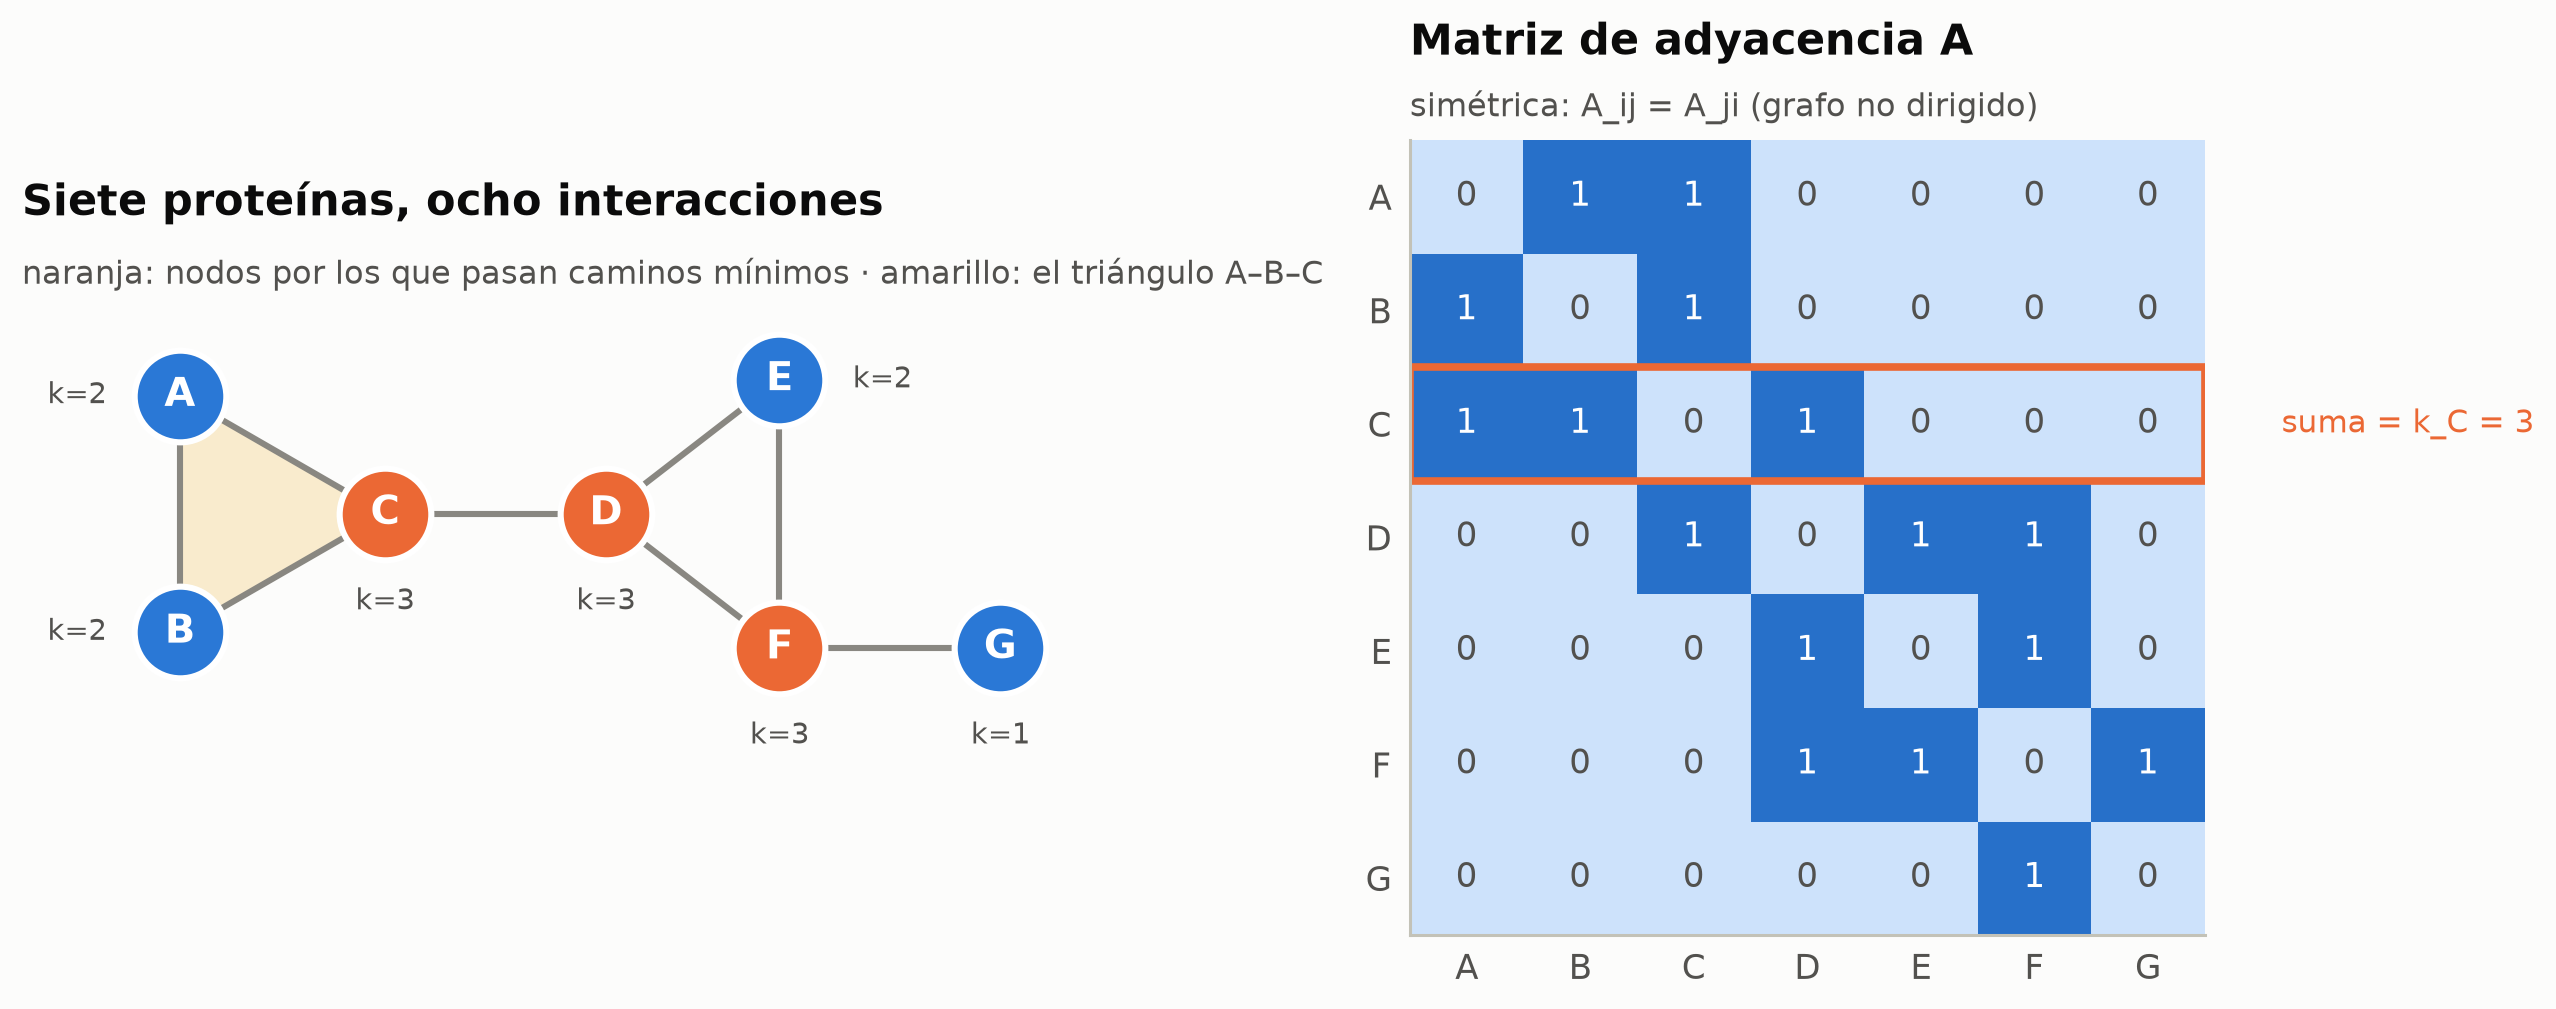

In [3]:
POS_TOY = {"A": (0, 1.5), "B": (0, 0), "C": (1.3, 0.75), "D": (2.7, 0.75),
           "E": (3.8, 1.6), "F": (3.8, -0.1), "G": (5.2, -0.1)}      # coordenadas del libro

fig, (ax, axm) = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax.fill([POS_TOY[u][0] for u in "ABC"], [POS_TOY[u][1] for u in "ABC"], color=ec.YELLOW, alpha=0.18, zorder=0)
for u, v in toy.edges():
    ax.plot(*zip(POS_TOY[u], POS_TOY[v]), color=ec.MUTED, lw=2, zorder=1)
bridge = {"C", "D", "F"}
for u in order:
    ax.scatter(*POS_TOY[u], s=900, color=ec.ORANGE if u in bridge else ec.BLUE, edgecolor="white", lw=2, zorder=2)
    ax.text(*POS_TOY[u], u, color="white", ha="center", va="center", fontweight="bold", fontsize=13, zorder=3)
    off = {"A": (-24, 0, "right", "center"), "B": (-24, 0, "right", "center"), "E": (24, 0, "left", "center"),
           "G": (0, -24, "center", "top")}.get(u, (0, -24, "center", "top"))
    ax.annotate(f"k={toy.degree(u)}", POS_TOY[u], xytext=off[:2], textcoords="offset points",
                ha=off[2], va=off[3], fontsize=9.5, color=ec.INK_2)
ax.set_xlim(-1.0, 5.8); ax.set_ylim(-0.9, 2.1); ax.set_aspect("equal"); ax.axis("off")
ec.title(ax, "Siete proteínas, ocho interacciones", "naranja: nodos por los que pasan caminos mínimos · amarillo: el triángulo A–B–C")

im = axm.imshow(A, cmap=ec.CMAP_SEQ, vmin=0, vmax=1.6)
axm.add_patch(plt.Rectangle((-0.5, 1.5), 7, 1, fill=False, ec=ec.ORANGE, lw=2.5))
for i in range(7):
    for j in range(7):
        axm.text(j, i, A[i, j], ha="center", va="center", fontsize=11,
                 color="white" if A[i, j] else ec.INK_2)
axm.set_xticks(range(7), order); axm.set_yticks(range(7), order); axm.grid(False)
axm.text(7.0, 2, "  suma = k_C = 3", va="center", fontsize=10, color=ec.ORANGE)
ec.title(axm, "Matriz de adyacencia A", "simétrica: A_ij = A_ji (grafo no dirigido)")
plt.show()

> 🔎 **Qué observamos.** La matriz es simétrica y su diagonal es cero (una proteína no «interactúa consigo misma» en
> este grafo). La fila de C (recuadro) tiene tres unos: $k_C=3$. La suma de todos los unos de la matriz es 16, el
> doble de las 8 aristas, porque cada arista aparece dos veces ($A_{ij}$ y $A_{ji}$).

### 2.3 Las potencias de $A$ cuentan caminos

La matriz de adyacencia no es sólo una tabla: sus **potencias cuentan recorridos**. El elemento
$(A^2)_{ij}=\sum_{l}A_{il}A_{lj}$ suma 1 por cada nodo $l$ que es vecino a la vez de $i$ y de $j$: cuenta los
recorridos de longitud 2 entre ellos. Por inducción,

$$
(A^{\ell})_{ij} = \text{número de recorridos de longitud } \ell \text{ entre } i \text{ y } j .
$$

En particular $(A^3)_{ii}$ cuenta los recorridos que salen de $i$ y vuelven a él en tres pasos. Cada **triángulo** que
contiene a $i$ se recorre en dos sentidos (A→B→C→A y A→C→B→A), así que el número de triángulos de $i$ es
$t_i=(A^3)_{ii}/2$.

| Símbolo | Significado |
|---|---|
| $\ell$ | longitud del recorrido (número de pasos) |
| $(A^\ell)_{ij}$ | número de recorridos de $\ell$ pasos de $i$ a $j$ (pueden repetir nodos) |
| $t_i$ | número de triángulos que contienen al nodo $i$, igual a $(A^3)_{ii}/2$ |

**A mano.** $(A^2)_{\mathrm{A,D}}$: A y D tienen un único vecino común, C, luego vale 1 (el recorrido A–C–D).
$(A^3)_{\mathrm{A,E}}=1$: el único recorrido de tres pasos es A–C–D–E. Y $(A^2)_{ii}=k_i$: ir a un vecino y volver.

(A^2)[A,D] = 1   (A^3)[A,E] = 1
diag(A^2) = [2 2 3 3 2 3 1]  ← coincide con los grados
triángulos t_i = diag(A^3)/2 = {'A': 1, 'B': 1, 'C': 1, 'D': 1, 'E': 1, 'F': 1, 'G': 0}


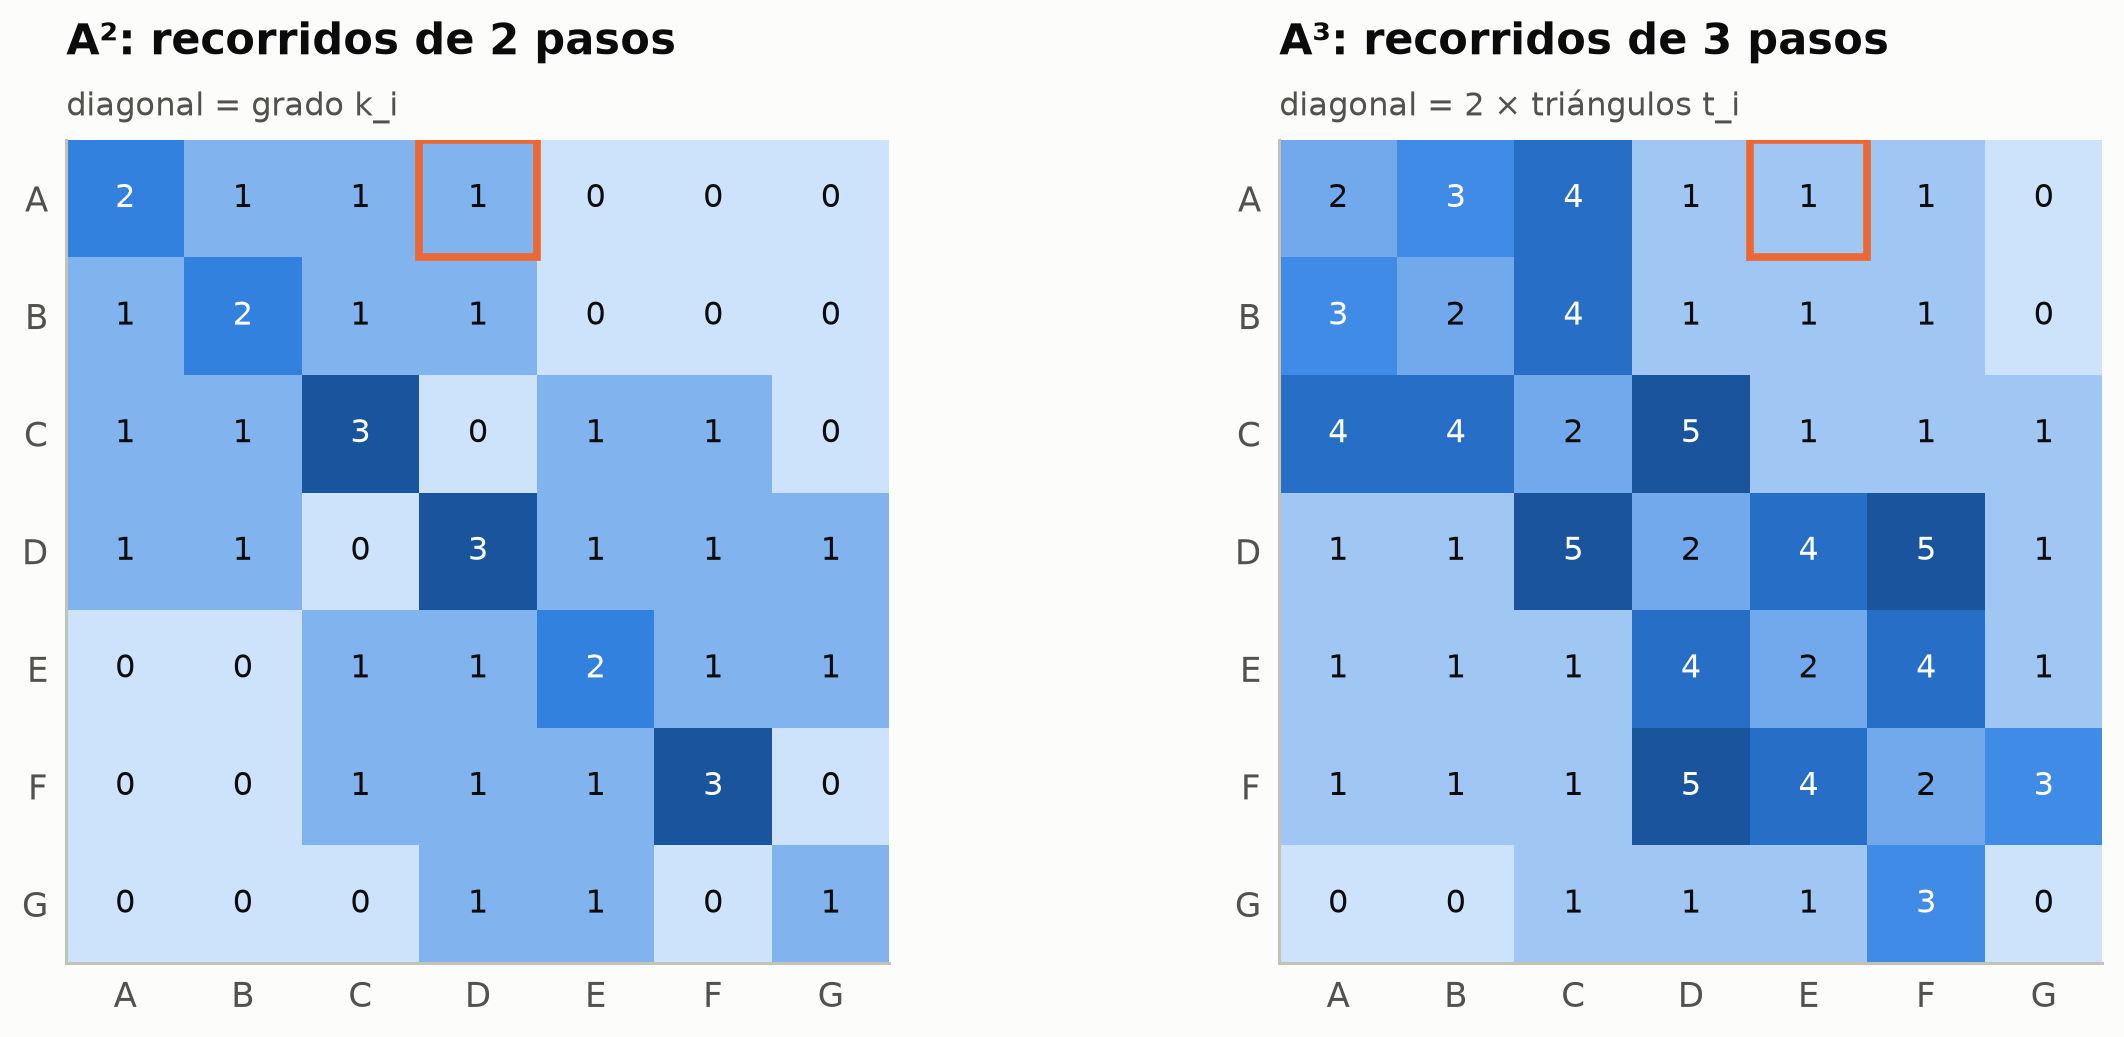

In [4]:
A2, A3 = A @ A, A @ A @ A
iA, iD, iE = order.index("A"), order.index("D"), order.index("E")
print(f"(A^2)[A,D] = {A2[iA, iD]}   (A^3)[A,E] = {A3[iA, iE]}")
print("diag(A^2) =", np.diag(A2), " ← coincide con los grados")
t_tri = np.diag(A3) // 2
print("triángulos t_i = diag(A^3)/2 =", dict(zip(order, t_tri.tolist())))

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, M, name, sub in ((axs[0], A2, "A²: recorridos de 2 pasos", "diagonal = grado k_i"),
                         (axs[1], A3, "A³: recorridos de 3 pasos", "diagonal = 2 × triángulos t_i")):
    ax.imshow(M, cmap=ec.CMAP_SEQ, vmin=0, vmax=M.max() * 1.25)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=10.5,
                    color="white" if M[i, j] > M.max() * 0.55 else ec.INK)
    ax.set_xticks(range(7), order); ax.set_yticks(range(7), order); ax.grid(False)
    ec.title(ax, name, sub)
axs[0].add_patch(plt.Rectangle((iD - 0.5, iA - 0.5), 1, 1, fill=False, ec=ec.ORANGE, lw=2.5))
axs[1].add_patch(plt.Rectangle((iE - 0.5, iA - 0.5), 1, 1, fill=False, ec=ec.ORANGE, lw=2.5))
plt.show()

> 🔎 **Qué observamos.** Los recuadros naranjas son los dos números del ejemplo del libro: $(A^2)_{\mathrm{A,D}}=1$ y
> $(A^3)_{\mathrm{A,E}}=1$. La diagonal de $A^3$ vale 2 para A…F (cada uno está en exactamente un triángulo: A–B–C o
> D–E–F) y 0 para G, que no está en ninguno. Contar triángulos con productos de matrices es la base de los algoritmos
> rápidos de agrupamiento en redes enormes.

### 2.4 Coeficiente de agrupamiento

¿Sus amigos se conocen entre sí? En un grupo muy unido, sí. El **coeficiente de agrupamiento local** de un nodo con
$k_i\ge 2$ es la fracción de pares de sus vecinos que también son vecinos entre sí:

$$
C_i=\frac{t_i}{\binom{k_i}{2}}=\frac{2\,t_i}{k_i(k_i-1)},\qquad C=\frac{1}{n}\sum_i C_i .
$$

| Símbolo | Significado |
|---|---|
| $t_i$ | número de triángulos que contienen al nodo $i$, igual a $(A^3)_{ii}/2$ |
| $\binom{k_i}{2}$ | número de pares posibles entre los $k_i$ vecinos de $i$ |
| $C$ | coeficiente de agrupamiento medio de la red (con $C_i=0$ si $k_i<2$) |

**A mano.** C tiene vecinos A, B y D; de los $\binom{3}{2}=3$ pares posibles sólo A–B está unido: $C_{\mathrm{C}}=1/3$.
A tiene vecinos B y C, que están unidos: $C_{\mathrm{A}}=1$. G tiene un solo vecino: $C_{\mathrm{G}}=0$ por convenio.
Promediando, $C=(1+1+\tfrac13+\tfrac13+1+\tfrac13+0)/7=4/7\approx 0{,}571$.

### 2.5 Distancias e intermediación

La **distancia** $d_{ij}$ es la longitud del camino más corto entre $i$ y $j$; se calcula por **búsqueda en anchura**
(BFS: primero todos los vecinos, luego los vecinos de los vecinos…) en tiempo $O(n+m)$ desde cada origen. Su promedio
sobre los pares conectados es $L$, y su máximo, el **diámetro**. Finalmente, la **intermediación** (*betweenness*) de
un nodo mide cuántos caminos mínimos pasan por él:

$$
b_v=\sum_{s\neq v\neq t}\frac{\sigma_{st}(v)}{\sigma_{st}} .
$$

| Símbolo | Significado |
|---|---|
| $d_{ij}$ | distancia (número de aristas del camino más corto) entre $i$ y $j$ |
| $L$ | distancia media entre todos los pares conectados |
| $\sigma_{st}$ | número de caminos mínimos entre $s$ y $t$ |
| $\sigma_{st}(v)$ | cuántos de ellos pasan por $v$ |
| $b_v$ | intermediación: nodos «puente» por los que fluye mucha comunicación |

**A mano.** En el grafo de juguete todo camino mínimo es único ($\sigma_{st}=1$), así que $b_v$ es simplemente el número
de pares cuyo camino cruza $v$. Todo par de $\{$A, B, C$\}\times\{$E, F, G$\}$ cruza D: $3\times3=9$ pares, $b_{\mathrm{D}}=9$.
C está en los caminos de $\{$A, B$\}\times\{$D, E, F, G$\}$: $2\times4=8$. F está en los de G con $\{$A, B, C, D, E$\}$: 5.

In [5]:
Ci = nx.clustering(toy)
bc_t = nx.betweenness_centrality(toy, normalized=False)
L_t, diam_t = nx.average_shortest_path_length(toy), nx.diameter(toy)
tab = pd.DataFrame({"k_i": k_t, "t_i": t_tri, "C_i": [round(Ci[u], 3) for u in order],
                    "b_v": [bc_t[u] for u in order]}, index=order)
print(tab.T)
print(f"\nC medio = {fmt(nx.average_clustering(toy))} (= 4/7)   transitividad global = {fmt(nx.transitivity(toy))}")
print(f"L = {fmt(L_t)} (21 pares)   diámetro = {diam_t}  (de A o B a G)")
print("distancias desde A (BFS):", nx.single_source_shortest_path_length(toy, "A"))

       A    B      C      D    E      F    G
k_i  2.0  2.0  3.000  3.000  2.0  3.000  1.0
t_i  1.0  1.0  1.000  1.000  1.0  1.000  0.0
C_i  1.0  1.0  0.333  0.333  1.0  0.333  0.0
b_v  0.0  0.0  8.000  9.000  0.0  5.000  0.0

C medio = 0,571 (= 4/7)   transitividad global = 0,500
L = 2,048 (21 pares)   diámetro = 4  (de A o B a G)
distancias desde A (BFS): {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 3, 'F': 3, 'G': 4}


> 🔎 **Qué observamos.** Todas las cifras del ejemplo «Medir a mano un grafo pequeño» del libro: grados
> $(2,2,3,3,2,3,1)$, $C=0{,}571$, $L\approx2{,}05$, diámetro 4 y $b_{\mathrm{C}}=8$, $b_{\mathrm{D}}=9$, $b_{\mathrm{F}}=5$.
> Note además que la **transitividad** ($3\times$ triángulos / tripletes conectados $=0{,}5$) no coincide con el
> promedio de los $C_i$ ($0{,}571$): el promedio da el mismo peso a un nodo de grado 2 que a uno de grado 300, la
> transitividad pesa más a los nodos de grado alto. En redes reales la diferencia puede ser grande: compruebe cuál usa
> un artículo antes de comparar.

La figura interactiva resume las tres medidas. Pase el cursor por cada proteína.

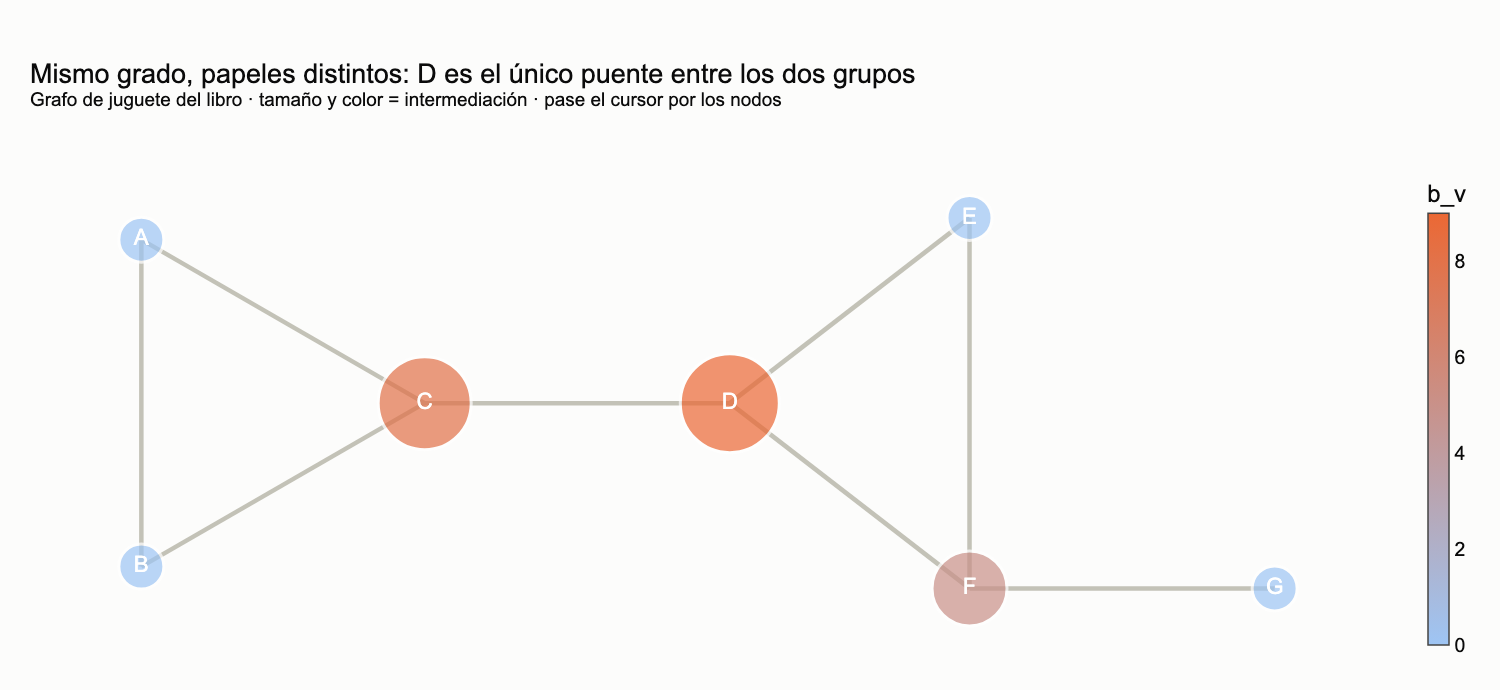

In [6]:
fig = go.Figure()
ex, ey = [], []
for u, v in toy.edges():
    ex += [POS_TOY[u][0], POS_TOY[v][0], None]; ey += [POS_TOY[u][1], POS_TOY[v][1], None]
fig.add_trace(go.Scatter(x=ex, y=ey, mode="lines", line=dict(color=ec.BASELINE, width=3), hoverinfo="skip",
                         showlegend=False))
bmax = max(bc_t.values())
fig.add_trace(go.Scatter(
    x=[POS_TOY[u][0] for u in order], y=[POS_TOY[u][1] for u in order], mode="markers+text", text=order,
    textfont=dict(color="white", size=15), showlegend=False,
    marker=dict(size=[30 + 4 * bc_t[u] for u in order], color=[bc_t[u] for u in order], cmin=0, cmax=bmax,
                colorscale=[[0, "#9ec5f4"], [1, ec.ORANGE]], line=dict(color="white", width=2),
                colorbar=dict(title="b_v", thickness=14)),
    customdata=np.column_stack([k_t, t_tri, [Ci[u] for u in order], [bc_t[u] for u in order],
                                [", ".join(sorted(toy[u])) for u in order]]),
    hovertemplate=("<b>proteína %{text}</b><br>vecinos: %{customdata[4]}"
                   "<br>grado k = %{customdata[0]} (popularidad local)"
                   "<br>triángulos t = %{customdata[1]} → C_i = %{customdata[2]:.3f}"
                   "<br>intermediación b = %{customdata[3]:.0f} pares la cruzan<extra></extra>")))
fig.update_layout(
    title="Mismo grado, papeles distintos: D es el único puente entre los dos grupos<br>"
          "<sup>Grafo de juguete del libro · tamaño y color = intermediación · pase el cursor por los nodos</sup>",
    xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor="x"), height=460,
    margin=dict(t=110, l=20, r=20, b=20))
fig.show()

> ✅ **Compruebe su comprensión.** (1) Si añadimos la arista B–D, ¿qué pasa con $C_{\mathrm{C}}$ y con $b_{\mathrm{D}}$?
> (2) ¿Puede un nodo tener grado 2 y la intermediación más alta de la red? *Respuestas:* (1) C gana el triángulo
> B–C–D: $C_{\mathrm{C}}=2/3$; $b_{\mathrm{D}}$ **no cambia** (9: todo camino entre los dos grupos sigue cruzando D),
> pero $b_{\mathrm{C}}$ cae de 8 a 2, porque B ya llega a D sin pasar por C. (2) Sí: basta con que sea
> el único enlace entre dos grupos grandes (una «estación de transbordo» con sólo dos andenes).

**Idea clave.** Grado: cuántos vecinos. Agrupamiento: cuán unidos están esos vecinos. Intermediación: cuánto tráfico
pasa por el nodo. Tres números distintos para tres preguntas distintas. Volviendo a la pregunta del inicio: para
cortar una vía sin tocar nada más, la intermediación suele ser mejor guía que el grado.

## 3. Cómo se mide un interactoma

Los grafos de interacción no se observan directamente: se **construyen** a partir de experimentos, y cada experimento
deja su huella en la red resultante. Dos familias de métodos dominaron la primera década de la interactómica.

**Doble híbrido en levadura (Y2H).** Un factor de transcripción como Gal4 tiene dos piezas separables: un dominio que
se une al ADN (DBD) y otro que activa la transcripción (AD). Por separado no hacen nada; si se acercan, reconstituyen
un activador funcional. El método fusiona una proteína «cebo» al DBD y otra «presa» al AD: si cebo y presa
interactúan, el activador se reconstituye en el promotor y se expresa un gen reportero que permite a la levadura
crecer en un medio selectivo. La lectura es un **par binario**. Uetz *et al.* (2000) lo aplicaron a escala de genoma y
detectaron 957 interacciones putativas entre 1 004 proteínas; casi a la vez, Ito *et al.* (2001) identificaron 4 549
interacciones entre 3 278 proteínas y notaron algo inquietante: sus datos **apenas se solapaban** con los de Uetz.

**Purificación por afinidad y espectrometría de masas (AP-MS).** En lugar de pares, AP-MS mide **complejos**: se marca
una proteína cebo con una etiqueta, se purifica en condiciones suaves junto con todo lo que arrastra, y los
acompañantes se identifican por espectrometría de masas. Gavin *et al.* (2002) purificaron 589 ensamblajes proteicos
y definieron 232 complejos. El resultado es una lista de **conjuntos**, y convertirlos en aristas exige una decisión:

* modelo **estrella** (*spoke*): se une el cebo a cada presa → con un cebo y $r$ presas, $r$ aristas;
* modelo **matriz** (*matrix*): se unen todos con todos → $\binom{r+1}{2}$ aristas.

Con un cebo y cinco presas: 5 aristas frente a $\binom{6}{2}=15$, la mayoría no verificadas como contactos directos.

 spoke: 5 aristas
matrix: 15 aristas
complejo de 33 proteínas → estrella: 32 aristas, matriz: 528 aristas


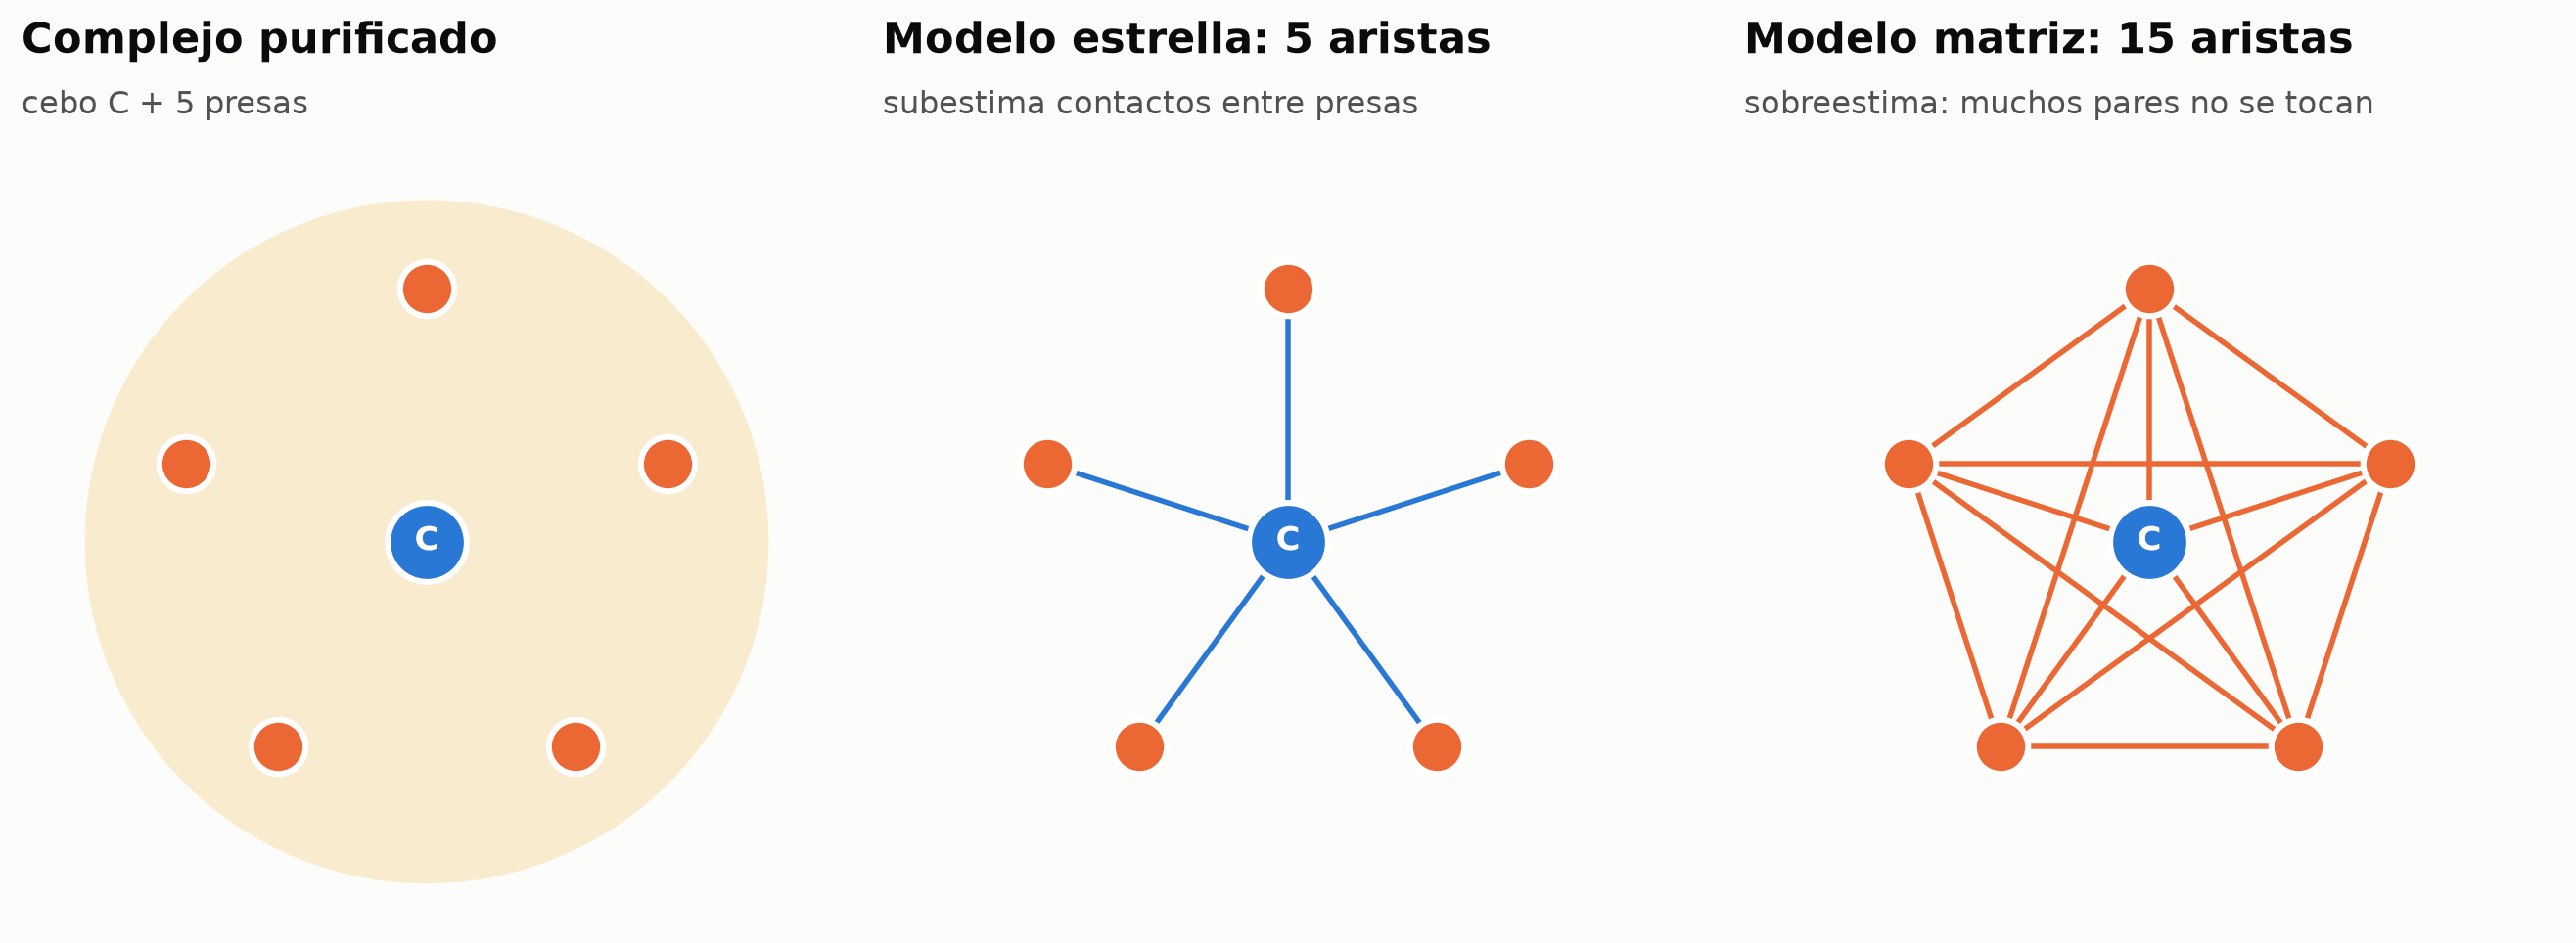

In [7]:
def complex_to_edges(bait, preys, model):
    """Convierte un complejo purificado por AP-MS en aristas según el modelo elegido."""
    if model == "spoke":
        return [(bait, p) for p in preys]
    members = [bait] + list(preys)
    return list(itertools.combinations(members, 2))

bait, preys = "C", ["p1", "p2", "p3", "p4", "p5"]
for model in ("spoke", "matrix"):
    print(f"{model:>6}: {len(complex_to_edges(bait, preys, model))} aristas")
# ¿Cuántas aristas aporta un complejo grande, como el ribosoma pequeño (~33 proteínas)?
r = 32
print(f"complejo de {r + 1} proteínas → estrella: {r} aristas, matriz: {math.comb(r + 1, 2)} aristas")

fig, axs = plt.subplots(1, 3, figsize=(12, 4.2))
ang = np.deg2rad([90, 18, -54, -126, 162])
P = {"C": (0, 0), **{p: (np.cos(a), np.sin(a)) for p, a in zip(preys, ang)}}
for ax, (model, ttl, sub) in zip(axs, [("none", "Complejo purificado", "cebo C + 5 presas"),
                                         ("spoke", "Modelo estrella: 5 aristas", "subestima contactos entre presas"),
                                         ("matrix", "Modelo matriz: 15 aristas", "sobreestima: muchos pares no se tocan")]):
    if model != "none":
        for u, v in complex_to_edges(bait, preys, model):
            ax.plot(*zip(P[u], P[v]), color=ec.BLUE if model == "spoke" else ec.ORANGE, lw=1.8, zorder=1)
    else:
        ax.add_patch(plt.Circle((0, 0), 1.35, color=ec.YELLOW, alpha=0.18))
    ax.scatter(0, 0, s=700, color=ec.BLUE, edgecolor="white", lw=2, zorder=2)
    ax.text(0, 0, "C", color="white", ha="center", va="center", fontweight="bold", zorder=3)
    ax.scatter([P[p][0] for p in preys], [P[p][1] for p in preys], s=330, color=ec.ORANGE, edgecolor="white", lw=2, zorder=2)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.5, 1.6); ax.set_aspect("equal"); ax.axis("off")
    ec.title(ax, ttl, sub)
plt.show()

> 🔎 **Qué observamos.** Un complejo de 33 proteínas aporta 32 aristas en el modelo estrella y **528** en el modelo
> matriz. Esa elección explica por qué los complejos grandes aparecen en las redes como densas «bolas» de aristas; en
> la sección 6 veremos que el ribosoma domina así la cola de la distribución de grado de la levadura.

## 4. Falsos positivos, falsos negativos e integración de evidencias

El escaso solapamiento entre los primeros cribados obligó a preguntarse cuánto era señal y cuánto ruido. von Mering
*et al.* (2002) compararon los grandes conjuntos de levadura entre sí y con un conjunto de referencia, y la
conclusión, confirmada desde entonces, es que **cada método tiene su propio perfil de errores**:

| Método | Detecta bien | Falsos positivos típicos | Falsos negativos típicos |
|---|---|---|---|
| Y2H | contactos binarios, también transitorios | proteínas «pegajosas», autoactivadoras, pares que nunca coinciden en la célula | proteínas de membrana |
| AP-MS | complejos estables | asociación indirecta tomada como contacto directo | interacciones débiles; sesgo hacia proteínas abundantes |

Las interacciones respaldadas por varios métodos independientes son mucho más fiables. Eso sugiere cómo integrar: si
cada fuente de evidencia $c$ asigna a un par una probabilidad $s_c$ de que la asociación sea real, y las fuentes
fallan de forma **independiente**, la probabilidad de que **todas** se equivoquen es el producto de sus errores:

$$
S = 1-\prod_{c}\left(1-s_c\right).
$$

| Símbolo | Significado |
|---|---|
| $s_c$ | confianza de la fuente o «canal» $c$ (experimentos, bases curadas, coexpresión, texto, contexto genómico…) |
| $S$ | confianza combinada, bajo el supuesto de independencia entre canales |

**A mano (ejemplo del libro).** Con tres canales de confianza moderada, $s=(0{,}6;\ 0{,}5;\ 0{,}7)$:
$S=1-0{,}4\times0{,}5\times0{,}3=1-0{,}06=0{,}94$. Tres evidencias mediocres hacen una fuerte, **si son independientes**.

Esta es la lógica de fondo de **STRING** (Szklarczyk *et al.*, 2023), que integra experimentos, bases curadas,
coexpresión, contexto genómico conservado (vecindad, fusión, co-ocurrencia filogenética) y minería de textos, y
transfiere evidencias entre organismos por ortología. En el otro extremo, **BioGRID** (Oughtred *et al.*, 2021) no
predice nada: cura a mano interacciones de la literatura (≈1,93 millones en 2021).

Pongamos la fórmula a prueba con datos **reales**: los 40 socios de FUS3 con mayor puntuación en la API de STRING.

In [8]:
s = np.array([0.6, 0.5, 0.7])
print(f"Ejemplo del libro: S = 1 - prod(1 - s) = {fmt(1 - np.prod(1 - s), 2)}")

# Consulta real a la API de STRING (en caché en data/api_cache/): socios de FUS3 en levadura (taxón 4932)
URL_STRING = ("https://string-db.org/api/json/interaction_partners?identifiers=FUS3&species=4932"
              "&limit=40&caller_identity=bioinformatica_practica")
partners = json.load(open(course_file("api_cache/161_string_fus3_partners.json", URL_STRING)))
CHANNELS = {"escore": "experimentos", "dscore": "bases curadas", "tscore": "minería de textos",
            "ascore": "coexpresión", "pscore": "co-ocurrencia filogenética", "nscore": "vecindad génica",
            "fscore": "fusión génica"}
sp = pd.DataFrame(partners).set_index("preferredName_B")[["score"] + list(CHANNELS)]
print(sp.head(8).round(3))

Ejemplo del libro: S = 1 - prod(1 - s) = 0,94
                 score  escore  dscore  tscore  ascore  pscore  nscore  fscore
preferredName_B                                                               
TIM12            0.999   0.999     0.0   0.000   0.000   0.000       0       0
STE7             0.999   0.999     0.9   0.920   0.114   0.196       0       0
STE5             0.999   0.999     0.0   0.945   0.163   0.000       0       0
DIG2             0.999   0.999     0.9   0.902   0.000   0.000       0       0
KSS1             0.999   0.999     0.9   0.236   0.096   0.066       0       0
GPA1             0.999   0.999     0.0   0.925   0.517   0.000       0       0
STE12            0.999   0.990     0.9   0.944   0.303   0.000       0       0
FAR1             0.999   0.999     0.9   0.909   0.389   0.000       0       0


Si aplicamos $S=1-\prod(1-s_c)$ tal cual, la combinación **sobreestima** ligeramente la puntuación de STRING. La razón
es sutil y muy instructiva: cada $s_c$ de STRING ya incluye la probabilidad **a priori** $p_0\approx0{,}041$ de que dos
proteínas cualesquiera estén asociadas. Si se multiplican los canales sin más, ese «piso» se cuenta varias veces.
STRING lo resuelve quitando el a priori de cada canal, combinando y volviéndolo a añadir una sola vez:

$$
s'_c=\frac{s_c-p_0}{1-p_0},\qquad S'=1-\prod_c(1-s'_c),\qquad S=S'+p_0\,(1-S').
$$

| Símbolo | Significado |
|---|---|
| $p_0$ | probabilidad a priori de que un par al azar esté asociado (0,041 en STRING) |
| $s'_c$ | confianza del canal $c$ sin el a priori (se trunca en 0) |

                 STRING  ingenua  con a priori
preferredName_B                               
PTP3              0.994    0.995         0.994
FUS1              0.949    0.953         0.949
STE50             0.909    0.913         0.909
HOG1              0.891    0.905         0.892
PBS2              0.794    0.818         0.794
RGA2              0.745    0.756         0.745

error absoluto máximo — ingenua: 0.024 · con a priori: 0.001


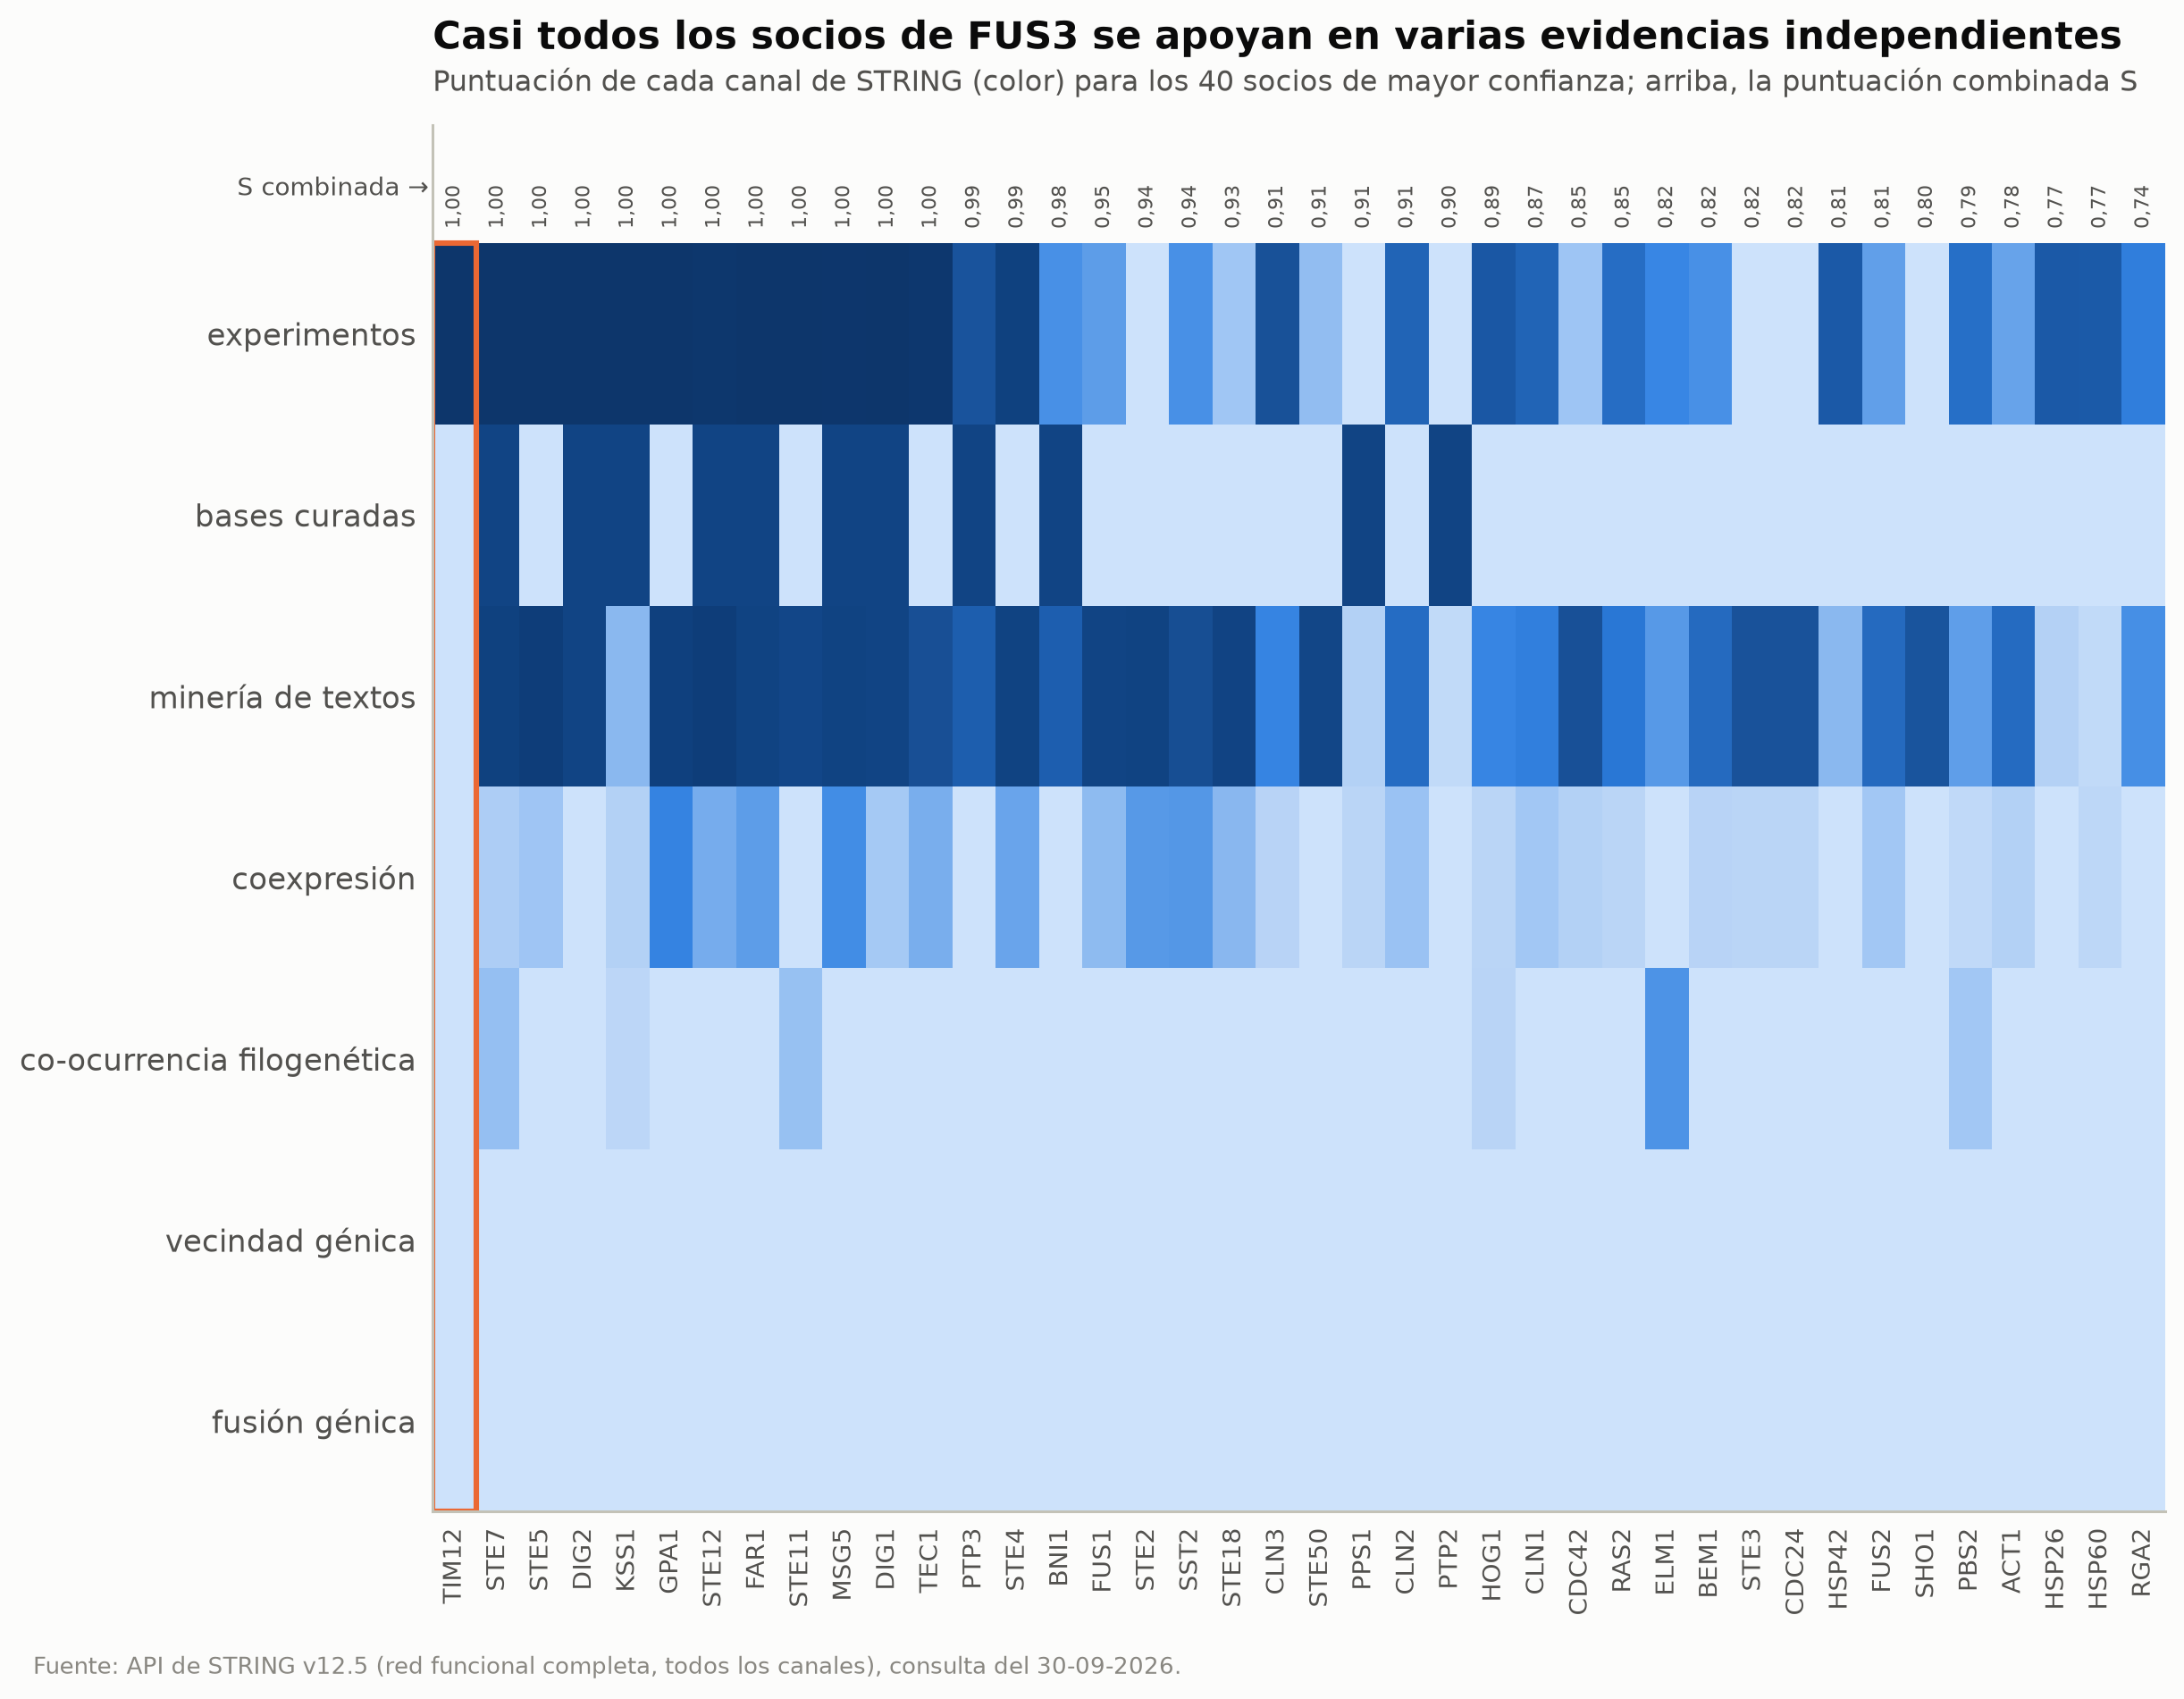

In [9]:
p0 = 0.041
ch = sp[list(CHANNELS)].to_numpy()
S_naive = 1 - np.prod(1 - ch, axis=1)
chp = np.clip((ch - p0) / (1 - p0), 0, None)
S_prior = 1 - np.prod(1 - chp, axis=1); S_prior = S_prior + p0 * (1 - S_prior)
cmp_ = pd.DataFrame({"STRING": sp.score, "ingenua": S_naive.round(3), "con a priori": S_prior.round(3)}, index=sp.index)
print(cmp_.iloc[[12, 15, 20, 24, 35, 39]])
print(f"\nerror absoluto máximo — ingenua: {np.abs(S_naive - sp.score).max():.3f} · "
      f"con a priori: {np.abs(S_prior - sp.score).max():.3f}")

fig, ax = plt.subplots(figsize=(11, 8.2))
H = sp[list(CHANNELS)].T
ax.imshow(H.to_numpy(), cmap=ec.CMAP_SEQ, vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(CHANNELS)), list(CHANNELS.values()))
ax.set_xticks(range(len(sp)), sp.index, rotation=90, fontsize=9)
ax.grid(False)
for j, sc_ in enumerate(sp.score):
    ax.text(j, -0.58, fmt(sc_, 2), ha="center", va="bottom", fontsize=7.2, color=ec.INK_2, rotation=90)
ax.set_ylim(len(CHANNELS) - 0.5, -1.15)
ax.text(-0.6, -0.8, "S combinada →", ha="right", va="center", fontsize=9, color=ec.INK_2)
ec.title(ax, "Casi todos los socios de FUS3 se apoyan en varias evidencias independientes",
         "Puntuación de cada canal de STRING (color) para los 40 socios de mayor confianza; arriba, la puntuación combinada S")
i12 = list(sp.index).index("TIM12")
ax.add_patch(plt.Rectangle((i12 - 0.5, -0.5), 1, len(CHANNELS), fill=False, ec=ec.ORANGE, lw=2))
ec.source(fig, "Fuente: API de STRING v12.5 (red funcional completa, todos los canales), consulta del 30-09-2026.")
plt.show()

> 🔎 **Qué observamos.** Con la corrección del a priori reproducimos la puntuación de STRING con un error máximo de
> 0,001; sin ella, el error llega a 0,02–0,03. Casi todos los socios de FUS3 se apoyan en varios canales a la vez:
> STE7, DIG2 y FAR1 en experimentos **y** textos **y** bases curadas; STE5 y GPA1 en experimentos y textos (su canal
> de bases curadas vale 0). La excepción es **TIM12** (recuadro): una proteína de la importación mitocondrial con
> $S=0{,}999$ que descansa **sólo** en el canal experimental ($s=0{,}999$; todos los demás canales valen 0). La tabla no
> dice de qué experimento procede; la recordaremos en la sección 8.

> ⚠️ **Una asociación no es un contacto.** Una arista de STRING con puntuación alta puede significar que dos proteínas
> se tocan, que forman parte del mismo complejo sin tocarse, o que sus genes se coexpresan o se citan juntos. Para
> preguntas de estructura física filtre por canal (STRING ofrece una red «física», la que usaremos desde ahora) o use
> datos curados como BioGRID. Y la **ausencia** de arista casi nunca significa ausencia de interacción: los
> interactomas siguen incompletos y sesgados hacia las proteínas más estudiadas.

> ✅ **Compruebe su comprensión.** ¿Por qué el supuesto de independencia es dudoso entre los canales «bases curadas» y
> «minería de textos»? *Respuesta:* porque las bases curadas se construyen leyendo los mismos artículos que la minería
> de textos analiza: si un artículo se equivoca, ambos canales se equivocan juntos, y $S$ sobreestima la confianza.

## 5. Tres modelos de red y lo que predicen

### 5.1 Los datos: la red física de levadura de STRING

Para saber si una propiedad de una red real es notable necesitamos compararla con lo que produciría el **azar**.
Usaremos como red real la del libro: la red **física** de *S. cerevisiae* de STRING v12.0 (archivo
`protein.physical.links.v12.0`, taxón 4932), con puntuación combinada $\ge 700$ («confianza alta»), cada par una sola
vez y con los nombres preferidos de las proteínas. La cargamos ahora porque los modelos nulos se construyen con **el
mismo número de nodos y aristas**.

Para reproducir las cifras del libro usamos su generador de números aleatorios, `np.random.default_rng(16)`, en el
mismo orden: primero 400 orígenes para medir distancias en la levadura, después 200 en la red de Erdős-Rényi y por
último las del modelo de Watts-Strogatz.

In [10]:
URL_STRING_DL = None   # el archivo filtrado se generó desde https://stringdb-downloads.org (ver figuras/cap16/generar.py)
edges = pd.read_csv(course_file("161_levadura_string700.tsv.gz"), sep="\t", comment="#")
print(edges.head(3)); print(f"{len(edges)} filas; puntuación mínima = {edges.score.min()}")
G = nx.from_pandas_edgelist(edges, "prot1", "prot2", "score")
n, m = G.number_of_nodes(), G.number_of_edges()
deg = np.array([d for _, d in G.degree()])
gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()     # componente gigante
print(f"n = {n}, m = {m}, <k> = {deg.mean():.2f}, kmax = {deg.max()}, "
      f"componentes = {nx.number_connected_components(G)}, gigante = {len(gc)}")

rng = np.random.default_rng(16)                     # el MISMO generador que el libro
t0 = time.time()
C_y = nx.average_clustering(G)
src = rng.choice(list(gc), 400, replace=False)      # 400 orígenes de BFS (muestreo de distancias)
Ls = [v for s0 in src for v in nx.single_source_shortest_path_length(gc, s0).values() if v > 0]
L_y = np.mean(Ls)
print(f"C = {C_y:.3f}  transitividad = {nx.transitivity(G):.3f}  L ≈ {L_y:.2f}  diámetro ≥ {max(Ls)}"
      f"   ({time.time() - t0:.1f} s)")

  prot1 prot2  score
0  COX1  RCF1    734
1  COX1  COX4    999
2  COX1  COX3    999
43030 filas; puntuación mínima = 700
n = 3384, m = 43030, <k> = 25.43, kmax = 282, componentes = 216, gigante = 2780


C = 0.581  transitividad = 0.661  L ≈ 5.16  diámetro ≥ 15   (1.7 s)


¿Por qué **muestrear** 400 orígenes en lugar de calcular las $\binom{2780}{2}\approx3{,}9$ millones de distancias? Cada
BFS cuesta $O(n+m)$; 400 de ellas dan un promedio sobre más de un millón de pares, con un error estándar minúsculo, en
un segundo. Es la misma idea que un sondeo electoral.

### 5.2 Erdős-Rényi (ER): el azar puro

Se toman $n$ nodos y se coloca cada una de las $\binom{n}{2}$ aristas posibles con probabilidad $p$, de forma
independiente (como lanzar una moneda trucada por cada par). El grado de un nodo es la suma de $n-1$ ensayos de
Bernoulli: sigue una **binomial**, que para $n$ grande y $\langle k\rangle=p(n-1)$ fijo converge a una **Poisson**:

$$
P(k)=\binom{n-1}{k}p^k(1-p)^{n-1-k}\;\xrightarrow{\;n\to\infty\;}\;e^{-\langle k\rangle}\frac{\langle k\rangle^k}{k!},
\qquad C=p,\qquad L\approx\frac{\ln n}{\ln\langle k\rangle}.
$$

| Símbolo | Significado |
|---|---|
| $p$ | probabilidad de cada arista |
| $P(k)$ | distribución de grado: concentrada alrededor de $\langle k\rangle$, con colas que decaen más rápido que exponencialmente |

* **$C=p$**: dos vecinos de un nodo están unidos, como cualquier otro par, con probabilidad $p$.
* **$L\approx\ln n/\ln\langle k\rangle$**: desde un nodo se alcanzan unos $\langle k\rangle$ nodos a distancia 1,
  $\langle k\rangle^2$ a distancia 2 y $\langle k\rangle^\ell$ a distancia $\ell$; la red queda cubierta cuando
  $\langle k\rangle^L\approx n$. La distancia crece sólo con el **logaritmo** del tamaño.

**A mano.** Con los $n=3384$ y $m=43030$ de la levadura: $p=2m/[n(n-1)]=0{,}0075$, $\langle k\rangle=25{,}4$ y
$L\approx\ln3384/\ln25{,}4=8{,}13/3{,}24=2{,}51$.

> 🤔 **Antes de ejecutar, prediga.** ¿Tendrá la red ER equivalente algún nodo con más de 60 vecinos?

p = 0.00752  C(ER) = 0.0076 (teoría C = p = 0.0075)
L(ER) = 2.83  (teoría ln n / ln<k> = 2.51)   kmax(ER) = 45


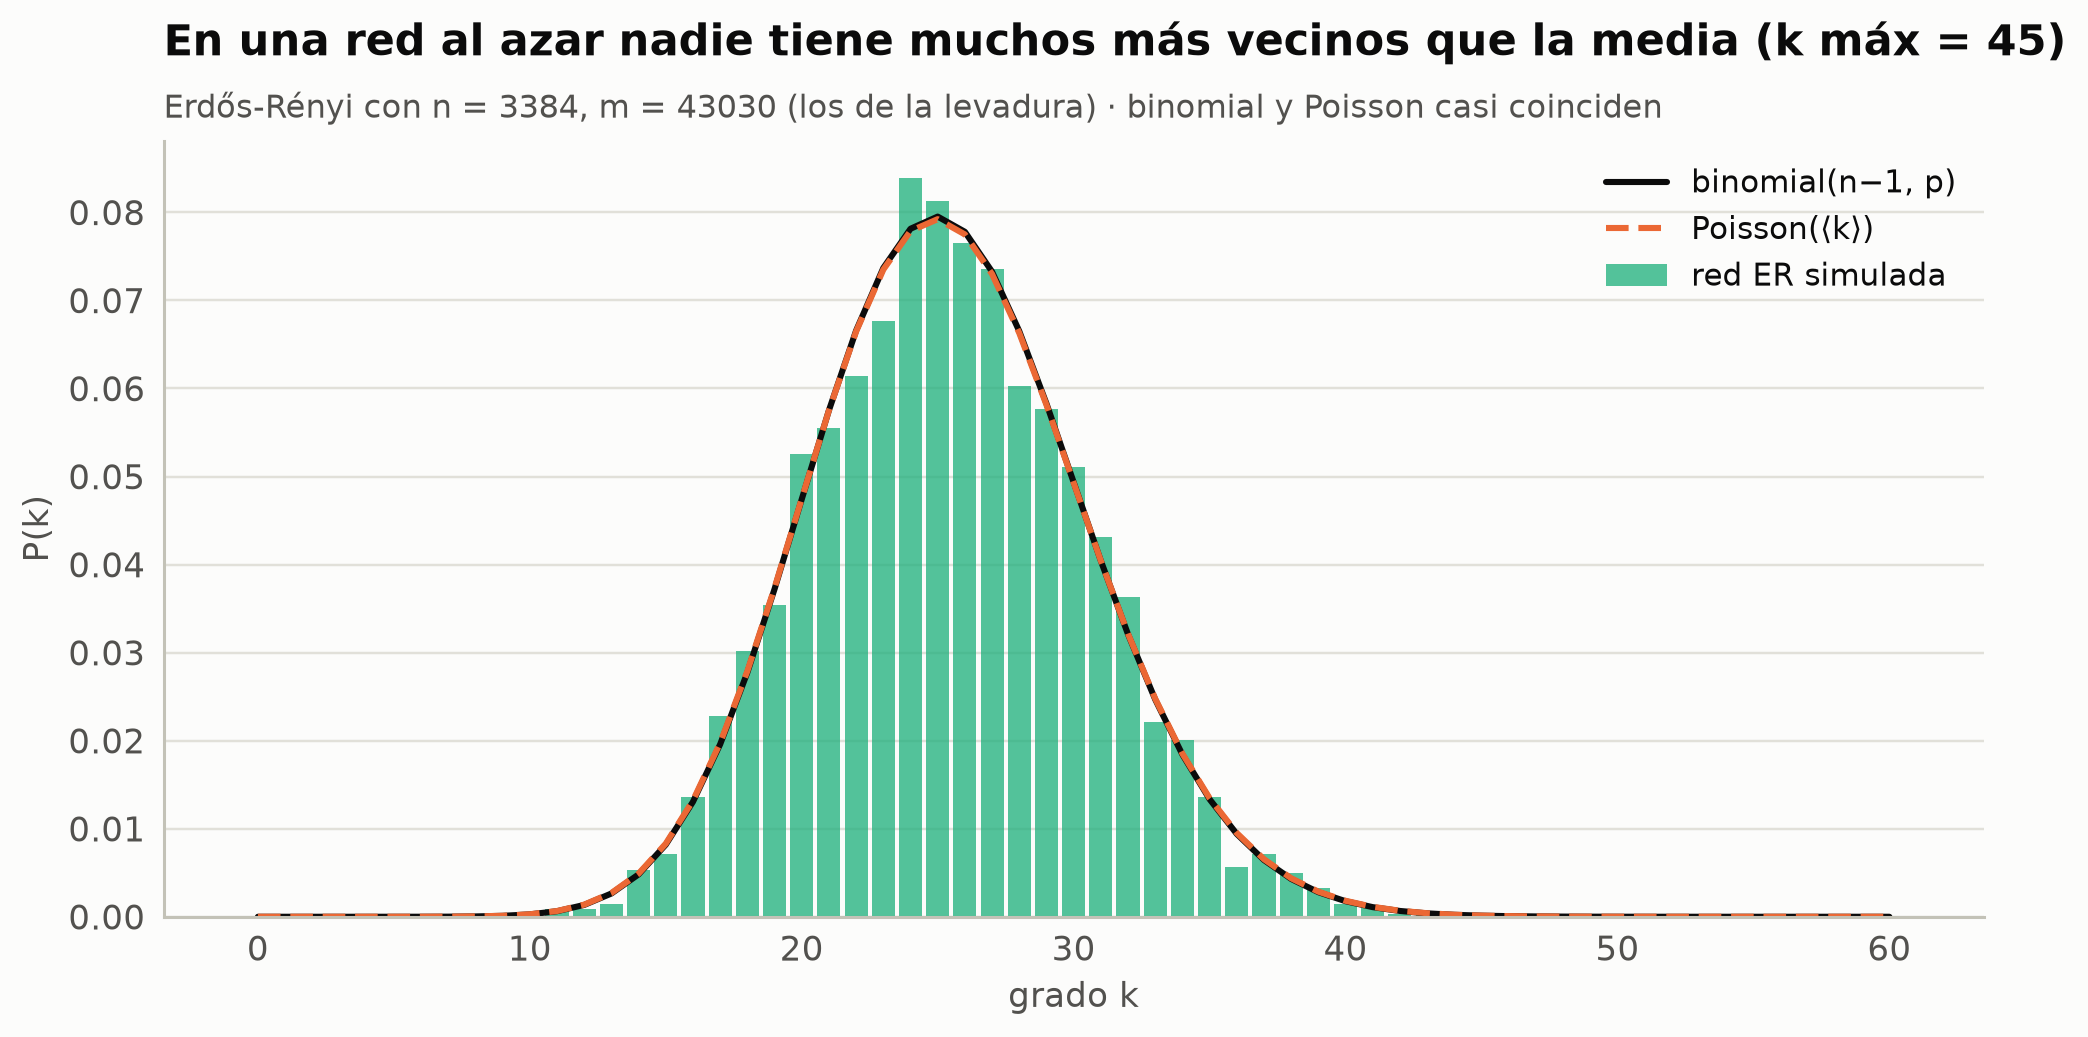

In [11]:
p_er = 2 * m / (n * (n - 1))
ER = nx.gnm_random_graph(n, m, seed=1)              # mismos n y m que la levadura (libro: seed=1)
gcer = ER.subgraph(max(nx.connected_components(ER), key=len))
L_er = np.mean([v for s0 in rng.choice(list(gcer), 200, replace=False)
                for v in nx.single_source_shortest_path_length(gcer, s0).values() if v])
C_er = nx.average_clustering(ER)
deg_er = np.array([d for _, d in ER.degree()])
print(f"p = {p_er:.5f}  C(ER) = {C_er:.4f} (teoría C = p = {p_er:.4f})")
print(f"L(ER) = {L_er:.2f}  (teoría ln n / ln<k> = {math.log(n) / math.log(2 * m / n):.2f})   kmax(ER) = {deg_er.max()}")

kk = np.arange(0, 61)
fig, ax = plt.subplots(figsize=(9, 4.6))
cnt = np.bincount(deg_er, minlength=61)[:61] / n
ax.bar(kk, cnt, color=ec.AQUA, alpha=0.75, width=0.85, label="red ER simulada")
ax.plot(kk, stats.binom.pmf(kk, n - 1, p_er), color=ec.INK, lw=2, label="binomial(n−1, p)")
ax.plot(kk, stats.poisson.pmf(kk, 2 * m / n), color=ec.ORANGE, lw=2, ls="--", label="Poisson(⟨k⟩)")
ax.set_xlabel("grado k"); ax.set_ylabel("P(k)")
ax.legend(loc="upper right")
ec.title(ax, f"En una red al azar nadie tiene muchos más vecinos que la media (k máx = {deg_er.max()})",
         f"Erdős-Rényi con n = {n}, m = {m} (los de la levadura) · binomial y Poisson casi coinciden")
plt.show()

> 🔎 **Qué observamos.** La campana está centrada en $\langle k\rangle\approx25$ y la binomial y la Poisson son
> indistinguibles. El agrupamiento simulado ($0{,}0076$) coincide con $p$, y la distancia media ($2{,}83$) está cerca
> de la estimación gruesa $2{,}51$ (la fórmula ignora que los vecindarios se solapan). Guarde dos números para la
> sección 6: en la red al azar, $C\approx0{,}0075$ y el nodo más conectado apenas duplica la media.

### 5.3 Watts-Strogatz (WS): el mundo pequeño

Las redes reales combinan dos rasgos que ER no reproduce a la vez: **distancias cortas** y **vecindarios muy
agrupados** (sus amigos se conocen entre sí, y aun así llega a cualquier persona del planeta en pocos pasos). Watts y
Strogatz (1998) mostraron que ambos coexisten en un modelo sencillo:

1. se parte de un **anillo** en el que cada nodo se une a sus $k$ vecinos más próximos (muy agrupado, pero lejano:
   $L\approx n/2k$);
2. se **reconecta** cada arista al azar con probabilidad $p$.

Unos pocos «atajos» bastan para desplomar $L$, mientras que $C$ apenas cambia, porque destruir triángulos requiere
reconectar muchas aristas. En el anillo, el agrupamiento vale $C(0)=\frac{3(k-2)}{4(k-1)}$.

**A mano.** Con $n=1000$ y $k=10$: $C(0)=3\cdot8/(4\cdot9)=0{,}667$ y $L(0)\approx n/2k=50$.

anillo: C0 = 0.667 (teoría 0.667),  L0 = 50.45 (teoría n/2k = 50.0)


    p  C_rel  L_rel
0.001  0.997  0.519
0.010  0.972  0.179
0.100  0.749  0.089 
(3.4 s)


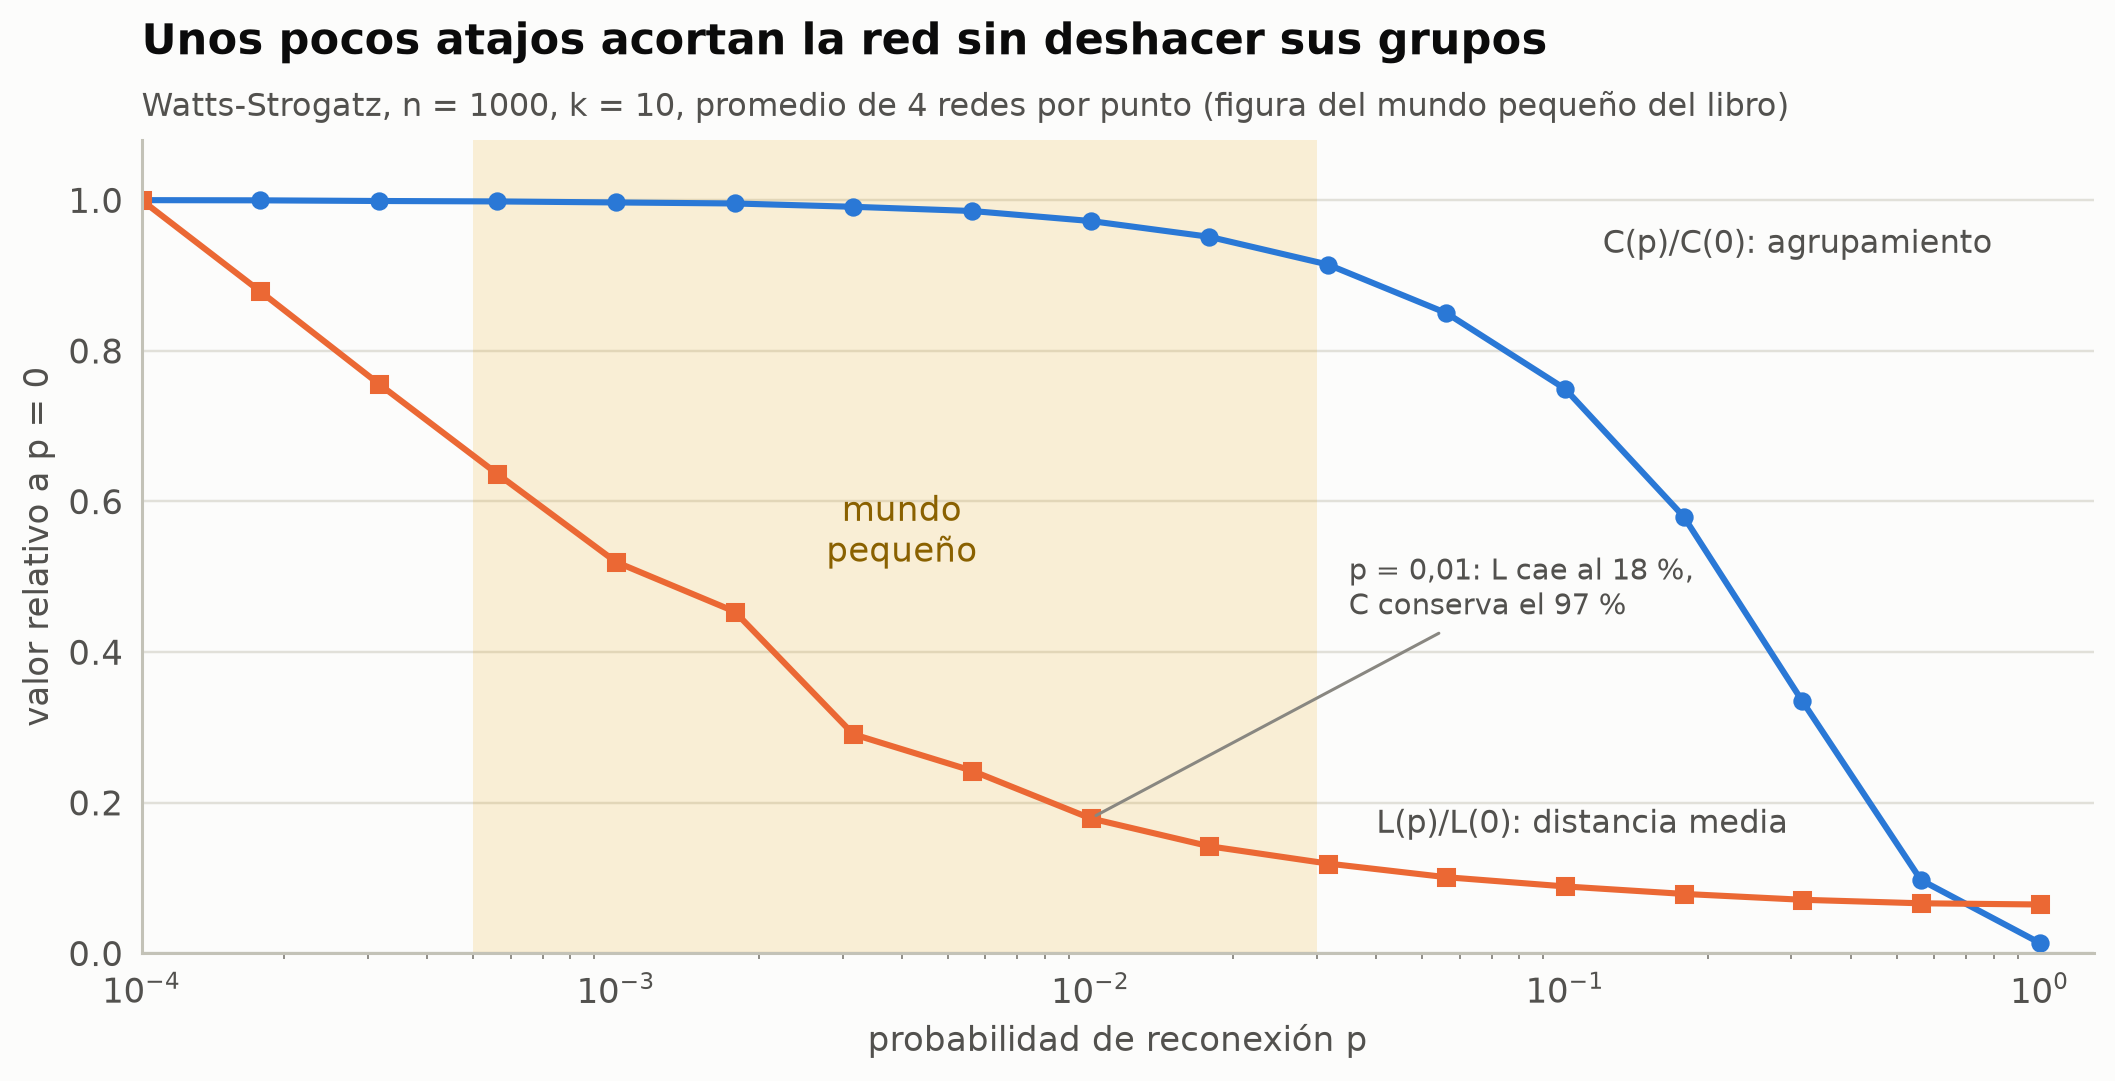

In [12]:
ps = np.logspace(-4, 0, 17)
nws, kws = 1000, 10
C0 = nx.average_clustering(nx.watts_strogatz_graph(nws, kws, 0))
L0 = nx.average_shortest_path_length(nx.watts_strogatz_graph(nws, kws, 0))
print(f"anillo: C0 = {C0:.3f} (teoría {3 * (kws - 2) / (4 * (kws - 1)):.3f}),  L0 = {L0:.2f} (teoría n/2k = {nws / (2 * kws):.1f})")
t0 = time.time()
ws_rows = []
for p in ps:                                        # 4 redes por punto, como el libro
    cs, ls = [], []
    for r in range(4):
        g = nx.connected_watts_strogatz_graph(nws, kws, p, seed=100 + r)
        cs.append(nx.average_clustering(g))
        srcs = rng.choice(nws, 150, replace=False)
        ls.append(np.mean([v for s0 in srcs for v in nx.single_source_shortest_path_length(g, s0).values() if v]))
    ws_rows.append((p, np.mean(cs) / C0, np.mean(ls) / L0))
ws = pd.DataFrame(ws_rows, columns=["p", "C_rel", "L_rel"])
print(ws.iloc[[4, 8, 12]].round(3).to_string(index=False), f"\n({time.time() - t0:.1f} s)")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.axvspan(5e-4, 3e-2, color=ec.YELLOW, alpha=0.15)
ax.text(4e-3, 0.52, "mundo\npequeño", ha="center", color="#8a6100", fontsize=11)
ax.plot(ws.p, ws.C_rel, "o-", color=ec.BLUE, ms=5)
ax.plot(ws.p, ws.L_rel, "s-", color=ec.ORANGE, ms=5)
ax.text(0.12, 0.93, "C(p)/C(0): agrupamiento", color=ec.INK_2, fontsize=10.5, ha="left")
ax.text(0.04, 0.16, "L(p)/L(0): distancia media", color=ec.INK_2, fontsize=10.5, ha="left")
ax.set_xscale("log"); ax.set_xlim(1e-4, 1.3); ax.set_ylim(0, 1.08)
ax.set_xticks([1e-4, 1e-3, 1e-2, 1e-1, 1])
ax.set_xlabel("probabilidad de reconexión p"); ax.set_ylabel("valor relativo a p = 0")
ax.annotate("p = 0,01: L cae al 18 %,\nC conserva el 97 %", (0.01, ws.L_rel.iloc[8]), xytext=(0.035, 0.45),
            fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ec.title(ax, "Unos pocos atajos acortan la red sin deshacer sus grupos",
         f"Watts-Strogatz, n = {nws}, k = {kws}, promedio de 4 redes por punto (figura del mundo pequeño del libro)")
plt.show()

> 🔎 **Qué observamos.** Las cifras del libro: con $p=0{,}001$, $L/L_0=0{,}52$ y $C/C_0=0{,}997$; con $p=0{,}01$
> (uno de cada cien enlaces reconectado), $L/L_0=0{,}18$ y $C/C_0=0{,}97$; con $p=0{,}1$, $0{,}089$ y $0{,}75$. La
> banda amarilla es el régimen de **mundo pequeño**: tan agrupado como una red regular y casi tan compacto como una
> aleatoria.

La animación muestra el mecanismo en un anillo de 30 nodos: cada cuadro sube $p$ y reconecta algunas aristas más
(las mismas que en el cuadro anterior, más unas nuevas). Mire cómo cambian $C$ y $L$ **de este pequeño anillo** en la
esquina.

![Vista previa: reconexión progresiva de un anillo de Watts-Strogatz (30 nodos, k = 4). Los atajos (naranja) desploman la distancia media L mucho antes de que el agrupamiento C empiece a bajar.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.1_ws_reconexion.gif)

*Vista previa: reconexión progresiva de un anillo de Watts-Strogatz (30 nodos, k = 4). Los atajos (naranja) desploman la distancia media L mucho antes de que el agrupamiento C empiece a bajar.*

In [13]:
N_R, K_R = 30, 4
rng_ws = np.random.default_rng(3)                   # generador propio: no altera el del libro
ring = [(i, (i + j) % N_R) for i in range(N_R) for j in range(1, K_R // 2 + 1)]
u_edge = rng_ws.random(len(ring))                   # la arista e se reconecta cuando p > u_e
targets = rng_ws.permutation(np.arange(N_R * 10) % N_R).reshape(-1)  # destinos aleatorios pre-sorteados

def ws_graph(p):
    g = nx.Graph(); g.add_nodes_from(range(N_R)); short = set()
    for e, (i, j) in enumerate(ring):
        if u_edge[e] < p:                           # reconectar: nuevo destino al azar sin lazos ni duplicados
            for t in targets[e * 7:(e * 7) + 7].tolist() + list(range(N_R)):
                if t != i and not g.has_edge(i, t) and (t - i) % N_R not in (1, 2, N_R - 1, N_R - 2):
                    g.add_edge(i, t); short.add((min(i, t), max(i, t))); break
        else:
            g.add_edge(i, j)
    return g, short

p_frames = np.r_[np.zeros(4), np.logspace(-2, 0, 40), np.ones(6)]
theta = 2 * np.pi * np.arange(N_R) / N_R
XY_R = np.c_[np.cos(theta), np.sin(theta)]
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 5.2), gridspec_kw=dict(width_ratios=[1.25, 1]), layout="none")
fig.subplots_adjust(left=0.02, right=0.97, bottom=0.12, top=0.80, wspace=0.18)
ttl = fig.text(0.02, 0.95, "", fontsize=14, fontweight="bold", va="top")
sub = fig.text(0.02, 0.89, "", fontsize=10.5, color=ec.INK_2, va="top")
g0, _ = ws_graph(0); C_ring0, L_ring0 = nx.average_clustering(g0), nx.average_shortest_path_length(g0)
CL = []                                             # C/C0 y L/L0 de cada cuadro, precalculados
for p in p_frames:
    g, _ = ws_graph(p)
    CL.append((nx.average_clustering(g) / C_ring0,
               (nx.average_shortest_path_length(g) if nx.is_connected(g) else np.nan) / L_ring0))
CL = np.array(CL)

def update(f):
    p = p_frames[f]
    g, short = ws_graph(p)
    Cg, Lg = CL[f]
    ax.clear(); ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25); ax.set_aspect("equal"); ax.axis("off")
    segs_n = [XY_R[[u, v]] for u, v in g.edges() if (min(u, v), max(u, v)) not in short]
    segs_s = [XY_R[[u, v]] for u, v in g.edges() if (min(u, v), max(u, v)) in short]
    ax.add_collection(LineCollection(segs_n, colors=ec.BASELINE, lw=1.3))
    ax.add_collection(LineCollection(segs_s, colors=ec.ORANGE, lw=1.6))
    ax.scatter(XY_R[:, 0], XY_R[:, 1], s=60, color=ec.BLUE, edgecolor="white", zorder=3)
    sel = (p_frames[:f + 1] > 0)
    hist_p, hist_c, hist_l = p_frames[:f + 1][sel], CL[:f + 1, 0][sel], CL[:f + 1, 1][sel]
    ax2.clear()
    ax2.plot(ws.p, ws.C_rel, color=ec.BLUE, lw=1, alpha=0.35); ax2.plot(ws.p, ws.L_rel, color=ec.ORANGE, lw=1, alpha=0.35)
    ax2.plot(hist_p, hist_c, "o", color=ec.BLUE, ms=4); ax2.plot(hist_p, hist_l, "s", color=ec.ORANGE, ms=4)
    ax2.set_xscale("log"); ax2.set_xlim(8e-3, 1.2); ax2.set_ylim(0, 1.1)
    ax2.set_xlabel("p"); ax2.set_title("C/C0 (azul) y L/L0 (naranja)", fontsize=11, loc="left")
    ax2.text(0.01, 0.06, "líneas tenues: n = 1000 (libro)", fontsize=8.5, color=ec.MUTED)
    ttl.set_text(f"Reconexión p = {p:.3f}".replace(".", ",") + f" · atajos: {len(short)} de {len(ring)} aristas")
    sub.set_text(f"C = {fmt(Cg * C_ring0, 2)} ({Cg:.0%} del anillo) · L = {fmt(Lg * L_ring0, 2)} ({Lg:.0%} del anillo)")
    return []

with plt.rc_context({"figure.constrained_layout.use": False}):   # conserva el diseño manual al guardar
    anim_html = ec.animate(fig, update, frames=len(p_frames), interval=200, name="16.1_ws_reconexion")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Cada atajo que cruza el anillo hace bajar claramente la distancia media, mientras
> que el agrupamiento casi no se mueve: cada atajo destruye a lo sumo unos pocos triángulos, pero acorta los caminos de
> muchísimos pares. Sólo cuando casi todas las aristas se han reconectado ($p\to1$) el anillo se convierte en una red
> aleatoria y el agrupamiento se desploma. (En un anillo de 30 nodos las curvas son ruidosas; las líneas tenues son las
> de $n=1000$.)

### 5.4 Barabási-Albert (BA): crecimiento y enlace preferencial

Ni ER ni WS producen nodos con muchísimas más conexiones que la media. Barabási y Albert (1999) observaron
distribuciones de grado de **cola larga** en varias redes reales y propusieron dos ingredientes:

* **crecimiento**: la red gana nodos con el tiempo;
* **enlace preferencial**: los nodos nuevos prefieren unirse a los ya muy conectados («el rico se hace más rico»),
  como una página web nueva que enlaza a las páginas que ya todo el mundo enlaza.

**Teorema (distribución de grado del modelo BA).** Si en cada paso se añade un nodo con $m$ aristas y cada arista se
une al nodo $i$ con probabilidad $\Pi(k_i)=k_i/\sum_j k_j$, entonces, en la aproximación de continuo y para $t\to\infty$,

$$
k_i(t)=m\left(\frac{t}{t_i}\right)^{1/2},\qquad P(k)=\frac{2m^2}{k^{3}}\quad (k\ge m),
$$

una **ley de potencias** $P(k)\propto k^{-\gamma}$ con $\gamma=3$, independiente de $m$.

| Símbolo | Significado |
|---|---|
| $m$ | aristas que trae cada nodo nuevo (¡en esta subsección $m$ no es el total de aristas!) |
| $t_i$ | instante en que el nodo $i$ se incorporó a la red |
| $\Pi(k_i)$ | probabilidad de que una arista nueva elija al nodo $i$ |
| $\gamma$ | exponente de la ley de potencias |

**Derivación.** En el instante $t$ hay unos $t$ nodos y $mt$ aristas, así que $\sum_j k_j=2mt$. Cada nodo nuevo
reparte $m$ aristas y el nodo $i$ recibe en promedio $m\,\Pi(k_i)$:

$$
\frac{dk_i}{dt}=m\,\frac{k_i}{2mt}=\frac{k_i}{2t}\;\Longrightarrow\;\ln k_i=\tfrac12\ln t+\text{cte}
\;\Longrightarrow\;k_i(t)=m\left(\frac{t}{t_i}\right)^{1/2},
$$

usando $k_i(t_i)=m$. **Los nodos más viejos son los más conectados.** Como los tiempos de llegada $t_i$ están
repartidos uniformemente en $[0,t]$,

$$
\Pr\big(k_i(t)<k\big)=\Pr\!\left(t_i>\frac{m^2t}{k^2}\right)=1-\frac{m^2}{k^2},
$$

y al derivar respecto de $k$ sale $P(k)=2m^2/k^3$. Una ley de potencias no tiene escala característica (de ahí
**red libre de escala**): su varianza diverge cuando $\gamma\le3$, y siempre hay una probabilidad no despreciable de
encontrar nodos con grado cientos de veces mayor que la media, los ***hubs***.

**A mano.** Con $m=3$, un nodo que llegó en $t_i=10$ tendrá, en $t=1000$, $k\approx3\sqrt{100}=30$; uno que llegó en
$t_i=1000$, sólo $k=3$. Comprobémoslo programando el modelo desde cero.

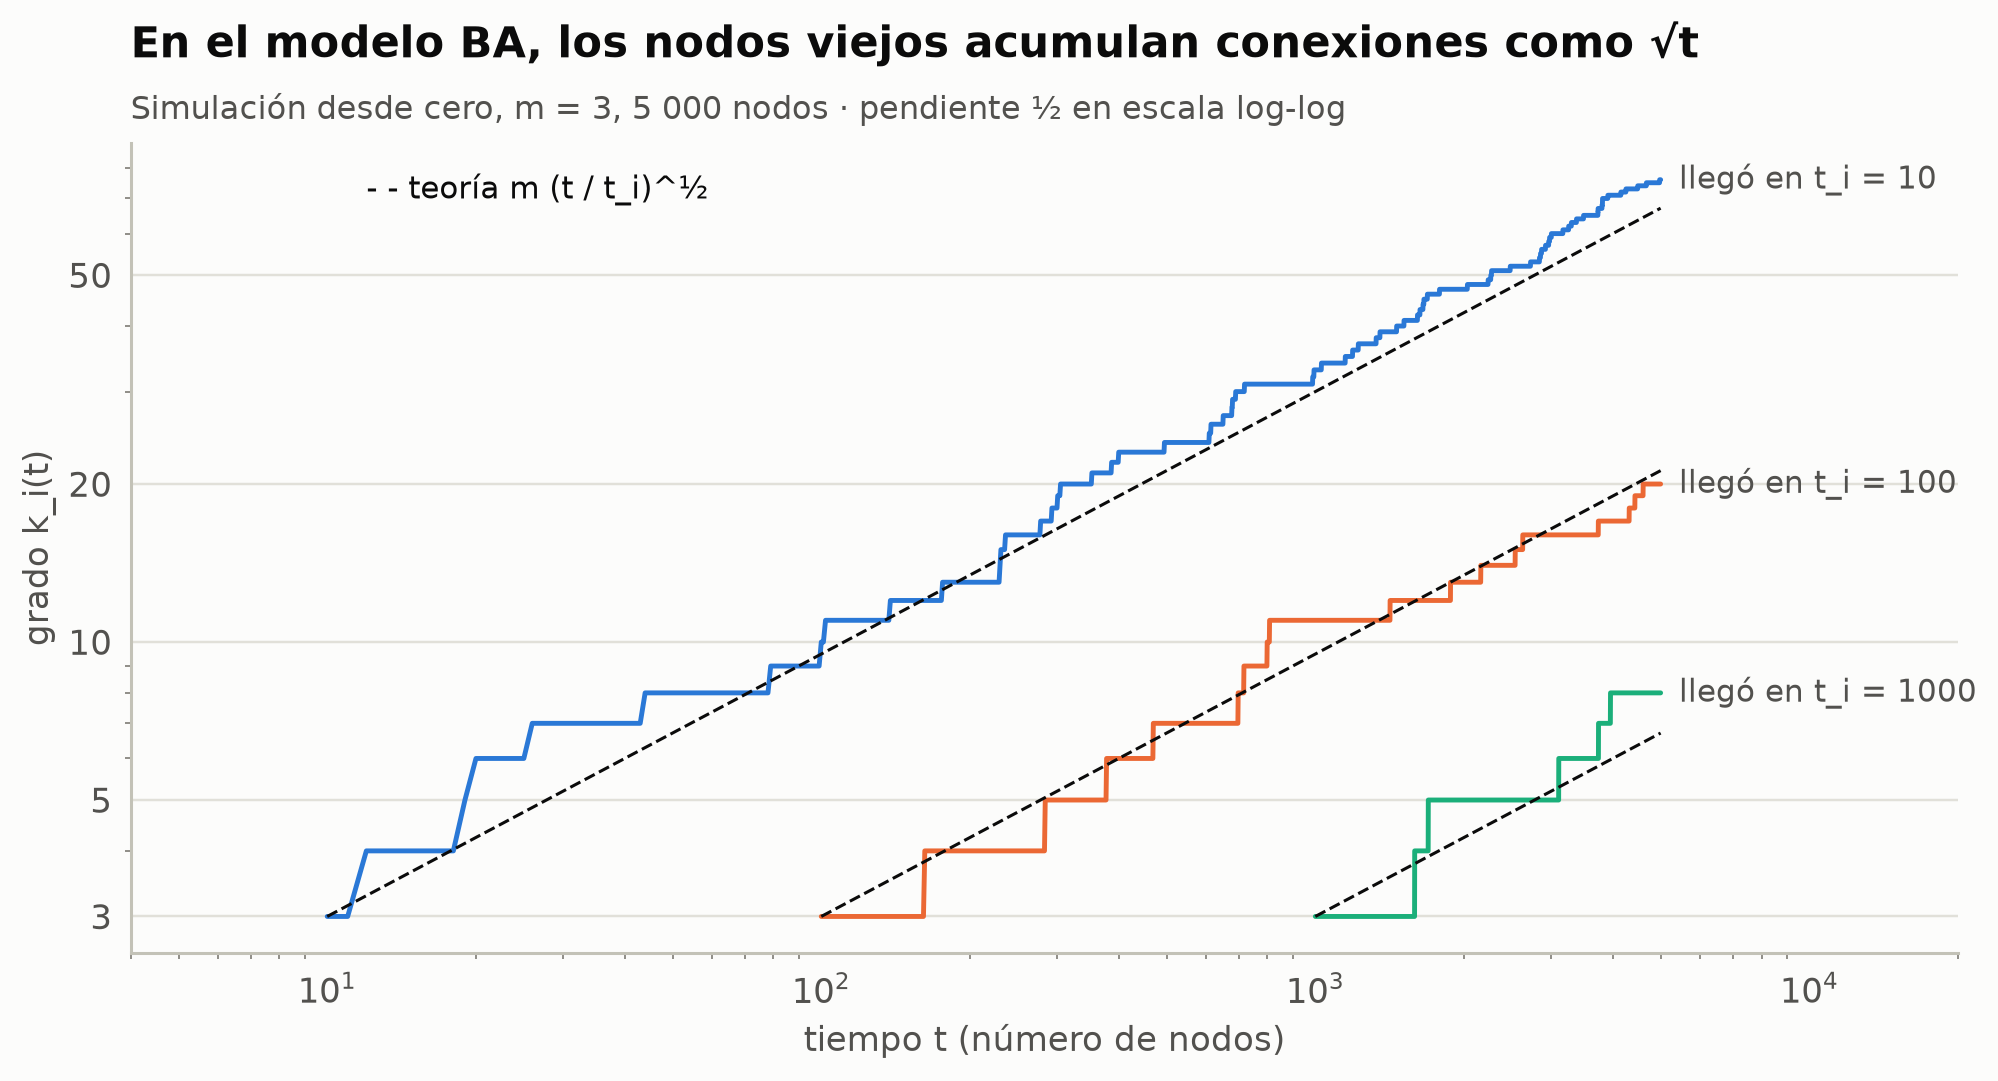

In [14]:
def barabasi_albert(n_final, m_new, seed=0, record=()):
    """Modelo BA desde cero. Truco: la lista 'stubs' contiene cada nodo tantas veces como su grado,
    así que elegir un elemento al azar de ella ES el enlace preferencial Π(k_i) = k_i / Σ k_j."""
    rng_ba = np.random.default_rng(seed)
    edges_ba = [(i, j) for i in range(m_new + 1) for j in range(i)]    # núcleo inicial completo
    stubs = [u for e in edges_ba for u in e]
    traj = {i: [] for i in record}
    kcount = np.bincount(stubs, minlength=n_final)
    for t in range(m_new + 1, n_final):
        chosen = set()
        while len(chosen) < m_new:
            chosen.add(stubs[rng_ba.integers(len(stubs))])
        for c in chosen:
            edges_ba.append((t, c)); stubs += [t, c]
            kcount[t] += 1; kcount[c] += 1
        for i in record:
            traj[i].append(kcount[i] if i <= t else np.nan)
    return edges_ba, traj

t0 = time.time()
track = (10, 100, 1000)
_, traj = barabasi_albert(5000, 3, seed=2, record=track)
tt = np.arange(4, 5000)
fig, ax = plt.subplots(figsize=(9, 4.8))
for c, ti in zip((ec.BLUE, ec.ORANGE, ec.AQUA), track):
    ax.plot(tt, traj[ti], color=c, lw=1.6)
    ax.plot(tt[tt >= ti], 3 * np.sqrt(tt[tt >= ti] / ti), color=ec.INK, lw=1, ls="--")
    ec.label_end(ax, 5000, traj[ti][-1], f"llegó en t_i = {ti}")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(4, 2e4)
ax.set_xlabel("tiempo t (número de nodos)"); ax.set_ylabel("grado k_i(t)")
ax.text(12, 70, "- - teoría m (t / t_i)^½", fontsize=10, color=ec.INK)
ec.title(ax, "En el modelo BA, los nodos viejos acumulan conexiones como √t",
         "Simulación desde cero, m = 3, 5 000 nodos · pendiente ½ en escala log-log")
ax.yaxis.set_major_formatter(plt.ScalarFormatter()); ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks([3, 5, 10, 20, 50])
plt.show()

> 🔎 **Qué observamos.** Las tres trayectorias son rectas paralelas de pendiente ½ en escala log-log, como predice
> $k_i\propto\sqrt{t/t_i}$; el ruido es grande al principio (pocas aristas) y se suaviza después. El nodo que llegó en
> $t_i=10$ termina con unas 75 conexiones en $t=5000$ (teoría: $3\sqrt{500}\approx67$) y el que llegó en $t_i=1000$,
> con 8 (teoría: $3\sqrt5\approx6{,}7$): una sola realización fluctúa alrededor de la predicción media. La **edad**
> es, en este modelo, la causa de la centralidad.

La animación muestra el crecimiento en directo con $m=2$: cada cuadro añade dos nodos (en naranja las aristas nuevas).
El tamaño de cada nodo es su grado.

![Vista previa: crecimiento de una red de Barabási-Albert (m = 2) hasta 100 nodos. Los primeros nodos se convierten en hubs porque cada recién llegado prefiere unirse a los ya muy conectados.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.1_ba_crecimiento.gif)

*Vista previa: crecimiento de una red de Barabási-Albert (m = 2) hasta 100 nodos. Los primeros nodos se convierten en hubs porque cada recién llegado prefiere unirse a los ya muy conectados.*

In [15]:
edges_anim, _ = barabasi_albert(100, 2, seed=5)
Gba_final = nx.Graph(edges_anim)
pos_ba = nx.kamada_kawai_layout(Gba_final)
XY_B = np.array([pos_ba[i] for i in range(100)])
steps = list(range(3, 101, 2))                         # 49 cuadros: 3, 5, …, 99 nodos
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 5.4), gridspec_kw=dict(width_ratios=[1.35, 1]), layout="none")
fig.subplots_adjust(left=0.02, right=0.97, bottom=0.12, top=0.80, wspace=0.2)
ttl = fig.text(0.02, 0.95, "", fontsize=14, fontweight="bold", va="top")
sub = fig.text(0.02, 0.89, "", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    nt = steps[f]
    e_now = [(u, v) for u, v in edges_anim if u < nt and v < nt]
    e_new = [(u, v) for u, v in e_now if max(u, v) >= nt - 2 and nt > 3]
    kk_ = np.bincount(np.ravel(e_now), minlength=nt)[:nt]
    ax.clear(); ax.axis("off")
    ax.add_collection(LineCollection([XY_B[[u, v]] for u, v in e_now], colors=ec.BASELINE, lw=0.9))
    ax.add_collection(LineCollection([XY_B[[u, v]] for u, v in e_new], colors=ec.ORANGE, lw=2.2))
    ax.scatter(XY_B[:nt, 0], XY_B[:nt, 1], s=12 + 9 * kk_, c=np.arange(nt), cmap=ec.CMAP_SEQ.reversed(),
               vmin=0, vmax=100, edgecolor="white", lw=0.6, zorder=3)
    top = np.argsort(kk_)[-3:]
    for i in top:
        ax.annotate(f"nodo {i}", XY_B[i], xytext=(6, 6), textcoords="offset points", fontsize=8.5, color=ec.INK_2)
    ax.set_xlim(XY_B[:, 0].min() - 0.1, XY_B[:, 0].max() + 0.1); ax.set_ylim(XY_B[:, 1].min() - 0.1, XY_B[:, 1].max() + 0.1)
    ax2.clear()
    ax2.bar(np.arange(nt), np.sort(kk_)[::-1], color=ec.BLUE, width=0.9)
    ax2.set_xlim(-1, 100); ax2.set_ylim(0, 30)
    ax2.set_xlabel("nodos ordenados por grado"); ax2.set_title("grado de cada nodo", fontsize=11, loc="left")
    ttl.set_text(f"Crecimiento con enlace preferencial: {nt} nodos, {len(e_now)} aristas")
    sub.set_text(f"grado máximo = {kk_.max()} (nodo {kk_.argmax()}) · mediana = {np.median(kk_):.0f} · "
                 "color: más oscuro = más antiguo")
    return []

with plt.rc_context({"figure.constrained_layout.use": False}):   # conserva el diseño manual al guardar
    anim_html = ec.animate(fig, update, frames=len(steps), interval=180, name="16.1_ba_crecimiento")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los nodos oscuros (los más antiguos) crecen sin parar, mientras que la mayoría de los recién
> llegados se queda con 2 o 3 aristas. El histograma de la derecha es muy desigual: unos pocos *hubs* y una larga fila
> de nodos con grado mínimo. En una red ER del mismo tamaño las barras serían casi todas iguales.

> ✅ **Compruebe su comprensión.** En el modelo BA con $m=13$ y $n=3384$, ¿qué fracción de nodos tiene $k\ge 52$
> (cuatro veces el mínimo)? *Respuesta:* $\Pr(k\ge k_0)=m^2/k_0^2=(13/52)^2=1/16\approx6\,\%$. En una Poisson con
> $\langle k\rangle=26$ sería del orden de $10^{-6}$ (unos $4{,}6\times10^{-6}$).

## 6. La red de la levadura frente a los modelos

Ya tenemos todo para comparar. Construimos también una red BA del mismo tamaño: con $n=3384$ nodos y
$m/n=43030/3384\approx12{,}7$, cada nodo nuevo trae $m=13$ aristas.

> 🤔 **Antes de ejecutar, prediga.** ¿Se parecerá más la levadura a ER o a BA en el agrupamiento $C$? ¿Y en el grado
> máximo?

In [16]:
mba = int(round(m / n))
BA = nx.barabasi_albert_graph(n, mba, seed=1)
deg_ba = np.array([d for _, d in BA.degree()])
gcba = BA.subgraph(max(nx.connected_components(BA), key=len))
L_ba = np.mean([v for s0 in np.random.default_rng(1).choice(list(gcba), 200, replace=False)
                for v in nx.single_source_shortest_path_length(gcba, s0).values() if v])
summary = pd.DataFrame({
    "levadura (STRING ≥700)": [n, m, deg.mean(), deg.max(), C_y, L_y],
    "Erdős-Rényi": [n, ER.number_of_edges(), deg_er.mean(), deg_er.max(), C_er, L_er],
    f"Barabási-Albert (m={mba})": [n, BA.number_of_edges(), deg_ba.mean(), deg_ba.max(), nx.average_clustering(BA), L_ba]},
    index=["n", "aristas", "<k>", "k máx", "C", "L"])
print(summary.round(4).to_string())
print(f"\nC(levadura) / C(ER) = {C_y / p_er:.0f} veces")
top50 = sorted(G.degree(), key=lambda x: -x[1])[:50]
print("8 proteínas de mayor grado:", top50[:8])
# Proteínas ribosómicas: RPS* (subunidad pequeña), RPL* (grande) y las del tallo ribosómico RPP0, RPP1A/1B, RPP2A/2B
# (ojo: RPP1, sin letra, es una subunidad de la RNasa P, no del ribosoma)
RIBO_STALK = {"RPP0", "RPP1A", "RPP1B", "RPP2A", "RPP2B"}
def is_ribosomal(u):
    return u.startswith(("RPS", "RPL")) or u in RIBO_STALK

ribo = [u for u, _ in top50 if is_ribosomal(u)]
print(f"ribosómicas entre las 50 de mayor grado: {len(ribo)} de 50 ({len(ribo) / 50:.2f}); "
      f"del tallo (RPP): {[u for u in ribo if u in RIBO_STALK]}; otras: {[u for u, _ in top50 if u not in ribo]}")

         levadura (STRING ≥700)  Erdős-Rényi  Barabási-Albert (m=13)
n                     3384.0000    3384.0000               3384.0000
aristas              43030.0000   43030.0000              43823.0000
<k>                     25.4314      25.4314                 25.9001
k máx                  282.0000      45.0000                338.0000
C                        0.5809       0.0076                  0.0291
L                        5.1644       2.8272                  2.7243

C(levadura) / C(ER) = 77 veces
8 proteínas de mayor grado: [('RPS13', 282), ('RPS7A', 274), ('RPS5', 272), ('RPS6B', 271), ('RPS3', 271), ('RPS14A', 270), ('RPS6A', 267), ('RPS4B', 265)]
ribosómicas entre las 50 de mayor grado: 50 de 50 (1.00); del tallo (RPP): ['RPP0']; otras: []


> 🔎 **Qué observamos.** Las cifras del libro: $n=3384$, $m=43030$, $\langle k\rangle=25{,}4$, componente gigante de
> 2 780 nodos, $C=0{,}58$ frente a $0{,}0075$ en ER (casi **ochenta** veces más) y $L\approx5{,}2$ frente a $2{,}8$.
> La levadura es un **mundo pequeño muy agrupado**: nada parecido a ER ni a BA ($C=0{,}029$). Su $L$ es mayor que el de
> los modelos porque su agrupamiento encierra las aristas dentro de los grupos en lugar de tender atajos. Y las 50
> proteínas más conectadas son **ribosómicas** (el libro dice 49; aquí son 50, contando la proteína del tallo RPP0).

### 6.1 La distribución de grado en escala doble logarítmica

Una ley de potencias $P(k)=c\,k^{-\gamma}$ se vuelve una **recta** al tomar logaritmos:
$\log P(k)=\log c-\gamma\log k$. Por eso se dibuja en ejes log-log. Pero con pocos nodos de grado alto el histograma
ingenuo es muy ruidoso en la cola; el libro agrupa los grados en intervalos de **anchura logarítmica creciente**
($1, 2, 3, 4, 5, 7, 10, 14, 20, 28, \dots$ para la levadura) y divide cada recuento por la anchura del intervalo.

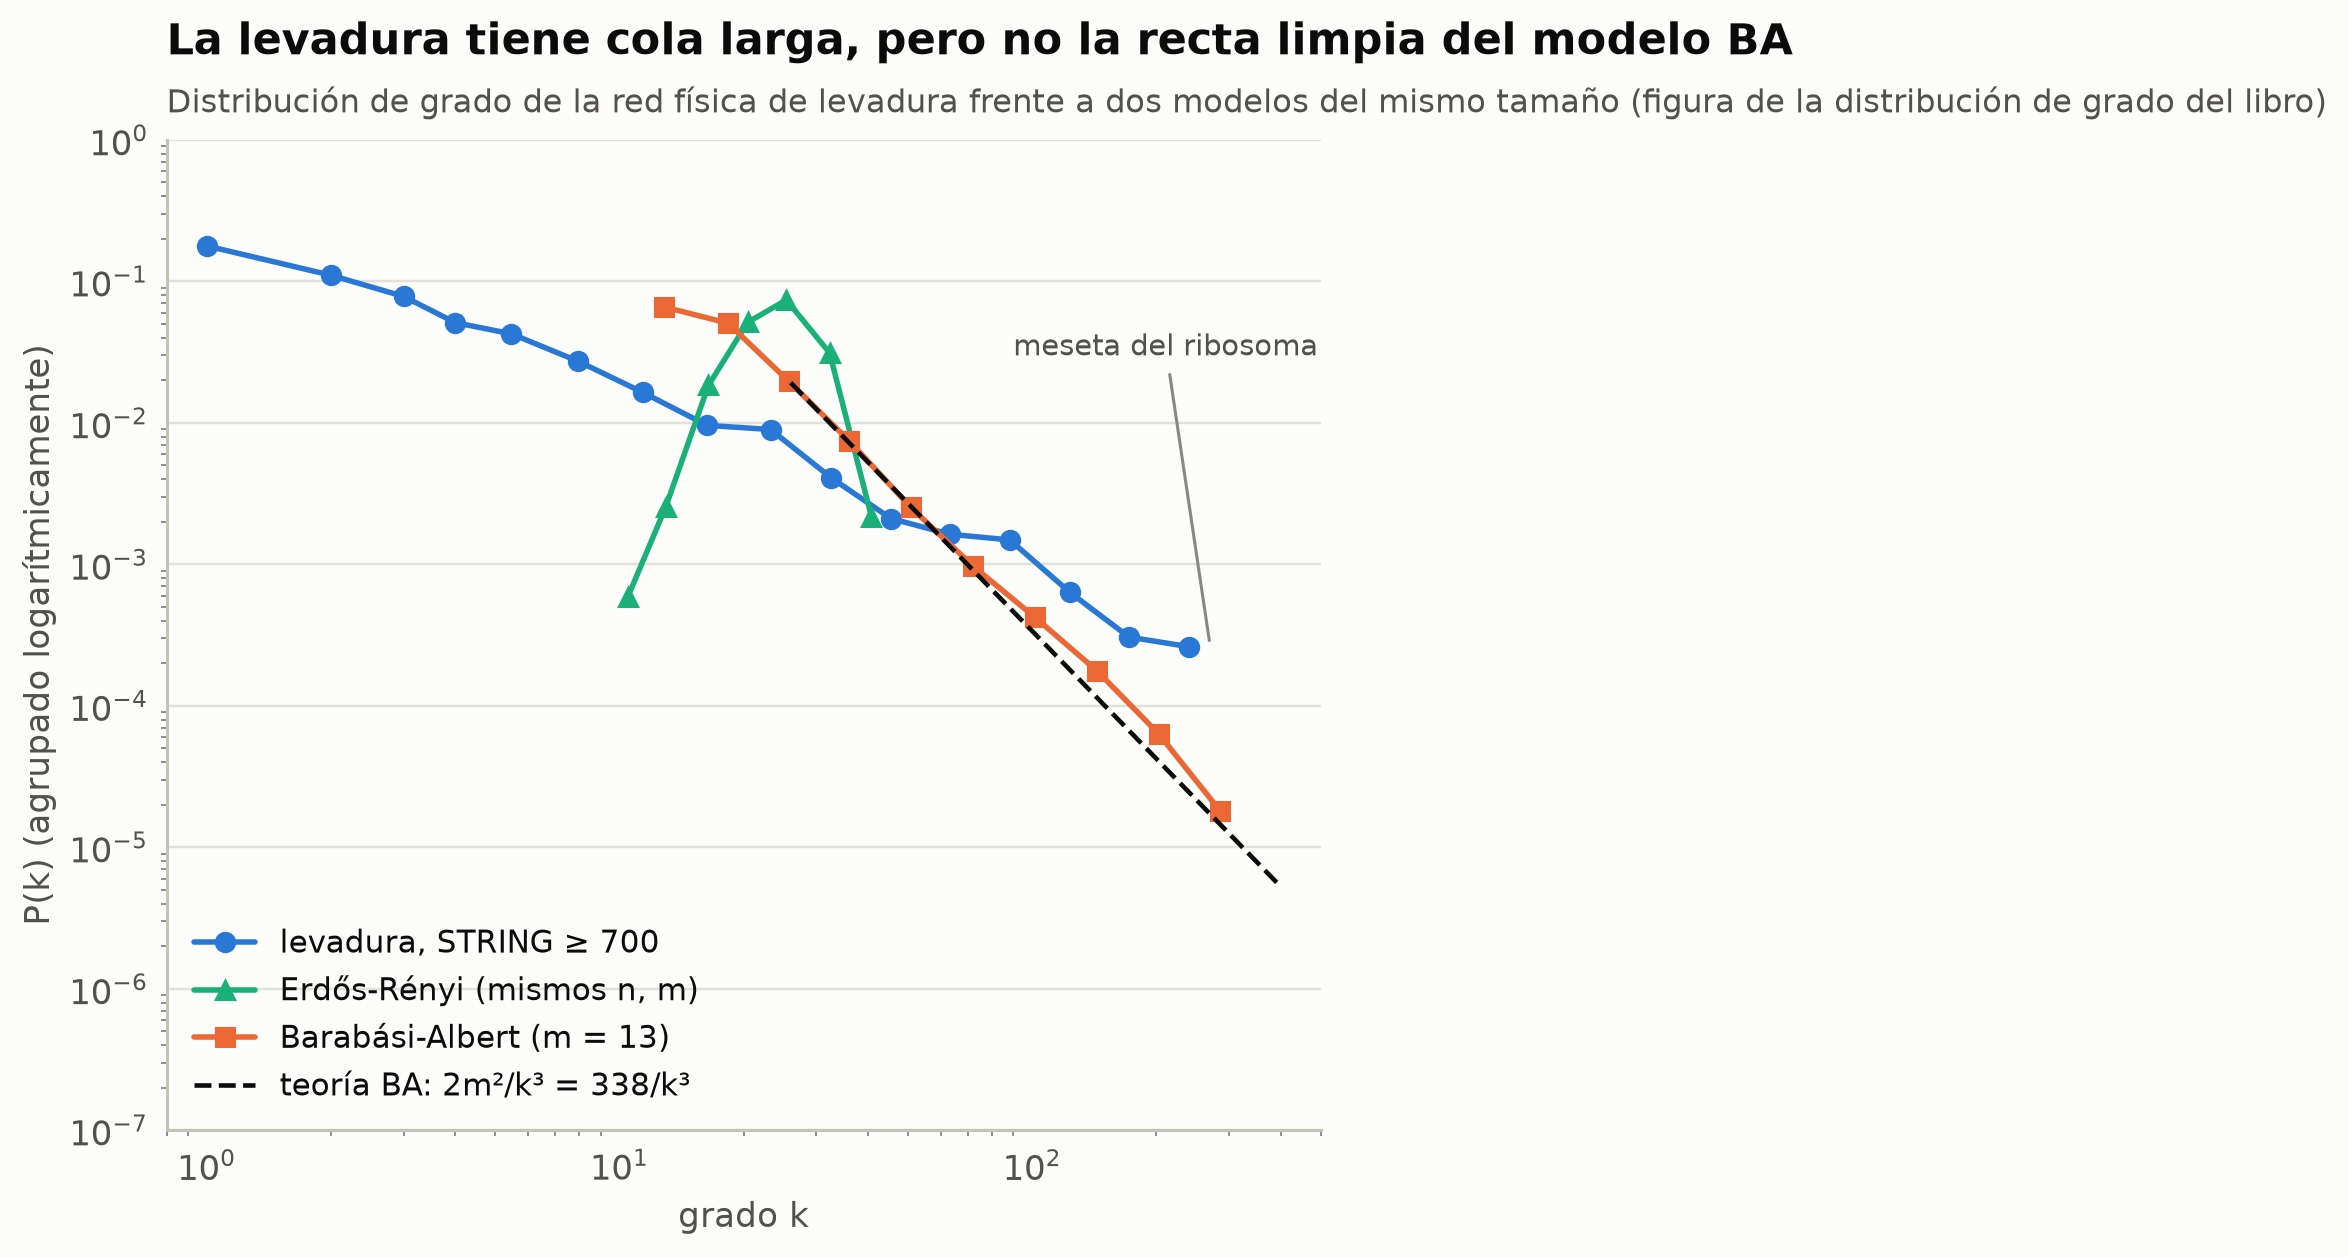

In [17]:
def logbin(d, nb=18):
    """Histograma con intervalos logarítmicos (como figuras/cap16/generar.py): devuelve (k centro, P(k))."""
    d = np.asarray(d); d = d[d > 0]
    edges_ = np.unique(np.round(np.logspace(0, np.log10(d.max() + 1), nb)).astype(int))
    rows = []
    for a, b in zip(edges_[:-1], edges_[1:]):
        c = ((d >= a) & (d < b)).sum()
        if c:
            rows.append((math.sqrt(a * (b - 1)) if b - 1 > a else a, c / (len(d) * (b - a))))
    return np.array(rows)

lb = {"levadura": logbin(deg), "ER": logbin(deg_er), "BA": logbin(deg_ba)}
fig, ax = plt.subplots(figsize=(9.5, 5.6))
for key, col, mk, lab in (("levadura", ec.BLUE, "o", "levadura, STRING ≥ 700"),
                          ("ER", ec.AQUA, "^", "Erdős-Rényi (mismos n, m)"),
                          ("BA", ec.ORANGE, "s", f"Barabási-Albert (m = {mba})")):
    ax.plot(lb[key][:, 0], lb[key][:, 1], marker=mk, color=col, ms=6, lw=1.8, label=lab)
kth = np.linspace(26, 400, 50)
ax.plot(kth, 2 * mba ** 2 / kth ** 3, color=ec.INK, ls="--", lw=1.5, label=f"teoría BA: 2m²/k³ = {2 * mba ** 2}/k³")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.8, 500); ax.set_ylim(1e-7, 1)
ax.set_xlabel("grado k"); ax.set_ylabel("P(k) (agrupado logarítmicamente)")
ax.legend(loc="lower left")
ax.annotate("meseta del ribosoma", (270, lb["levadura"][-1, 1]), xytext=(90, 3e-2), fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ec.title(ax, "La levadura tiene cola larga, pero no la recta limpia del modelo BA",
         "Distribución de grado de la red física de levadura frente a dos modelos del mismo tamaño (figura de la distribución de grado del libro)")
plt.show()

> 🔎 **Qué observamos.** La red ER (verde) concentra todos sus nodos alrededor de $\langle k\rangle\approx25$, sin cola.
> El modelo BA (naranja) sigue la recta de pendiente $-3$ predicha por la teoría. La levadura muestra una cola ancha y
> extendida, pero no una recta: una **meseta** hasta $k\approx300$ producida por las proteínas ribosómicas, que forman
> una «bola» casi completa de aristas (recuerde el modelo matriz de la sección 3).

Una alternativa sin agrupar es la **distribución acumulada complementaria** (CCDF), $\Pr(K\ge k)$: cada nodo aporta un
punto, no hay que elegir intervalos, y una ley de potencias con exponente $\gamma$ da una recta de pendiente
$-(\gamma-1)$. La figura interactiva permite ver **qué proteínas** hay detrás de cada punto.

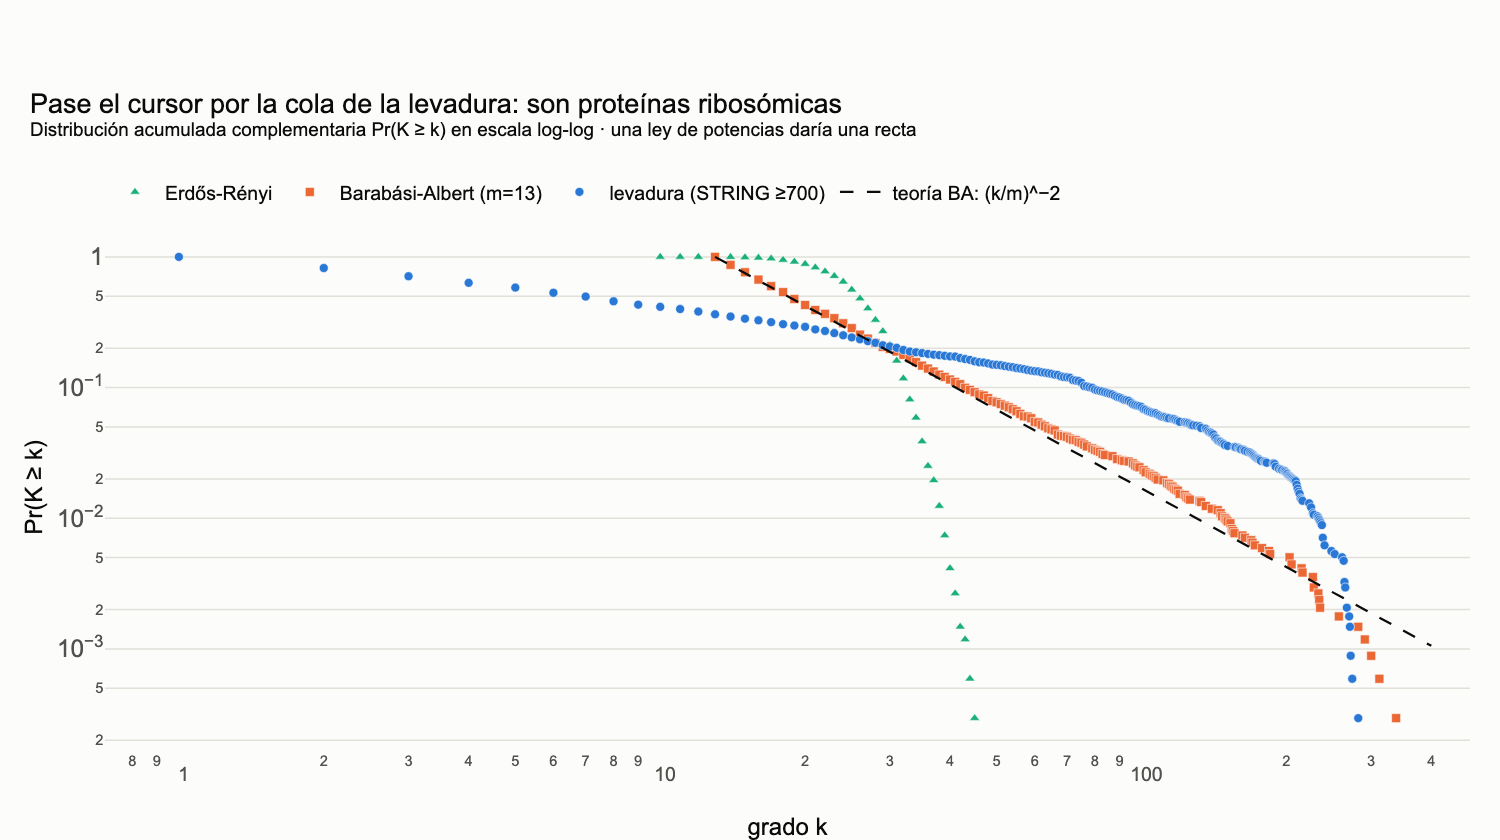

In [18]:
def ccdf(d):
    ks = np.sort(np.unique(d))
    return ks, np.array([(d >= k).mean() for k in ks])

names_by_k = {}
for u, k in G.degree():
    names_by_k.setdefault(k, []).append(u)
fig = go.Figure()
for key, d, col, sym in (("Erdős-Rényi", deg_er, ec.AQUA, "triangle-up"), (f"Barabási-Albert (m={mba})", deg_ba, ec.ORANGE, "square"),
                         ("levadura (STRING ≥700)", deg, ec.BLUE, "circle")):
    ks, cc = ccdf(d)
    if key.startswith("levadura"):
        ex = [", ".join(sorted(names_by_k[k])[:4]) + (" …" if len(names_by_k[k]) > 4 else "") for k in ks]
        cnt_ = [len(names_by_k[k]) for k in ks]
        cd = np.column_stack([cnt_, ex])
        ht = ("<b>k = %{x}</b><br>Pr(K ≥ k) = %{y:.2e}<br>proteínas con este grado: %{customdata[0]}"
              "<br>p. ej.: %{customdata[1]}<extra>levadura</extra>")
    else:
        cd = np.column_stack([[(d == k).sum() for k in ks]])
        ht = "<b>k = %{x}</b><br>Pr(K ≥ k) = %{y:.2e}<br>nodos con este grado: %{customdata[0]}<extra>" + key + "</extra>"
    fig.add_trace(go.Scatter(x=ks, y=cc, mode="markers", name=key, customdata=cd, hovertemplate=ht,
                             marker=dict(color=col, size=6, symbol=sym, line=dict(color="white", width=0.4))))
kk2 = np.array([13, 400])
fig.add_trace(go.Scatter(x=kk2, y=(kk2 / 13.0) ** -2, mode="lines", name="teoría BA: (k/m)^−2",
                         line=dict(color=ec.INK, dash="dash", width=1.5), hoverinfo="skip"))
fig.update_layout(
    title="Pase el cursor por la cola de la levadura: son proteínas ribosómicas<br>"
          "<sup>Distribución acumulada complementaria Pr(K ≥ k) en escala log-log · una ley de potencias daría una recta</sup>",
    xaxis=dict(type="log", title="grado k"), yaxis=dict(type="log", title="Pr(K ≥ k)", exponentformat="power"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=560, margin=dict(t=150, l=70, r=20, b=60))
fig.show()

### 6.2 ¿Es «libre de escala»? Cómo estimar $\gamma$ sin engañarse

La tentación es ajustar una recta por mínimos cuadrados al gráfico log-log y leer la pendiente. Es un **mal
estimador**: los puntos de la cola tienen muy pocos nodos (mucho ruido), el resultado depende de cómo se agrupe y no
hay forma honesta de dar un intervalo de confianza. Lo correcto es la **máxima verosimilitud** (Clauset, Shalizi y
Newman, 2009). Para los grados $k_i\ge k_{\min}$ de una ley de potencias discreta, una aproximación excelente es

$$
\hat\gamma=1+N\left[\sum_{i=1}^{N}\ln\frac{k_i}{k_{\min}-\tfrac12}\right]^{-1},
\qquad \mathrm{EE}(\hat\gamma)\approx\frac{\hat\gamma-1}{\sqrt N}.
$$

| Símbolo | Significado |
|---|---|
| $k_{\min}$ | grado a partir del cual suponemos que vale la ley de potencias (el libro usa $k_{\min}=2m=26$) |
| $N$ | número de nodos de la cola ($k_i\ge k_{\min}$) |
| $\hat\gamma$ | exponente estimado |
| EE | error estándar aproximado |

La idea: si $P(k)\propto k^{-\gamma}$, los logaritmos $\ln(k/k_{\min})$ siguen una exponencial de parámetro
$\gamma-1$, y el estimador de máxima verosimilitud de una exponencial es el inverso de la media.

 levadura: pendiente MC log-log (k ≥ 10) = -1.40   γ̂ MV (kmin = 26) = 1.99 ± 0.04  (N cola = 792)
       BA: pendiente MC log-log (k ≥ 10) = -2.71   γ̂ MV (kmin = 26) = 2.83 ± 0.06  (N cola = 860)


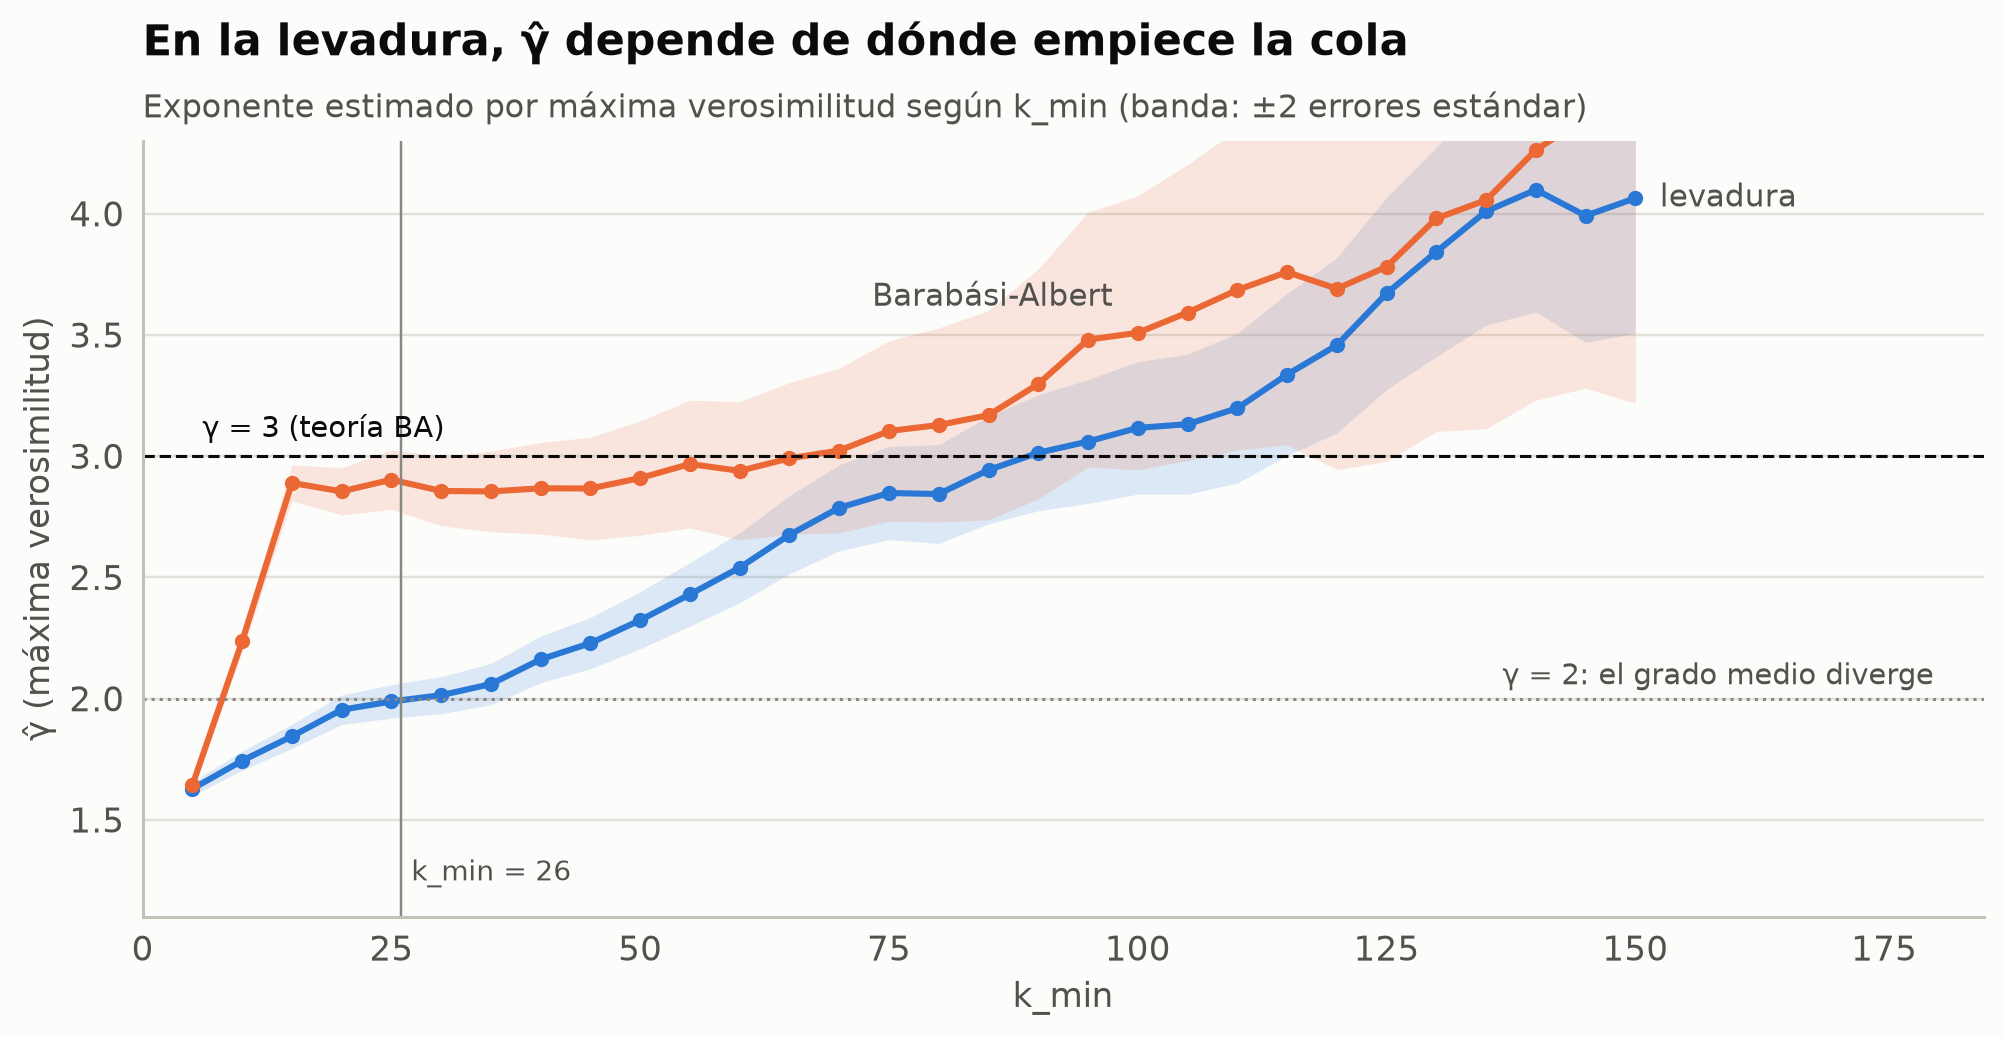

In [19]:
def gamma_mle(d, kmin):
    t = d[d >= kmin]
    g = 1 + len(t) / np.sum(np.log(t / (kmin - 0.5)))
    return g, (g - 1) / np.sqrt(len(t)), len(t)

kmin = 2 * mba
for name, d in (("levadura", deg), ("BA", deg_ba)):
    rows = lb["levadura" if name == "levadura" else "BA"]
    sel = rows[:, 0] >= 10
    slope = np.polyfit(np.log10(rows[sel, 0]), np.log10(rows[sel, 1]), 1)[0]
    g, se, nt = gamma_mle(d, kmin)
    print(f"{name:>9}: pendiente MC log-log (k ≥ 10) = {slope:.2f}   γ̂ MV (kmin = {kmin}) = {g:.2f} ± {se:.2f}  (N cola = {nt})")

kmins = np.arange(5, 151, 5)
fig, ax = plt.subplots(figsize=(9, 4.6))
for name, d, col in (("levadura", deg, ec.BLUE), ("Barabási-Albert", deg_ba, ec.ORANGE)):
    gg = np.array([gamma_mle(d, k)[:2] for k in kmins])
    ax.fill_between(kmins, gg[:, 0] - 2 * gg[:, 1], gg[:, 0] + 2 * gg[:, 1], color=col, alpha=0.15, lw=0)
    ax.plot(kmins, gg[:, 0], color=col, marker="o", ms=4)
    lab_y = gg[-1, 0] if name == "levadura" else gg[kmins == 95, 0][0]
    ax.annotate(name, (kmins[-1] if name == "levadura" else 95, lab_y), xytext=(8, 0 if name == "levadura" else 14),
                textcoords="offset points", fontsize=10, color=ec.INK_2, va="center", ha="left" if name == "levadura" else "right")
ax.axhline(3, color=ec.INK, ls="--", lw=1); ax.text(6, 3.05, "γ = 3 (teoría BA)", fontsize=9.5, va="bottom")
ax.axhline(2, color=ec.MUTED, ls=":", lw=1); ax.text(180, 2.03, "γ = 2: el grado medio diverge", fontsize=9.5, va="bottom", ha="right", color=ec.INK_2)
ax.axvline(kmin, color=ec.MUTED, lw=0.8); ax.text(kmin + 1, 1.25, f"k_min = {kmin}", fontsize=9, color=ec.INK_2)
ax.set_xlabel("k_min"); ax.set_ylabel("γ̂ (máxima verosimilitud)"); ax.set_xlim(0, 185); ax.set_ylim(1.1, 4.3)
ec.title(ax, "En la levadura, γ̂ depende de dónde empiece la cola",
         "Exponente estimado por máxima verosimilitud según k_min (banda: ±2 errores estándar)")
plt.show()

> 🔎 **Qué observamos.** Con $k_{\min}=26$ reproducimos el libro: $\hat\gamma=1{,}99$ para la levadura y $2{,}83$ para
> BA (valor teórico 3). La pendiente por mínimos cuadrados da números muy distintos ($-1{,}40$ y $-2{,}71$): **no la use
> para estimar $\gamma$**. Para BA, $\hat\gamma$ forma una **meseta** cerca de 2,9 entre $k_{\min}\approx15$ y 70, y sólo
> después sube por el corte de tamaño finito (en una red de 3 384 nodos no puede haber grados arbitrariamente altos);
> para la levadura, $\hat\gamma$ **sube sin parar** con $k_{\min}$, de 1,6 a 4: no hay meseta, síntoma de que **no hay
> una única ley de potencias**. Un exponente cercano a 2 delata que la cola la dominan unos pocos complejos grandes (el
> ribosoma), no un proceso de crecimiento como el de BA.

> 📜 **¿Son raras las redes libres de escala?** Durante una década la «ley de potencias» fue casi un dogma. Broido y
> Clauset (2019) aplicaron herramientas estadísticas modernas a casi 1 000 redes sociales, biológicas, tecnológicas, de
> transporte y de información: las redes **fuertemente** libres de escala resultaron empíricamente raras, y para la
> mayoría una log-normal se ajusta igual de bien o mejor. La lección práctica es metodológica: una recta aproximada en
> un gráfico log-log **no demuestra** una ley de potencias; hay que ajustar por máxima verosimilitud, elegir
> $k_{\min}$ con criterio y comparar con distribuciones alternativas.

> ✅ **Compruebe su comprensión.** Si eliminamos de la red todas las proteínas ribosómicas (RPS*, RPL* y las del tallo RPP), ¿esperaría que
> $\hat\gamma$ suba o baje? *Respuesta:* que suba: desaparece la meseta de grados 200–280 y la cola se acorta (lo
> comprobará en el ejercicio 3).

## 7. Centralidad, esencialidad y medicina de redes

Si la topología importa, las proteínas centrales deberían ser especiales. Jeong *et al.* (2001) analizaron la red de
interacciones de levadura y encontraron que la probabilidad de que eliminar una proteína sea **letal** crece con su
número de interacciones: las proteínas muy conectadas tienden a ser **esenciales**. Es el principio de
**centralidad-letalidad**. Pongámoslo a prueba con datos reales:

* **esencialidad**: la colección de deleciones de levadura (Giaever *et al.*, 2002), que eliminó uno a uno casi todos
  los genes y encontró unos 1 100 imprescindibles para crecer en medio rico. Tomamos las anotaciones de SGD
  (*Saccharomyces* Genome Database, archivo `phenotype_data.tab`): mutantes nulos del «systematic mutation set» de ese
  artículo, «inviable» = esencial.
* **red**: la misma red física de STRING.

Para resumir cuánto «predice» una medida de centralidad la esencialidad usamos el **AUC** (área bajo la curva ROC): la
probabilidad de que una proteína esencial elegida al azar tenga mayor centralidad que una no esencial elegida al azar
(0,5 = azar, 1 = separación perfecta).

In [20]:
URL_SGD = "https://downloads.yeastgenome.org/curation/literature/phenotype_data.tab"  # original (39 MB); usamos el extracto
via = pd.read_csv(course_file("161_sgd_viabilidad_giaever2002.tsv.gz"), sep="\t", comment="#")
print(f"SGD / Giaever 2002: {len(via)} genes, {via.essential.sum()} esenciales ({via.essential.mean():.1%})")
label = dict(zip(via.orf, via.essential)); label.update(dict(zip(via.gene, via.essential)))

t0 = time.time()
bc_gc = nx.betweenness_centrality(gc, k=300, seed=1)          # aproximación con 300 orígenes (exacta: minutos)
clu = nx.clustering(G)
net = pd.DataFrame({"k": dict(G.degree()), "b": pd.Series(bc_gc), "C": pd.Series(clu)})
net["essential"] = net.index.map(label)
net["ribosomal"] = net.index.map(is_ribosomal).astype(bool)
net = net.dropna(subset=["essential"])
print(f"proteínas de la red con anotación: {len(net)} de {n}; esenciales: {net.essential.mean():.1%}  ({time.time() - t0:.1f} s)")

def auc(score, y):
    """AUC = probabilidad de que una esencial tenga más puntuación que una no esencial (Mann-Whitney)."""
    y = np.asarray(y, bool); r = stats.rankdata(score)
    n1, n0 = y.sum(), (~y).sum()
    return (r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

nb_ = net.dropna(subset=["b"])
print(f"AUC grado = {auc(net.k, net.essential):.3f} · intermediación = {auc(nb_.b, nb_.essential):.3f} · "
      f"agrupamiento = {auc(net.C, net.essential):.3f}")
rib = net[net.ribosomal]
print(f"proteínas ribosómicas: {len(rib)}, esenciales: {int(rib.essential.sum())} ({rib.essential.mean():.1%})")
# ¿Tiene cada gen ribosómico su pareja parálogo A/B (RPS6A/RPS6B…) en la tabla de viabilidad?
has_pair = rib.index.map(lambda u: u[-1] in "AB" and (u[:-1] + ("B" if u[-1] == "A" else "A")) in label)
has_pair = np.asarray(has_pair, bool)
for txt, sub in (("con su pareja A/B en la tabla", rib[has_pair]), ("sin pareja A/B en la tabla", rib[~has_pair])):
    print(f"  {txt}: {int(sub.essential.sum())} esenciales de {len(sub)} ({sub.essential.mean():.0%})")

SGD / Giaever 2002: 5777 genes, 1100 esenciales (19.0%)


proteínas de la red con anotación: 3205 de 3384; esenciales: 28.8%  (2.5 s)
AUC grado = 0.692 · intermediación = 0.601 · agrupamiento = 0.535
proteínas ribosómicas: 127, esenciales: 20 (15.7%)
  con su pareja A/B en la tabla: 4 esenciales de 98 (4%)
  sin pareja A/B en la tabla: 16 esenciales de 29 (55%)


> 🤔 **Antes de ejecutar, prediga.** Las proteínas ribosómicas son las de mayor grado y el ribosoma es imprescindible
> para la vida. ¿Qué fracción de ellas cree que es esencial en la colección de deleciones?

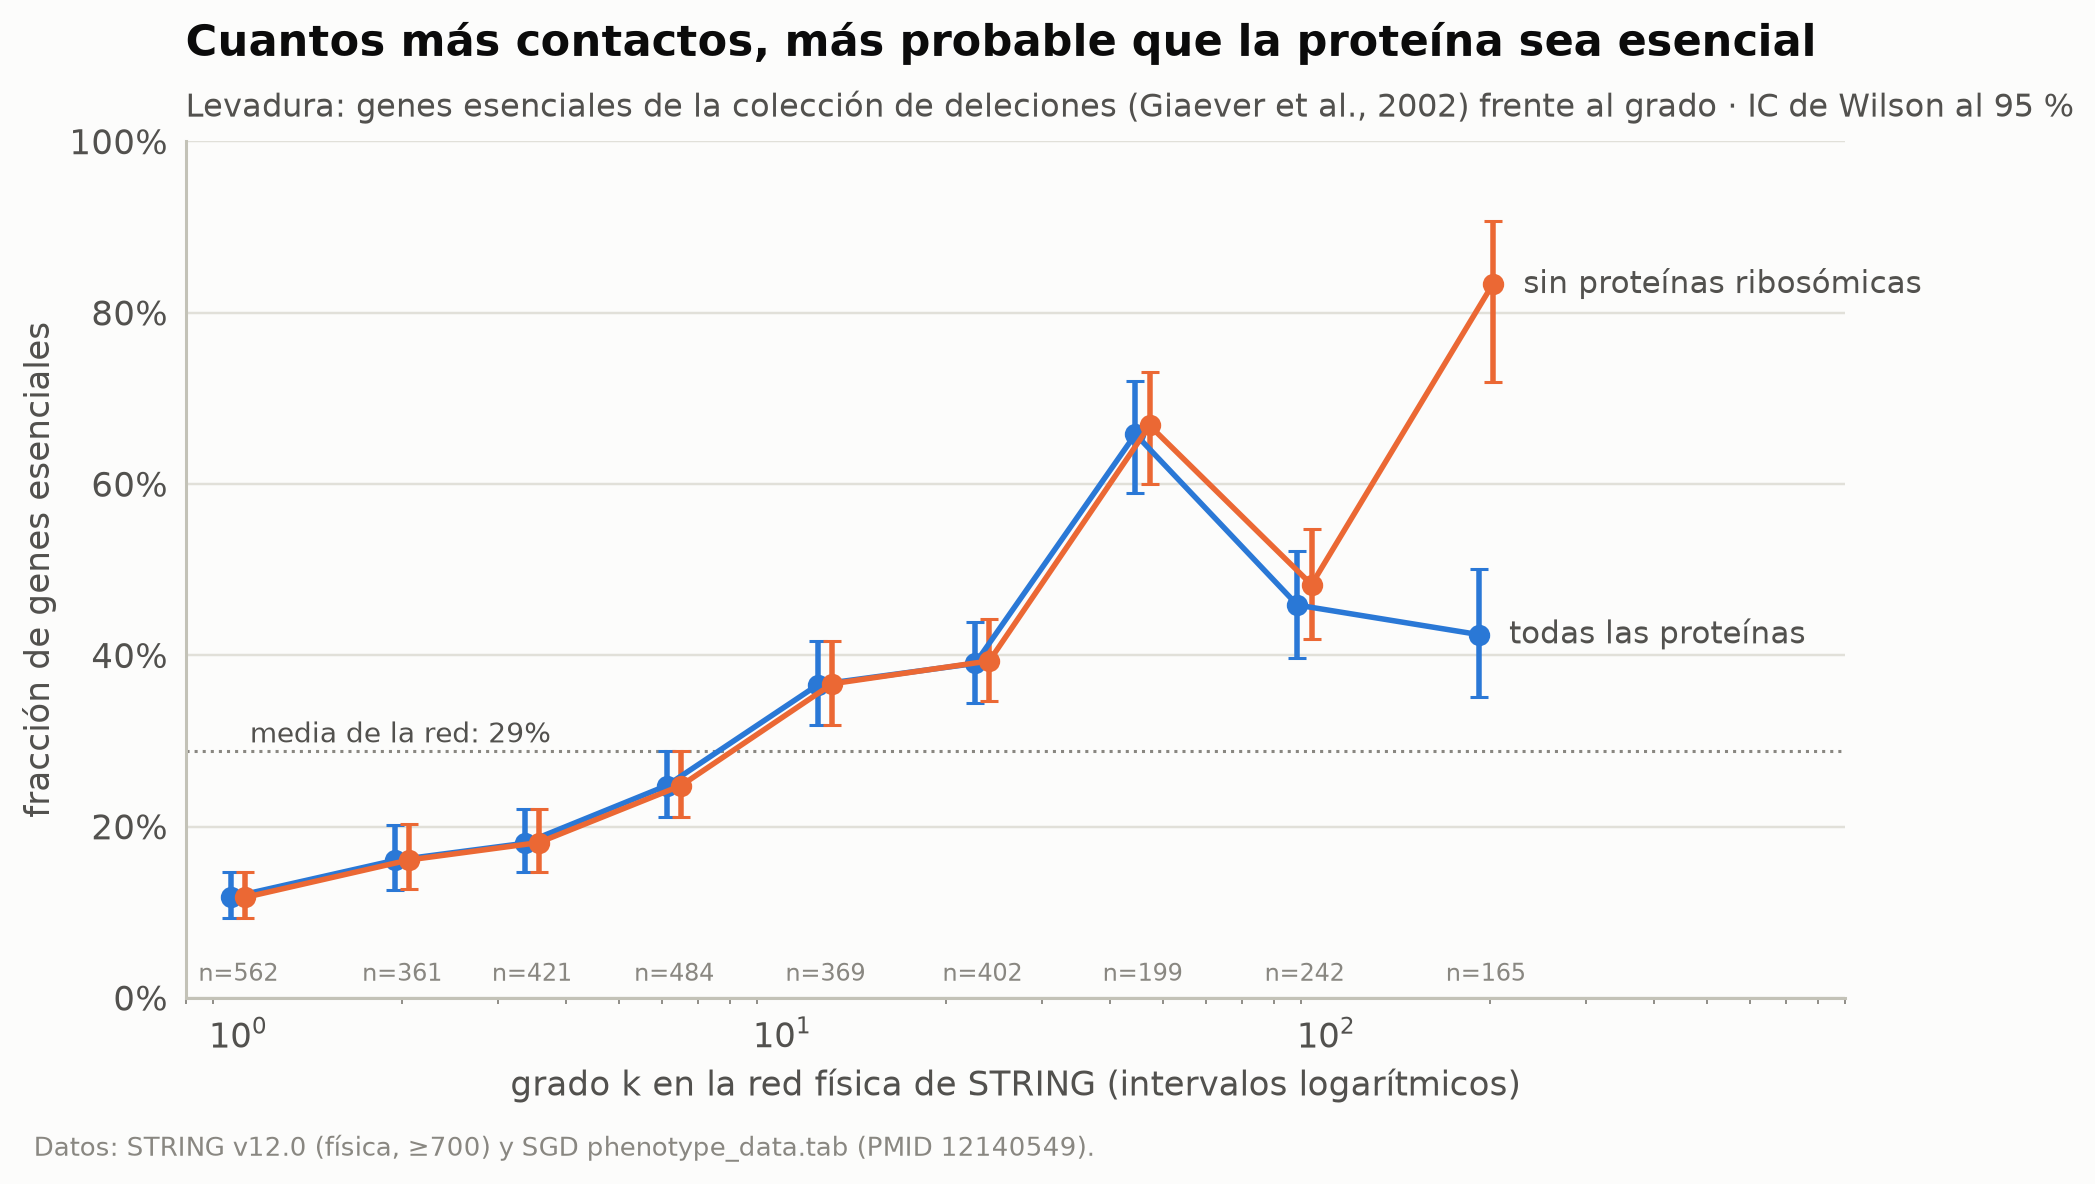

In [21]:
bins = [1, 2, 3, 5, 9, 17, 33, 65, 129, 300]
def frac_by_bin(df):
    g = df.groupby(pd.cut(df.k, bins, right=False), observed=True).essential
    out = pd.DataFrame({"f": g.mean(), "n": g.size()})
    z = 1.96; ph, nn = out.f, out.n                                   # intervalo de Wilson al 95 %
    cen = (ph + z ** 2 / (2 * nn)) / (1 + z ** 2 / nn)
    half = z * np.sqrt(ph * (1 - ph) / nn + z ** 2 / (4 * nn ** 2)) / (1 + z ** 2 / nn)
    out["lo"], out["hi"] = cen - half, cen + half
    out["kc"] = [math.sqrt(a * (b - 1)) if b - 1 > a else a for a, b in zip(bins[:-1], bins[1:])]
    return out

fa, fn = frac_by_bin(net), frac_by_bin(net[~net.ribosomal])
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.axhline(net.essential.mean(), color=ec.MUTED, lw=1, ls=":")
ax.text(1.05, net.essential.mean() + 0.01, f"media de la red: {net.essential.mean():.0%}", fontsize=9, color=ec.INK_2)
for df, col, lab, dx in ((fa, ec.BLUE, "todas las proteínas", 0.97), (fn, ec.ORANGE, "sin proteínas ribosómicas", 1.03)):
    ax.errorbar(df.kc * dx, df.f, yerr=[df.f - df.lo, df.hi - df.f], color=col, marker="o", ms=6, capsize=3, lw=1.8)
    ec.label_end(ax, df.kc.iloc[-1] * dx, df.f.iloc[-1], lab, dx=10)
for kc, f_, nn in zip(fa.kc, fa.f, fa.n):
    ax.text(kc, 0.02, f"n={nn}", ha="center", fontsize=8, color=ec.MUTED)
ax.set_xscale("log"); ax.set_xlim(0.8, 900); ax.set_ylim(0, 1)
ax.set_xlabel("grado k en la red física de STRING (intervalos logarítmicos)")
ax.set_ylabel("fracción de genes esenciales")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ec.title(ax, "Cuantos más contactos, más probable que la proteína sea esencial",
         "Levadura: genes esenciales de la colección de deleciones (Giaever et al., 2002) frente al grado · IC de Wilson al 95 %")
ec.source(fig, "Datos: STRING v12.0 (física, ≥700) y SGD phenotype_data.tab (PMID 12140549).")
plt.show()

> 🔎 **Qué observamos.** La fracción de esenciales sube de un 12 % en las proteínas con un único contacto a cerca de
> dos tercios con 33–64 contactos: el principio de Jeong se reproduce con datos actuales (AUC del grado ≈ 0,69). Pero
> el último intervalo del conjunto completo **cae** al 42 %: son las proteínas ribosómicas, y sólo el 16 % de ellas es
> esencial (20 de 127). ¿Por qué, si el ribosoma es imprescindible? Porque la levadura duplicó su genoma hace unos 100 millones de
> años y conserva **dos copias parálogas** (A y B) de la mayoría de los genes ribosómicos (RPS6A/RPS6B, RPL7A/RPL7B…):
> eliminar una sola copia rara vez es letal. Las cifras lo confirman: de las 98 proteínas ribosómicas cuya pareja A/B
> figura en la tabla de viabilidad sólo 4 son esenciales (4 %), frente a 16 de las 29 restantes (55 %), que en su
> mayoría son genes de copia única. Sin las ribosómicas (naranja), la curva sube hasta el 83 %.

Tres lecciones de nivel de maestría:

1. **Confusión por complejos.** Parte de la correlación grado-esencialidad se debe a que los complejos esenciales son
   grandes y el modelo matriz les regala aristas. La centralidad es, en parte, un reflejo de cómo se midió la red.
2. **Redundancia genética.** La esencialidad es una propiedad del **gen** en un genoma con parálogos, no sólo de la
   proteína en la red.
3. **Sesgo de estudio.** En la red, el 29 % de las proteínas anotadas son esenciales, frente al 19 % del genoma: las
   proteínas esenciales están mejor estudiadas y por eso tienen más interacciones conocidas. La red y la etiqueta no
   son independientes.

### 7.1 Medicina de redes

Barabási, Gulbahce y Loscalzo (2011) llevaron esta idea a la enfermedad humana: dada la interdependencia de los
componentes celulares, una enfermedad rara vez es la anomalía de un único gen; refleja la perturbación de una red.
Los genes asociados a una misma enfermedad tienden a agruparse en un **módulo de enfermedad**, lo que permite:

* **priorizar genes candidatos** de un estudio de asociación (Módulo 10) por su proximidad en la red a genes ya
  conocidos;
* **proponer dianas terapéuticas** y **reposicionar fármacos**: un fármaco cuyas dianas están cerca del módulo de una
  enfermedad es un candidato a tratarla; uno cuyas dianas son *hubs* muy esenciales es candidato a ser tóxico.

> ✅ **Compruebe su comprensión.** Un fármaco antifúngico ideal debería inhibir una proteína esencial de la levadura
> patógena. ¿Buscaría entre los *hubs* de la red física o entre proteínas de grado intermedio? ¿Qué problema tienen
> los *hubs* ribosómicos? *Respuesta:* los *hubs* se enriquecen en esenciales, pero los ribosómicos tienen parálogos
> (inhibir uno no basta) y son muy parecidos a los humanos (toxicidad). Un buen punto de partida son proteínas
> esenciales, sin parálogo y suficientemente distintas de su versión humana, como la lanosterol 14α-desmetilasa
> (ERG11) de la síntesis de ergosterol, diana de los azoles.

## 8. Módulos y comunidades

Una célula no es una sopa homogénea de interacciones: tiene complejos, vías y orgánulos. En el lenguaje de redes esto
se traduce en **comunidades**: grupos de nodos densamente conectados entre sí y escasamente conectados con el resto,
como los barrios de una ciudad unidos por unos pocos puentes. Girvan y Newman (2002) propusieron detectarlas
**eliminando progresivamente las aristas de mayor intermediación**, que son justamente esos puentes: al retirarlas, la
red se fragmenta en sus comunidades naturales. Faltaba un criterio para decidir cuándo detenerse, y ese criterio es la
**modularidad**.

### 8.1 La modularidad $Q$

Dada una partición de los nodos en comunidades $c_i$, su modularidad es la fracción de aristas **dentro** de las
comunidades menos la fracción **esperada** si las aristas se colocaran al azar respetando los grados:

$$
Q=\frac{1}{2m}\sum_{i,j}\left[A_{ij}-\frac{k_ik_j}{2m}\right]\delta(c_i,c_j)
=\sum_{c}\left[\frac{l_c}{m}-\left(\frac{d_c}{2m}\right)^{2}\right].
$$

| Símbolo | Significado |
|---|---|
| $k_ik_j/2m$ | número esperado de aristas entre $i$ y $j$ en el modelo nulo de configuración (mismos grados, aristas al azar) |
| $\delta(c_i,c_j)$ | vale 1 si $i$ y $j$ están en la misma comunidad, 0 si no |
| $l_c$ | número de aristas dentro de la comunidad $c$ |
| $d_c$ | suma de los grados de los nodos de $c$ |

**¿De dónde sale $k_ik_j/2m$?** Corte cada arista en dos «medias aristas» ($2m$ en total) y vuelva a emparejarlas al
azar. Cada una de las $k_i$ medias aristas de $i$ se empareja con alguna de las $k_j$ de $j$ con probabilidad
$k_j/(2m-1)\approx k_j/2m$. Para pasar de la primera forma a la segunda basta agrupar la suma por comunidades:
$\sum_{i,j\in c}A_{ij}=2l_c$ y $\sum_{i,j\in c}k_ik_j=d_c^2$.

**Ejemplo del libro: «Modularidad del grafo de juguete».** Con $m=8$, la partición $\{$A, B, C$\}\,|\,\{$D, E, F, G$\}$:
la primera comunidad tiene $l=3$ aristas y grado total $d=2+2+3=7$; la segunda, $l=4$ y $d=3+2+3+1=9$:

$$
Q=\left[\tfrac38-\left(\tfrac{7}{16}\right)^2\right]+\left[\tfrac48-\left(\tfrac{9}{16}\right)^2\right]=0{,}1836+0{,}1836=0{,}367.
$$

Si movemos D al primer grupo, $\{$A, B, C, D$\}\,|\,\{$E, F, G$\}$, la modularidad baja a $0{,}219$: la partición
natural corta la única arista puente, C–D.

In [22]:
def modularity_by_hand(g, part):
    """Q = Σ_c [ l_c/m − (d_c/2m)² ]  (segunda forma de la ecuación)."""
    mm = g.number_of_edges(); Q = 0
    for c in part:
        lc = g.subgraph(c).number_of_edges(); dc = sum(d for _, d in g.degree(c))
        term = lc / mm - (dc / (2 * mm)) ** 2
        print(f"   comunidad {''.join(sorted(c))}: l_c = {lc}, d_c = {dc}, término = {term:.4f}")
        Q += term
    return Q

def modularity_matrix_form(g, part, nodes):
    """Q = (1/2m) Σ_ij [A_ij − k_i k_j / 2m] δ(c_i, c_j)  (primera forma)."""
    Am = nx.to_numpy_array(g, nodelist=nodes); kv = Am.sum(1); mm = Am.sum() / 2
    lab_ = np.array([next(i for i, c in enumerate(part) if u in c) for u in nodes])
    B = Am - np.outer(kv, kv) / (2 * mm)
    return (B * (lab_[:, None] == lab_[None, :])).sum() / (2 * mm)

for part in ([{"A", "B", "C"}, {"D", "E", "F", "G"}], [{"A", "B", "C", "D"}, {"E", "F", "G"}]):
    q1 = modularity_by_hand(toy, part)
    print(f"Q = {q1:.4f} | forma matricial: {modularity_matrix_form(toy, part, order):.4f} | "
          f"NetworkX: {nx.community.modularity(toy, part):.4f}\n")

   comunidad ABC: l_c = 3, d_c = 7, término = 0.1836
   comunidad DEFG: l_c = 4, d_c = 9, término = 0.1836
Q = 0.3672 | forma matricial: 0.3672 | NetworkX: 0.3672

   comunidad ABCD: l_c = 4, d_c = 10, término = 0.1094
   comunidad EFG: l_c = 2, d_c = 6, término = 0.1094
Q = 0.2188 | forma matricial: 0.2188 | NetworkX: 0.2188



¿Es $\{$A, B, C$\}\,|\,\{$D, E, F, G$\}$ la **mejor** partición en dos grupos? Con 7 nodos sólo hay $2^6-1=63$
biparticiones distintas: podemos probarlas todas. (Con 36 nodos habría unos 34 000 millones; con 3 384, más que
átomos en el universo: por eso existen los algoritmos heurísticos.)

biparticiones evaluadas: 63
       Q        p
0.367188 ABC|DEFG
0.250000 DEF|ABCG
0.218750 EFG|ABCD
0.125000 FG|ABCDE

autovector principal de B: {'A': np.float64(-0.455), 'B': np.float64(-0.455), 'C': np.float64(-0.375), 'D': np.float64(0.231), 'E': np.float64(0.365), 'F': np.float64(0.448), 'G': np.float64(0.241)}
signo → grupos: ['A', 'B', 'C'] | ['D', 'E', 'F', 'G']


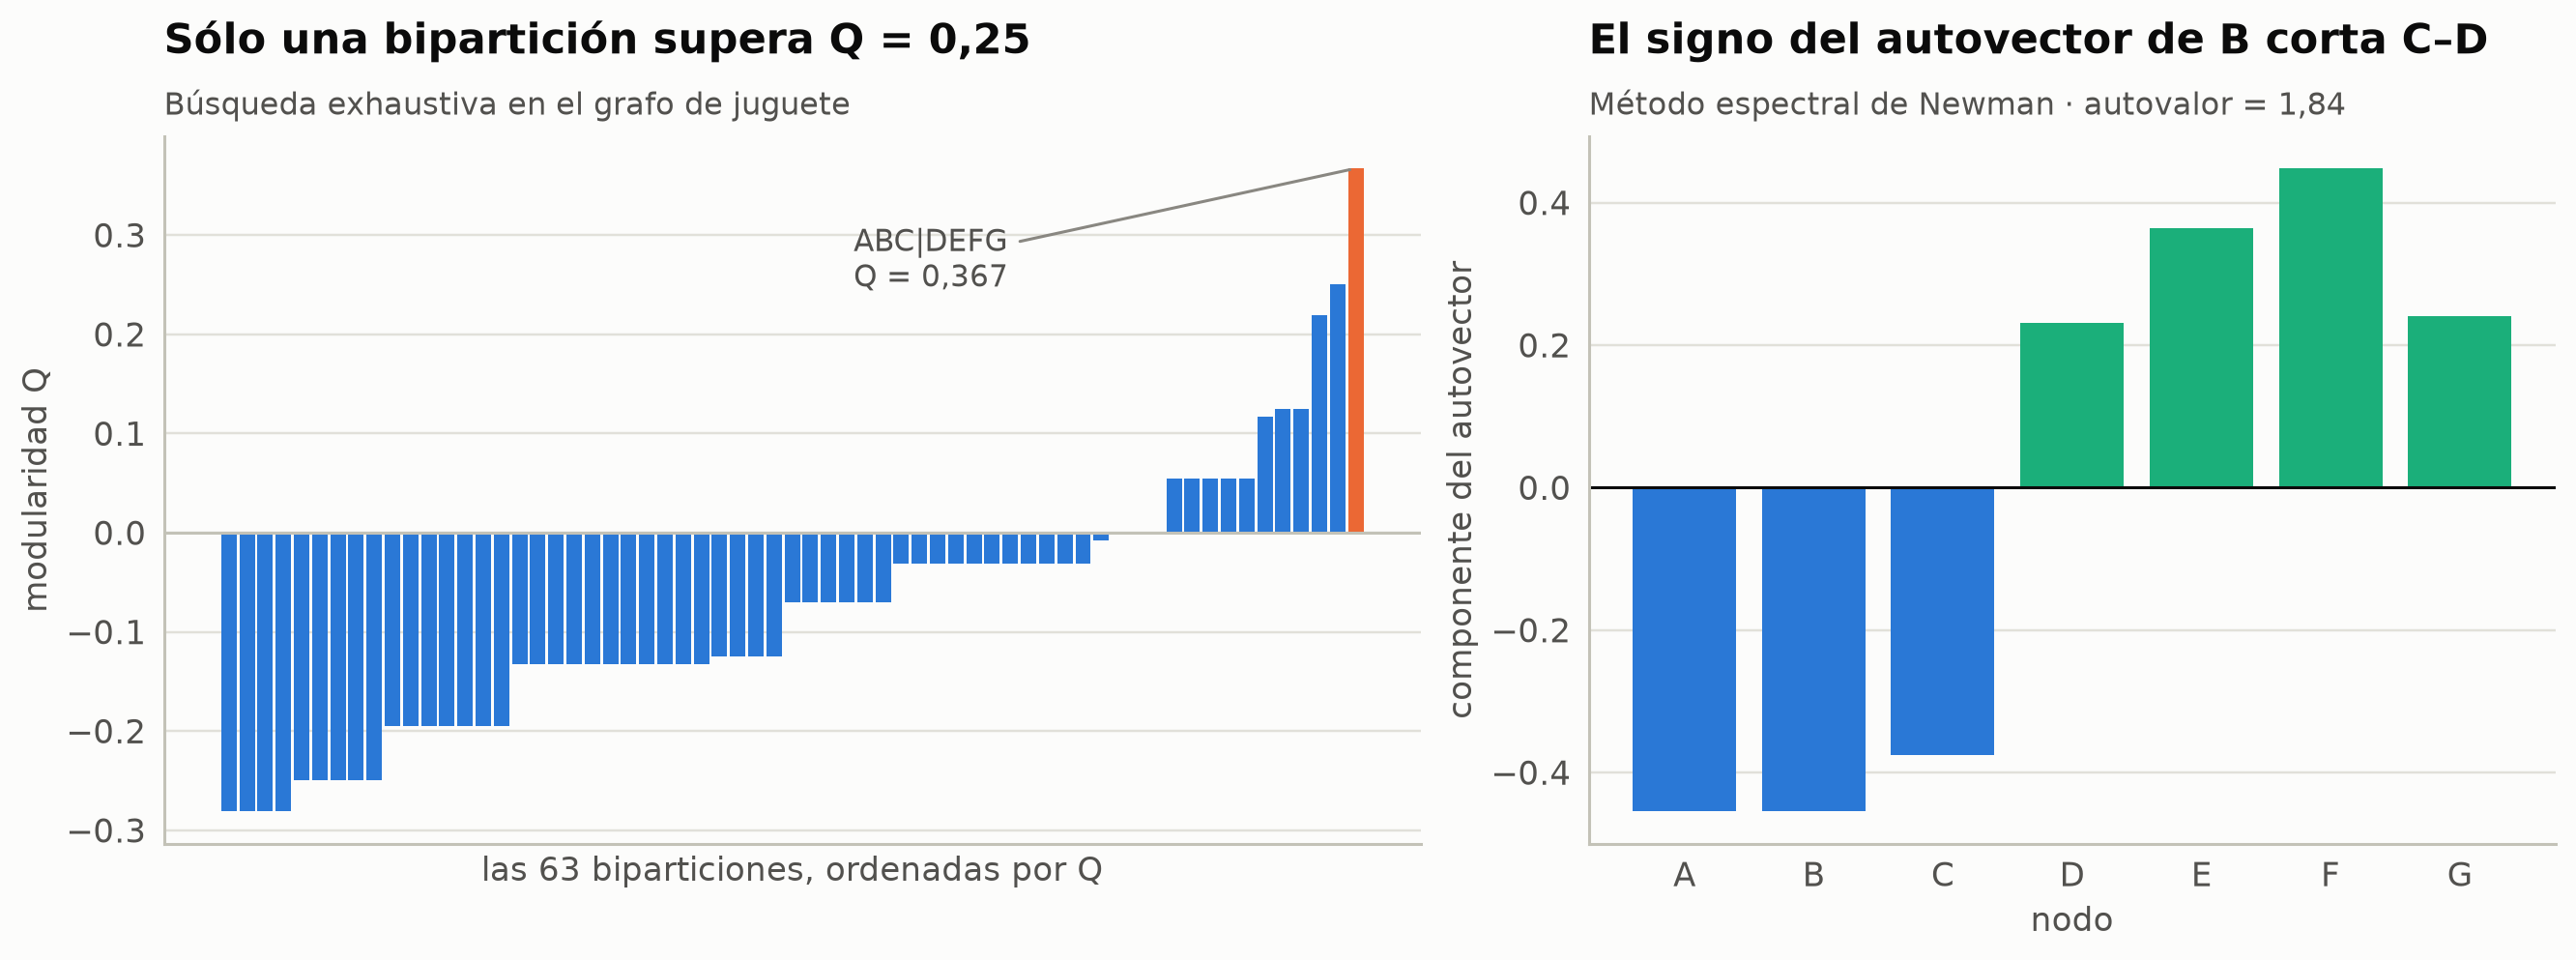

In [23]:
biparts = []
for r in range(1, 4):                                  # con 7 nodos, los subconjuntos de 1–3 nodos dan cada bipartición una vez
    for S in itertools.combinations(order, r):
        part = [set(S), set(order) - set(S)]
        biparts.append((nx.community.modularity(toy, part), "".join(sorted(S)) + "|" + "".join(sorted(part[1]))))
Q_all = pd.DataFrame(biparts, columns=["Q", "p"])
print(f"biparticiones evaluadas: {len(Q_all)}")
print(Q_all.sort_values("Q", ascending=False).head(4).to_string(index=False))

# El método espectral de Newman (2006): el signo del autovector principal de B = A − kkᵀ/2m
Am = nx.to_numpy_array(toy, nodelist=order); kv = Am.sum(1)
Bm = Am - np.outer(kv, kv) / (2 * m_t)
w_, v_ = np.linalg.eigh(Bm)
lead = v_[:, -1] * np.sign(v_[order.index("G"), -1])
print("\nautovector principal de B:", dict(zip(order, lead.round(3))))
print("signo → grupos:", [u for u, x in zip(order, lead) if x < 0], "|", [u for u, x in zip(order, lead) if x > 0])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw=dict(width_ratios=[1.3, 1]))
qs_sorted = Q_all.sort_values("Q").reset_index(drop=True)
cols = [ec.ORANGE if q == qs_sorted.Q.max() else ec.BLUE for q in qs_sorted.Q]
ax.bar(range(len(qs_sorted)), qs_sorted.Q, color=cols, width=0.85)
ax.axhline(0, color=ec.BASELINE, lw=1)
best = qs_sorted.iloc[-1]
ax.annotate(f"{best.p}\nQ = {fmt(best.Q, 3)}", (len(qs_sorted) - 1, best.Q), xytext=(-170, -40),
            textcoords="offset points", fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax.set_xlabel("las 63 biparticiones, ordenadas por Q"); ax.set_ylabel("modularidad Q"); ax.set_xticks([])
ec.title(ax, "Sólo una bipartición supera Q = 0,25", "Búsqueda exhaustiva en el grafo de juguete")
ax2.bar(order, lead, color=[ec.BLUE if x < 0 else ec.AQUA for x in lead])
ax2.axhline(0, color=ec.INK, lw=1)
ax2.set_ylabel("componente del autovector"); ax2.set_xlabel("nodo")
ec.title(ax2, "El signo del autovector de B corta C–D", f"Método espectral de Newman · autovalor = {fmt(w_[-1], 2)}")
plt.show()

> 🔎 **Qué observamos.** La búsqueda exhaustiva confirma que $\{$A, B, C$\}\,|\,\{$D, E, F, G$\}$ es la bipartición
> óptima ($Q=0{,}367$), seguida de lejos por $\{$A, B, C, G$\}\,|\,\{$D, E, F$\}$ ($0{,}25$). Muchas biparticiones tienen
> $Q<0$: separan nodos muy conectados y quedan **peor que el azar**. Newman (2006) mostró que $Q$ se escribe con los
> autovectores de la **matriz de modularidad** $B_{ij}=A_{ij}-k_ik_j/2m$: el signo de las componentes del autovector
> principal da una buena bipartición, y aquí da exactamente la óptima. Hoy el método más usado es el de **Louvain**
> (Blondel *et al.*, 2008): mueve cada nodo a la comunidad vecina que más aumenta $Q$ y después agrega cada comunidad
> en un supernodo, repitiendo hasta converger (lo programamos desde cero en la lección 12.3).

### 8.2 Una red real: la vecindad de FUS3

Volvamos a la vía de la feromona. Extraemos la **ego-red** de FUS3 de radio 2: todas las proteínas a distancia $\le2$
de FUS3 en la red física de levadura, con todas las aristas entre ellas.

> ⚠️ **Un detalle técnico que importa.** El Louvain de NetworkX recorre **conjuntos** de nodos, y en Python el orden de
> un conjunto de cadenas depende de una semilla de *hash* que cambia en cada sesión (`PYTHONHASHSEED`). El libro la fija
> a 0; en Colab no podemos hacerlo desde el notebook. Para que el resultado sea **reproducible en cualquier máquina**,
> renombramos las proteínas a enteros (orden alfabético), cuyo *hash* es fijo, y usamos `seed=1`: así se obtiene
> exactamente la partición del libro.

In [24]:
E = nx.ego_graph(G, "FUS3", radius=2)
names = sorted(E); idx = {u: i for i, u in enumerate(names)}
H = nx.Graph(); H.add_nodes_from(range(len(names)))
H.add_edges_from(sorted((min(idx[u], idx[v]), max(idx[u], idx[v])) for u, v in E.edges()))
comms = sorted(({names[i] for i in c} for c in nx.community.louvain_communities(H, seed=1)), key=len, reverse=True)
Q_fus3 = nx.community.modularity(E, comms)
print(f"ego-red de FUS3: n = {E.number_of_nodes()}, m = {E.number_of_edges()} · Louvain: "
      f"{[len(c) for c in comms]} comunidades, Q = {Q_fus3:.3f}")
COM_NAMES = ["vía proximal: Gβγ, STE5, CDC42", "cascada MAPK: FUS3, STE7, STE12", "importación mitocondrial (TIM)",
             "vía HOG (osmolaridad)", "ciclo celular: CDC28, FAR1"]
COM_COLS = [ec.BLUE, ec.ORANGE, ec.AQUA, ec.VIOLET, ec.MAGENTA]
for i, c in enumerate(comms):
    print(f"  {i} ({COM_NAMES[i]}): {sorted(c)}")
btw = nx.betweenness_centrality(E)
print("mayor intermediación:", [(u, round(b, 3)) for u, b in sorted(btw.items(), key=lambda x: -x[1])[:5]])
print("mayor grado:", sorted(E.degree(), key=lambda x: -x[1])[:5])

ego-red de FUS3: n = 36, m = 78 · Louvain: [11, 8, 7, 6, 4] comunidades, Q = 0.572
  0 (vía proximal: Gβγ, STE5, CDC42): ['BEM1', 'CDC24', 'CDC42', 'GDI1', 'SHO1', 'STE11', 'STE18', 'STE20', 'STE4', 'STE5', 'STE50']
  1 (cascada MAPK: FUS3, STE7, STE12): ['DIG1', 'DIG2', 'FUS3', 'KSS1', 'MSG5', 'PIN3', 'STE12', 'STE7']
  2 (importación mitocondrial (TIM)): ['SDH3', 'TIM10', 'TIM12', 'TIM18', 'TIM22', 'TIM54', 'TIM9']
  3 (vía HOG (osmolaridad)): ['HOG1', 'PBS2', 'PTP2', 'PTP3', 'SSK2', 'SSK22']
  4 (ciclo celular: CDC28, FAR1): ['CDC28', 'CLB5', 'CLN2', 'FAR1']
mayor intermediación: [('FUS3', 0.632), ('TIM12', 0.292), ('STE11', 0.227), ('FAR1', 0.217), ('PBS2', 0.157)]
mayor grado: [('FUS3', 10), ('STE11', 10), ('TIM12', 7), ('FAR1', 7), ('CDC42', 6)]


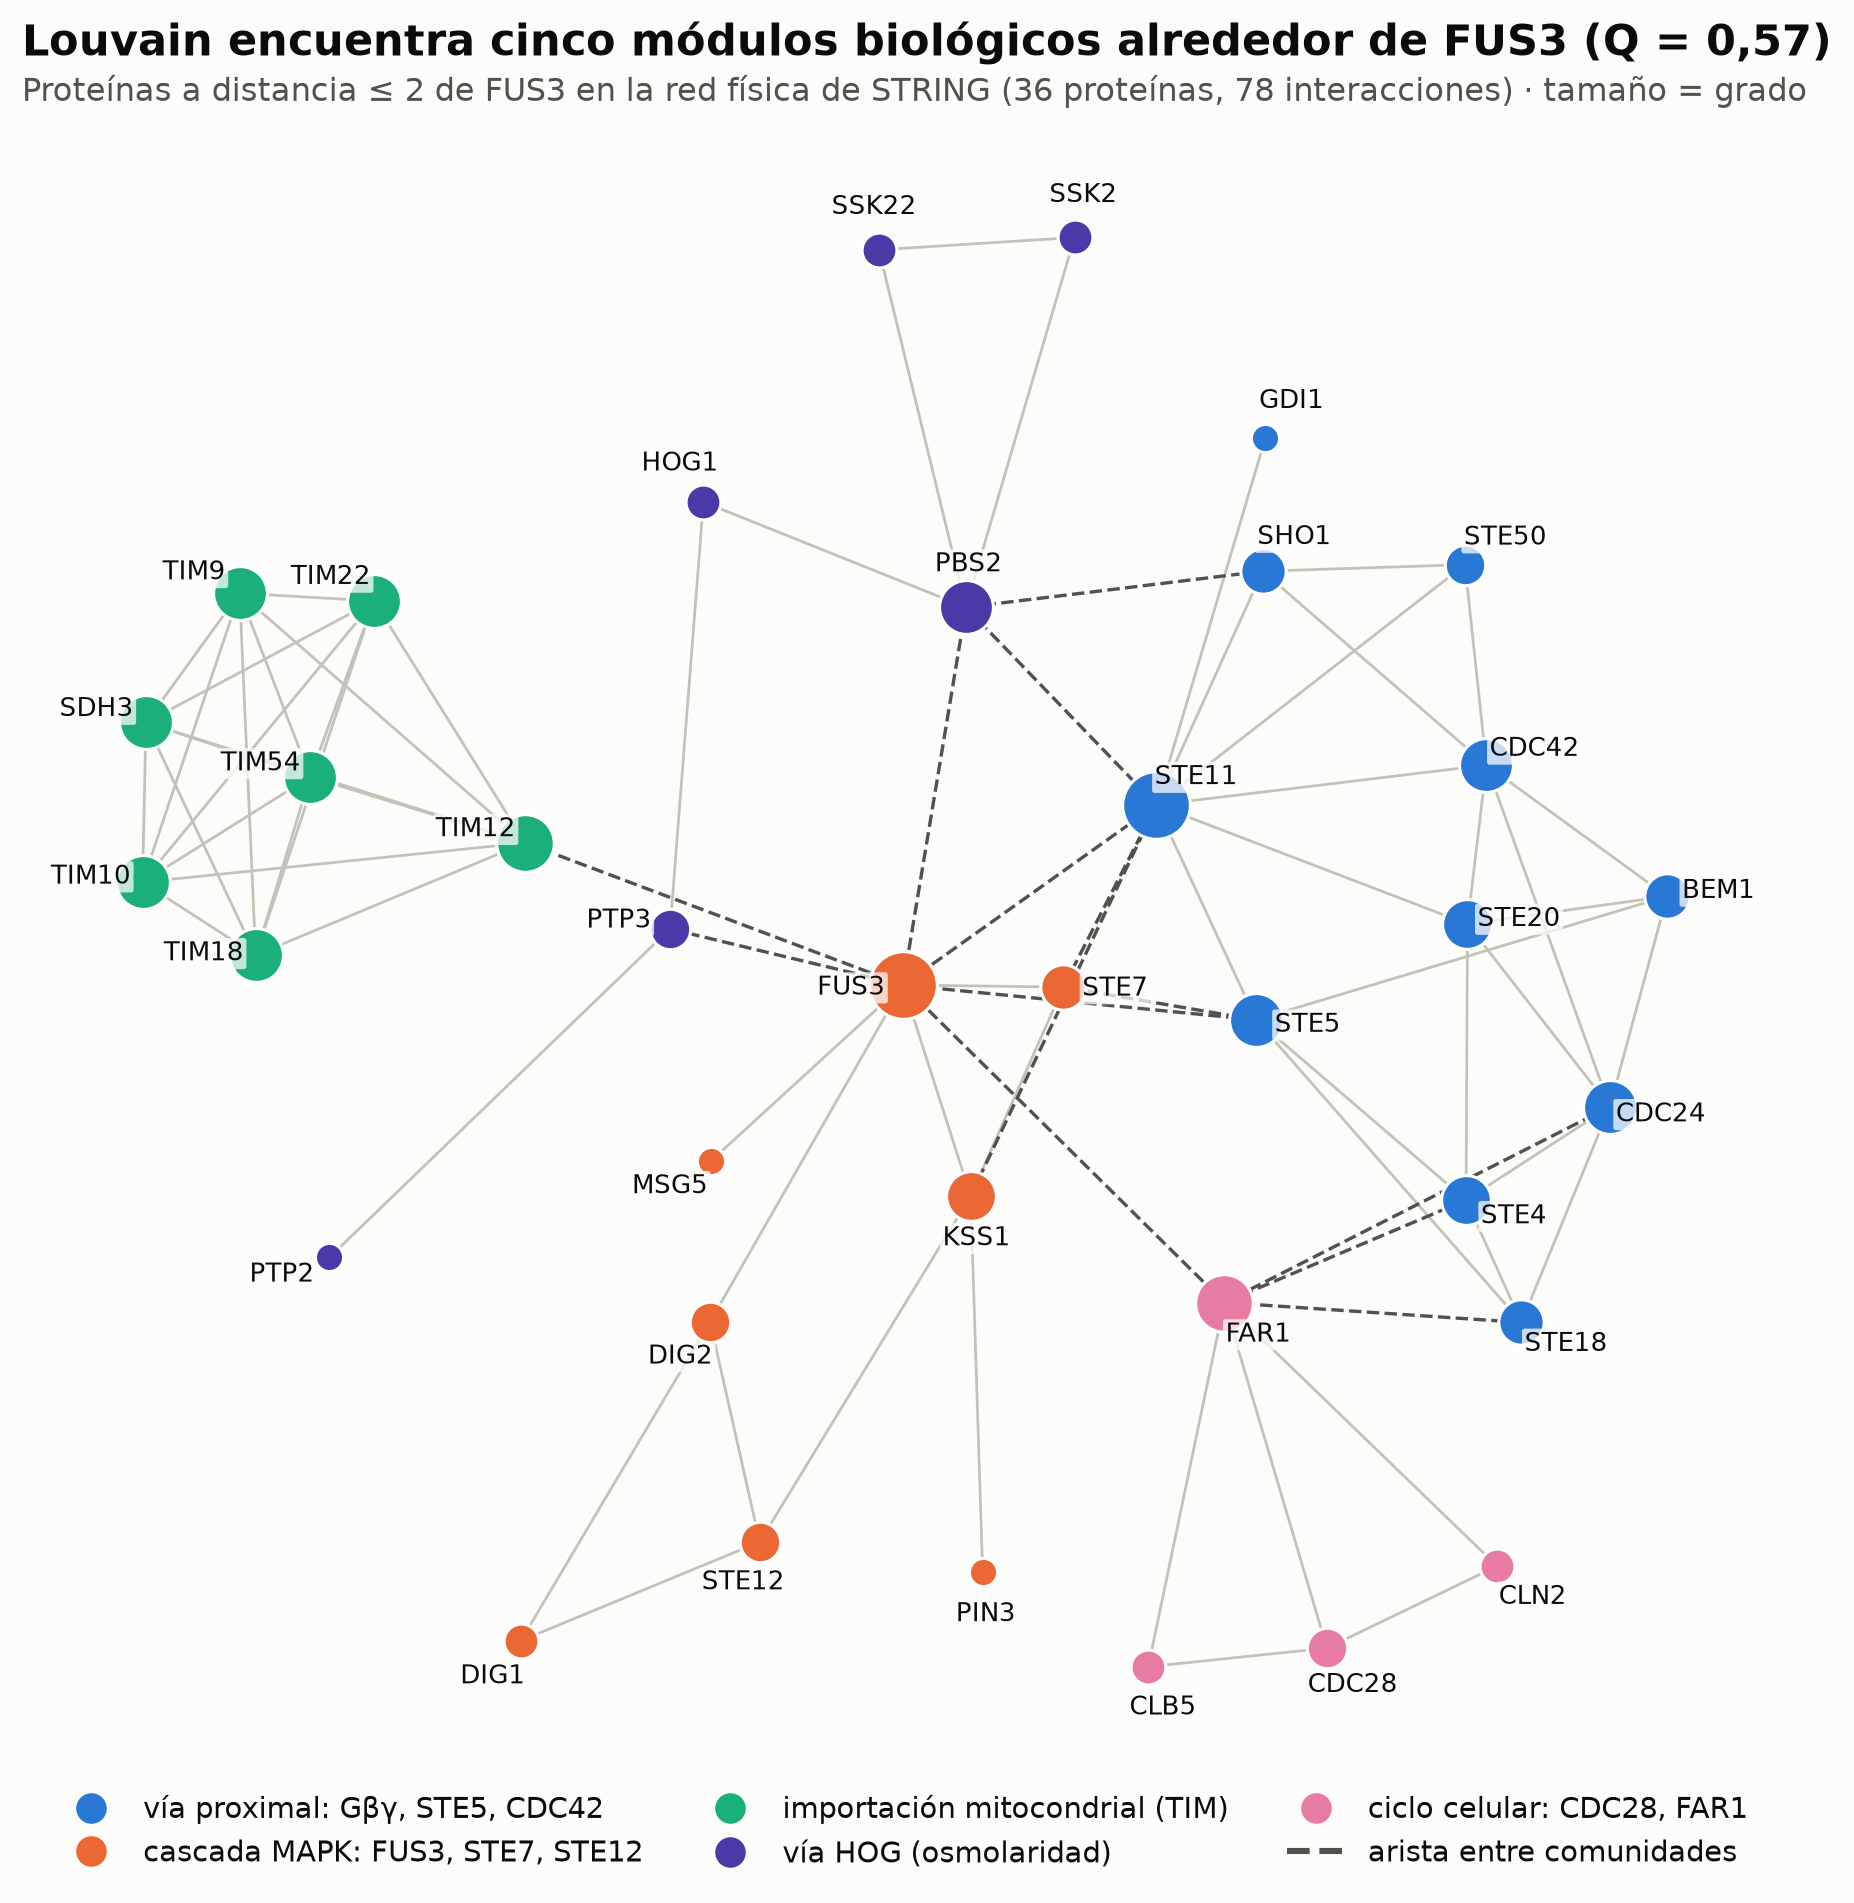

In [25]:
cid = {u: i for i, c in enumerate(comms) for u in c}
pos_f = nx.kamada_kawai_layout(E)
XY_F = np.array([pos_f[u] for u in E]); dE = dict(E.degree())
fig, ax = plt.subplots(figsize=(11, 8))
same = [(u, v) for u, v in E.edges() if cid[u] == cid[v]]
cross = [(u, v) for u, v in E.edges() if cid[u] != cid[v]]
ax.add_collection(LineCollection([np.array([pos_f[u], pos_f[v]]) for u, v in same], colors=ec.BASELINE, lw=0.9))
ax.add_collection(LineCollection([np.array([pos_f[u], pos_f[v]]) for u, v in cross], colors=ec.INK_2, lw=1.1,
                                 linestyles="--"))
for u in E:
    ax.scatter(*pos_f[u], s=40 + 45 * dE[u], color=COM_COLS[cid[u]], edgecolor="white", lw=1, zorder=3)
cen = XY_F.mean(0)
for u in E:
    d_ = np.array(pos_f[u]) - cen; d_ = d_ / (np.linalg.norm(d_) + 1e-9)
    ax.annotate(u, pos_f[u], xytext=(d_[0] * 17, d_[1] * 14), textcoords="offset points", fontsize=8.5,
                ha="center", va="center", color=ec.INK, zorder=4,
                bbox=dict(boxstyle="round,pad=0.1", fc=ec.SURFACE, ec="none", alpha=0.75))
ax.set_aspect("equal"); ax.axis("off")
ax.set_xlim(XY_F[:, 0].min() - 0.15, XY_F[:, 0].max() + 0.15); ax.set_ylim(XY_F[:, 1].min() - 0.12, XY_F[:, 1].max() + 0.12)
handles = [Line2D([], [], marker="o", ls="", color=c, ms=9, label=nm) for c, nm in zip(COM_COLS, COM_NAMES)]
handles.append(Line2D([], [], color=ec.INK_2, ls="--", label="arista entre comunidades"))
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.07), fontsize=9.5)
ec.title(ax, f"Louvain encuentra cinco módulos biológicos alrededor de FUS3 (Q = {fmt(Q_fus3, 2)})",
         f"Proteínas a distancia ≤ 2 de FUS3 en la red física de STRING ({E.number_of_nodes()} proteínas, "
         f"{E.number_of_edges()} interacciones) · tamaño = grado")
plt.show()

> 🔎 **Qué observamos.** Reproducimos el libro: 36 proteínas, 78 interacciones y cinco comunidades de Louvain con
> $Q=0{,}57$, que coinciden con módulos biológicos reconocibles: el núcleo de la cascada MAP quinasa (FUS3, STE7, KSS1,
> STE12 y sus inhibidores DIG1 y DIG2), la parte proximal de la vía (STE4–STE18, el andamio STE5, STE20, CDC42), la vía
> de alta osmolaridad (HOG1, PBS2, SSK2, SSK22) y el control del ciclo (CDC28, CLN2, CLB5, FAR1). FUS3 tiene la mayor
> intermediación (0,63) porque conecta varios de estos módulos. El módulo verde de proteínas mitocondriales TIM entra
> por una única arista, FUS3–TIM12: la arista que en la sección 4 vimos apoyada **sólo** en el canal experimental. Una red
> extraída por vecindad hereda cualquier interacción dudosa de su semilla.

### 8.3 Girvan-Newman en acción

La animación aplica el algoritmo de Girvan y Newman a esta red: en cada cuadro se recalcula la intermediación de las
**aristas** y se elimina la mayor. Observe qué aristas caen primero y cómo evoluciona $Q$.

![Vista previa: algoritmo de Girvan-Newman sobre la vecindad de FUS3. Se elimina en cada paso la arista de mayor intermediación (roja); los colores son las componentes conexas y la curva, la modularidad Q.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.1_girvan_newman.gif)

*Vista previa: algoritmo de Girvan-Newman sobre la vecindad de FUS3. Se elimina en cada paso la arista de mayor intermediación (roja); los colores son las componentes conexas y la curva, la modularidad Q.*

In [26]:
g_gn = nx.Graph(E); removed, q_hist, parts_hist = [], [], []
n_steps = 45
for step in range(n_steps + 1):
    comps = [set(c) for c in nx.connected_components(g_gn)]
    q_hist.append(nx.community.modularity(E, comps)); parts_hist.append(comps)
    if step == n_steps:
        break
    eb = nx.edge_betweenness_centrality(g_gn)
    e_max = max(sorted(eb), key=eb.get)                 # desempate determinista
    removed.append(e_max); g_gn.remove_edge(*e_max)
best_step = int(np.argmax(q_hist))
print(f"mejor Q de Girvan-Newman = {max(q_hist):.3f} con {len(parts_hist[best_step])} comunidades "
      f"tras quitar {best_step} aristas; primeras aristas eliminadas: {removed[:4]}")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5.6), gridspec_kw=dict(width_ratios=[1.45, 1]), layout="none")
fig.subplots_adjust(left=0.01, right=0.97, bottom=0.11, top=0.82, wspace=0.12)
ttl = fig.text(0.02, 0.96, "", fontsize=14, fontweight="bold", va="top")
sub = fig.text(0.02, 0.90, "", fontsize=10.5, color=ec.INK_2, va="top")
PAL = ec.CATEGORICAL + ["#6aa6e6", "#f3a07a", "#79d1b0", "#f5c95c", "#b09adf", "#9e9c95"] * 3
frames_gn = list(range(n_steps)) + [best_step] * 8

def update(f):
    step = frames_gn[f]
    comps = parts_hist[step]
    big = sorted(comps, key=len, reverse=True)
    col_of = {u: PAL[i] if len(c) > 1 else ec.MUTED for i, c in enumerate(big) for u in c}
    gone = set(removed[:step])
    ax.clear(); ax.axis("off"); ax.set_aspect("equal")
    alive = [(u, v) for u, v in E.edges() if (u, v) not in gone and (v, u) not in gone]
    ax.add_collection(LineCollection([np.array([pos_f[u], pos_f[v]]) for u, v in alive], colors=ec.BASELINE, lw=1))
    if f < n_steps:
        u, v = removed[step]
        ax.plot(*zip(pos_f[u], pos_f[v]), color=ec.RED, lw=3.5, zorder=2)
    ax.scatter(XY_F[:, 0], XY_F[:, 1], s=[40 + 30 * dE[u] for u in E], c=[col_of[u] for u in E],
               edgecolor="white", lw=0.8, zorder=3)
    for u in ("FUS3", "STE5", "HOG1", "TIM12", "CDC28", "FAR1", "STE11"):
        ax.annotate(u, pos_f[u], xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5, color=ec.INK)
    ax.set_xlim(XY_F[:, 0].min() - 0.1, XY_F[:, 0].max() + 0.1); ax.set_ylim(XY_F[:, 1].min() - 0.1, XY_F[:, 1].max() + 0.1)
    ax2.clear()
    ax2.plot(range(len(q_hist)), q_hist, color=ec.BASELINE, lw=1.2)
    ax2.plot(range(step + 1), q_hist[:step + 1], color=ec.BLUE, lw=2)
    ax2.scatter([step], [q_hist[step]], color=ec.BLUE, s=40, zorder=3)
    ax2.axvline(best_step, color=ec.ORANGE, lw=1, ls="--")
    ax2.text(best_step + 0.8, 0.05, "máximo de Q", color=ec.ORANGE, fontsize=9)
    ax2.set_xlim(0, n_steps); ax2.set_ylim(0, 0.65); ax2.set_xlabel("aristas eliminadas")
    ax2.set_title("modularidad Q de las componentes", fontsize=11, loc="left")
    if f < n_steps:
        ttl.set_text(f"Paso {step + 1}: se elimina {removed[step][0]}–{removed[step][1]}")
    else:
        ttl.set_text(f"Mejor corte: {len(comps)} comunidades tras {best_step} eliminaciones")
    sub.set_text(f"{len([c for c in comps if len(c) > 1])} componentes con más de un nodo · Q = {fmt(q_hist[step], 3)}")
    return []

with plt.rc_context({"figure.constrained_layout.use": False}):   # conserva el diseño manual al guardar
    anim_html = ec.animate(fig, update, frames=len(frames_gn), interval=260, name="16.1_girvan_newman")
anim_html

mejor Q de Girvan-Newman = 0.562 con 5 comunidades tras quitar 14 aristas; primeras aristas eliminadas: [('TIM12', 'FUS3'), ('FUS3', 'FAR1'), ('STE5', 'FUS3'), ('FUS3', 'STE11')]


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las primeras aristas en caer son los puentes entre módulos (FUS3–TIM12 separa enseguida a las
> proteínas mitocondriales). $Q$ sube a medida que se cortan puentes, alcanza su máximo ($0{,}562$ con cinco
> comunidades, como en el libro) y después **baja**: el algoritmo empieza a romper módulos genuinos. Girvan-Newman
> encuentra casi la misma modularidad que Louvain ($0{,}572$), pero cuesta $O(m^2n)$ y es inviable en la red
> completa; Louvain es casi lineal.

### 8.4 ¿Es alto $Q=0{,}57$? Un modelo nulo

Cualquier red, incluso aleatoria, tiene alguna partición con $Q>0$: Louvain siempre encuentra *algo*. Para saber si
$0{,}57$ es notable, repetimos el análisis en 20 versiones **aleatorizadas** de la misma red que conservan el grado de
cada nodo (intercambio doble de aristas: A–B y C–D pasan a ser A–D y C–B).

Q en 20 aleatorizaciones: 0.354 ± 0.019   (libro: 0,361 ± 0,020)
Q observada = 0.572 → z = 11.4


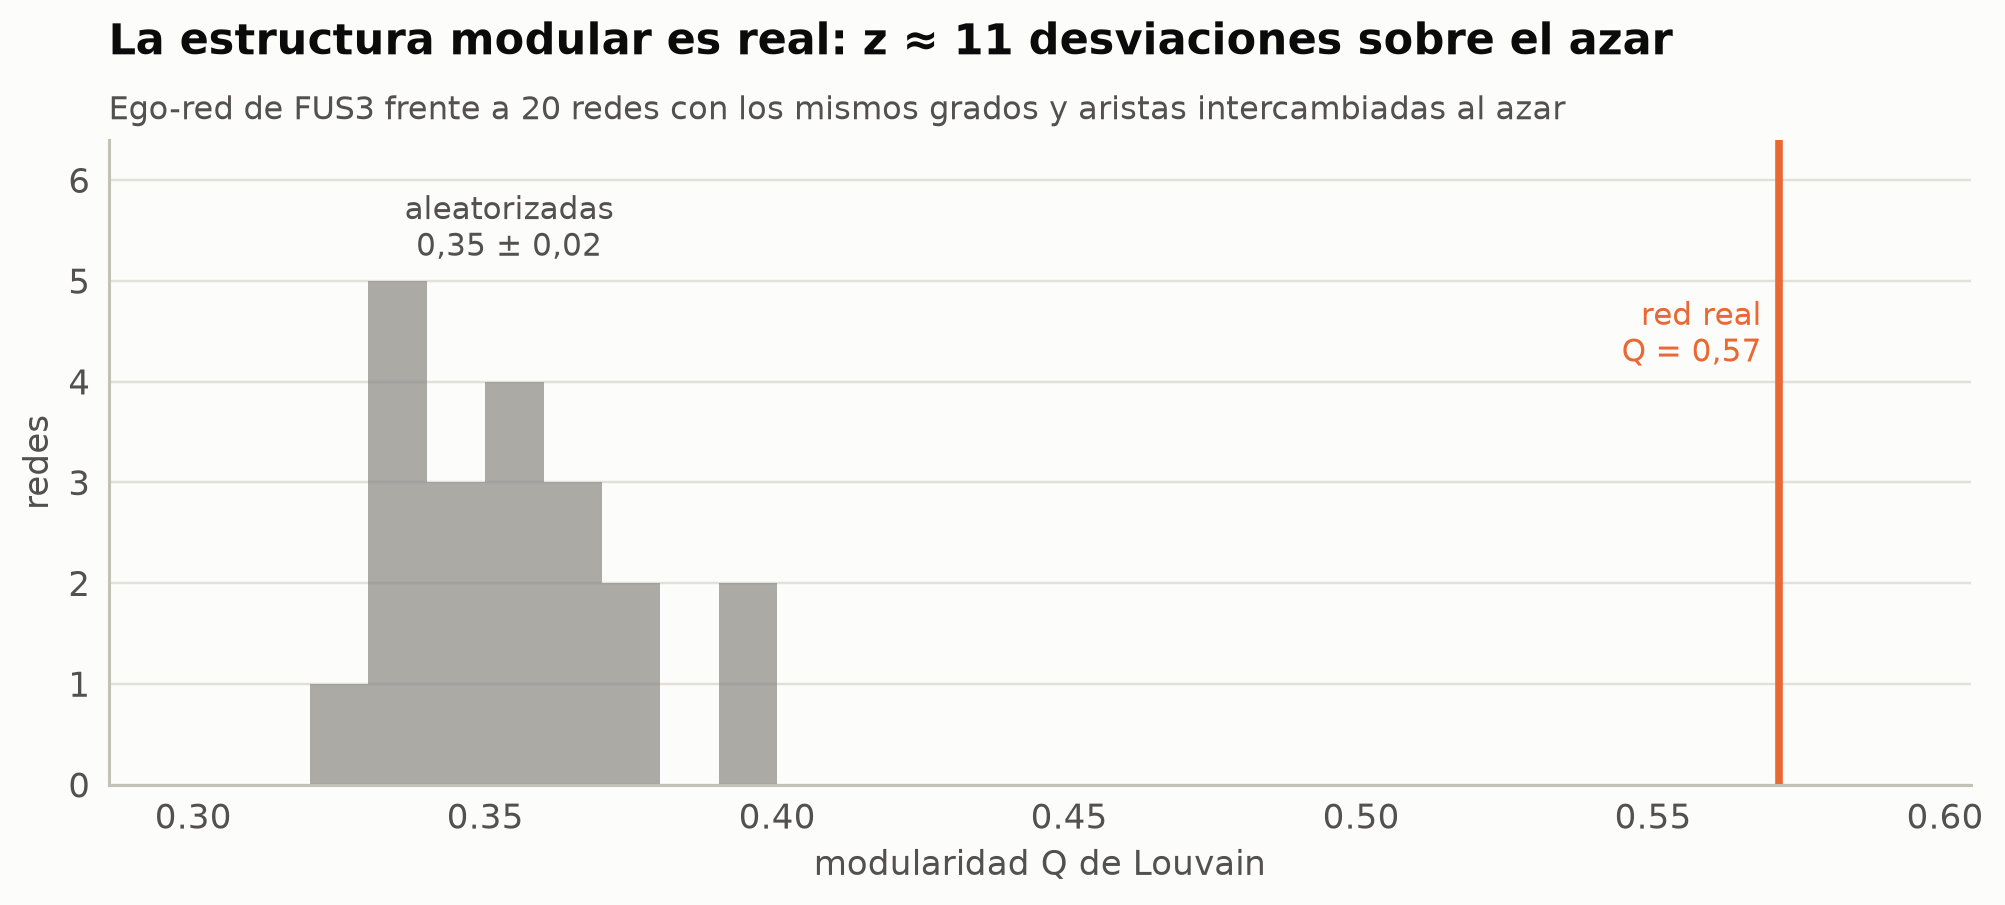

In [27]:
qs_null = []
for r in range(20):
    R = nx.double_edge_swap(nx.Graph(H), nswap=4 * H.number_of_edges(), max_tries=10 ** 5, seed=r)
    qs_null.append(nx.community.modularity(R, nx.community.louvain_communities(R, seed=1)))
qs_null = np.array(qs_null)
zQ = (Q_fus3 - qs_null.mean()) / qs_null.std()
print(f"Q en 20 aleatorizaciones: {qs_null.mean():.3f} ± {qs_null.std():.3f}   (libro: 0,361 ± 0,020)")
print(f"Q observada = {Q_fus3:.3f} → z = {zQ:.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(qs_null, bins=np.arange(0.30, 0.60, 0.01), color=ec.MUTED, alpha=0.7)
ax.axvline(Q_fus3, color=ec.ORANGE, lw=2.5)
ax.text(Q_fus3 - 0.003, 4.2, f"red real\nQ = {fmt(Q_fus3, 2)}", ha="right", color=ec.ORANGE, fontsize=10)
ax.text(qs_null.mean(), 5.25, f"aleatorizadas\n{fmt(qs_null.mean(), 2)} ± {fmt(qs_null.std(), 2)}", ha="center",
        color=ec.INK_2, fontsize=10)
ax.set_ylim(0, 6.4); ax.set_xlabel("modularidad Q de Louvain"); ax.set_ylabel("redes")
ec.title(ax, f"La estructura modular es real: z ≈ {zQ:.0f} desviaciones sobre el azar",
         "Ego-red de FUS3 frente a 20 redes con los mismos grados y aristas intercambiadas al azar")
plt.show()

> 🔎 **Qué observamos.** Las redes aleatorizadas dan $Q\approx0{,}35\pm0{,}02$ (el libro, con otra semilla de *hash*,
> obtuvo $0{,}36\pm0{,}02$: la diferencia es el ruido de Louvain en redes sin estructura). La red real está a más de
> diez desviaciones típicas: la estructura modular no es un artefacto del algoritmo.

### 8.5 ¿Qué hace cada módulo? Enriquecimiento funcional

Que un grupo sea denso no dice qué hace. La prueba estándar es el **enriquecimiento funcional**: ¿hay en la comunidad
más proteínas de un término de Gene Ontology o de una vía KEGG de las esperables por azar? Si el genoma (fondo) tiene
$N$ proteínas, $K$ de ellas anotadas con el término, y la comunidad tiene $n_c$ proteínas de las que $x$ lo están, la
probabilidad de ver $x$ o más por azar es la cola de la **hipergeométrica** (la prueba exacta de Fisher de una cola):

$$
\Pr(X\ge x)=\sum_{j=x}^{\min(n_c,K)}\frac{\binom{K}{j}\binom{N-K}{n_c-j}}{\binom{N}{n_c}} ,
$$

y como se prueban miles de términos, se corrige por comparaciones múltiples (FDR de Benjamini-Hochberg, Módulo 10).

| Símbolo | Significado |
|---|---|
| $N$ | proteínas del fondo (el genoma anotado) |
| $K$ | proteínas del fondo anotadas con el término |
| $n_c$ | proteínas de la comunidad |
| $x$ | proteínas de la comunidad anotadas con el término |

Consultamos el servicio de enriquecimiento de la API de STRING para cada comunidad (respuesta en caché).

In [28]:
URL_ENR = "https://string-db.org/api/json/enrichment"   # POST identifiers=<genes separados por \r>&species=4932
enr = json.load(open(course_file("api_cache/161_string_enrichment_fus3_communities.json")))
print(enr["source"])
CAT_ES = {"Process": "GO proceso", "Component": "GO componente", "Function": "GO función", "KEGG": "KEGG"}
rows = []
for i in range(5):
    info = enr["communities"][str(i)]
    assert set(info["genes"]) == comms[i], "la comunidad no coincide con la del libro"
    for t in info["terms"][:3]:
        rows.append(dict(com=i, módulo=COM_NAMES[i], categoría=CAT_ES[t["category"]], término=t["description"],
                         x=t["number_of_genes"], K=t["number_of_genes_in_background"], n_c=len(info["genes"]),
                         FDR=t["fdr"], p=t["p_value"]))
enr_df = pd.DataFrame(rows)
print(enr_df[["com", "categoría", "término", "x", "n_c", "K", "FDR"]].to_string(index=False, max_colwidth=58))

# Comprobación a mano de la hipergeométrica, con un fondo aproximado de N ≈ 6 000 proteínas de levadura
r0 = enr_df[enr_df.término.str.startswith("Protein insertion")].iloc[0]
p_hand = stats.hypergeom.sf(r0.x - 1, 6000, r0.K, r0.n_c)
print(f"\n'{r0.término}': x = {r0.x} de n_c = {r0.n_c}, K = {r0.K} → p a mano ≈ {p_hand:.1e} (STRING: {r0.p:.1e})")

STRING API /api/json/enrichment (version 12.5), species 4932, queried 2026-09-30
 com     categoría                                                    término  x  n_c   K          FDR
   0          KEGG                             MAPK signaling pathway - yeast 10   11 114 5.510000e-15
   0    GO proceso Pheromone-dependent signal transduction involved in con...  8   11  28 2.000000e-13
   0    GO proceso                                        Signal transduction 10   11 356 1.020000e-09
   1          KEGG                             MAPK signaling pathway - yeast  7    8 114 6.220000e-10
   1    GO proceso                             Cellular response to pheromone  7    8  73 8.450000e-10
   1    GO proceso Negative regulation of mating-type specific transcripti...  3    8   3 2.120000e-05
   2 GO componente TIM22 mitochondrial import inner membrane insertion com...  7    7   7 2.950000e-17
   2    GO proceso        Protein insertion into mitochondrial inner membrane  7    7  26 1.440

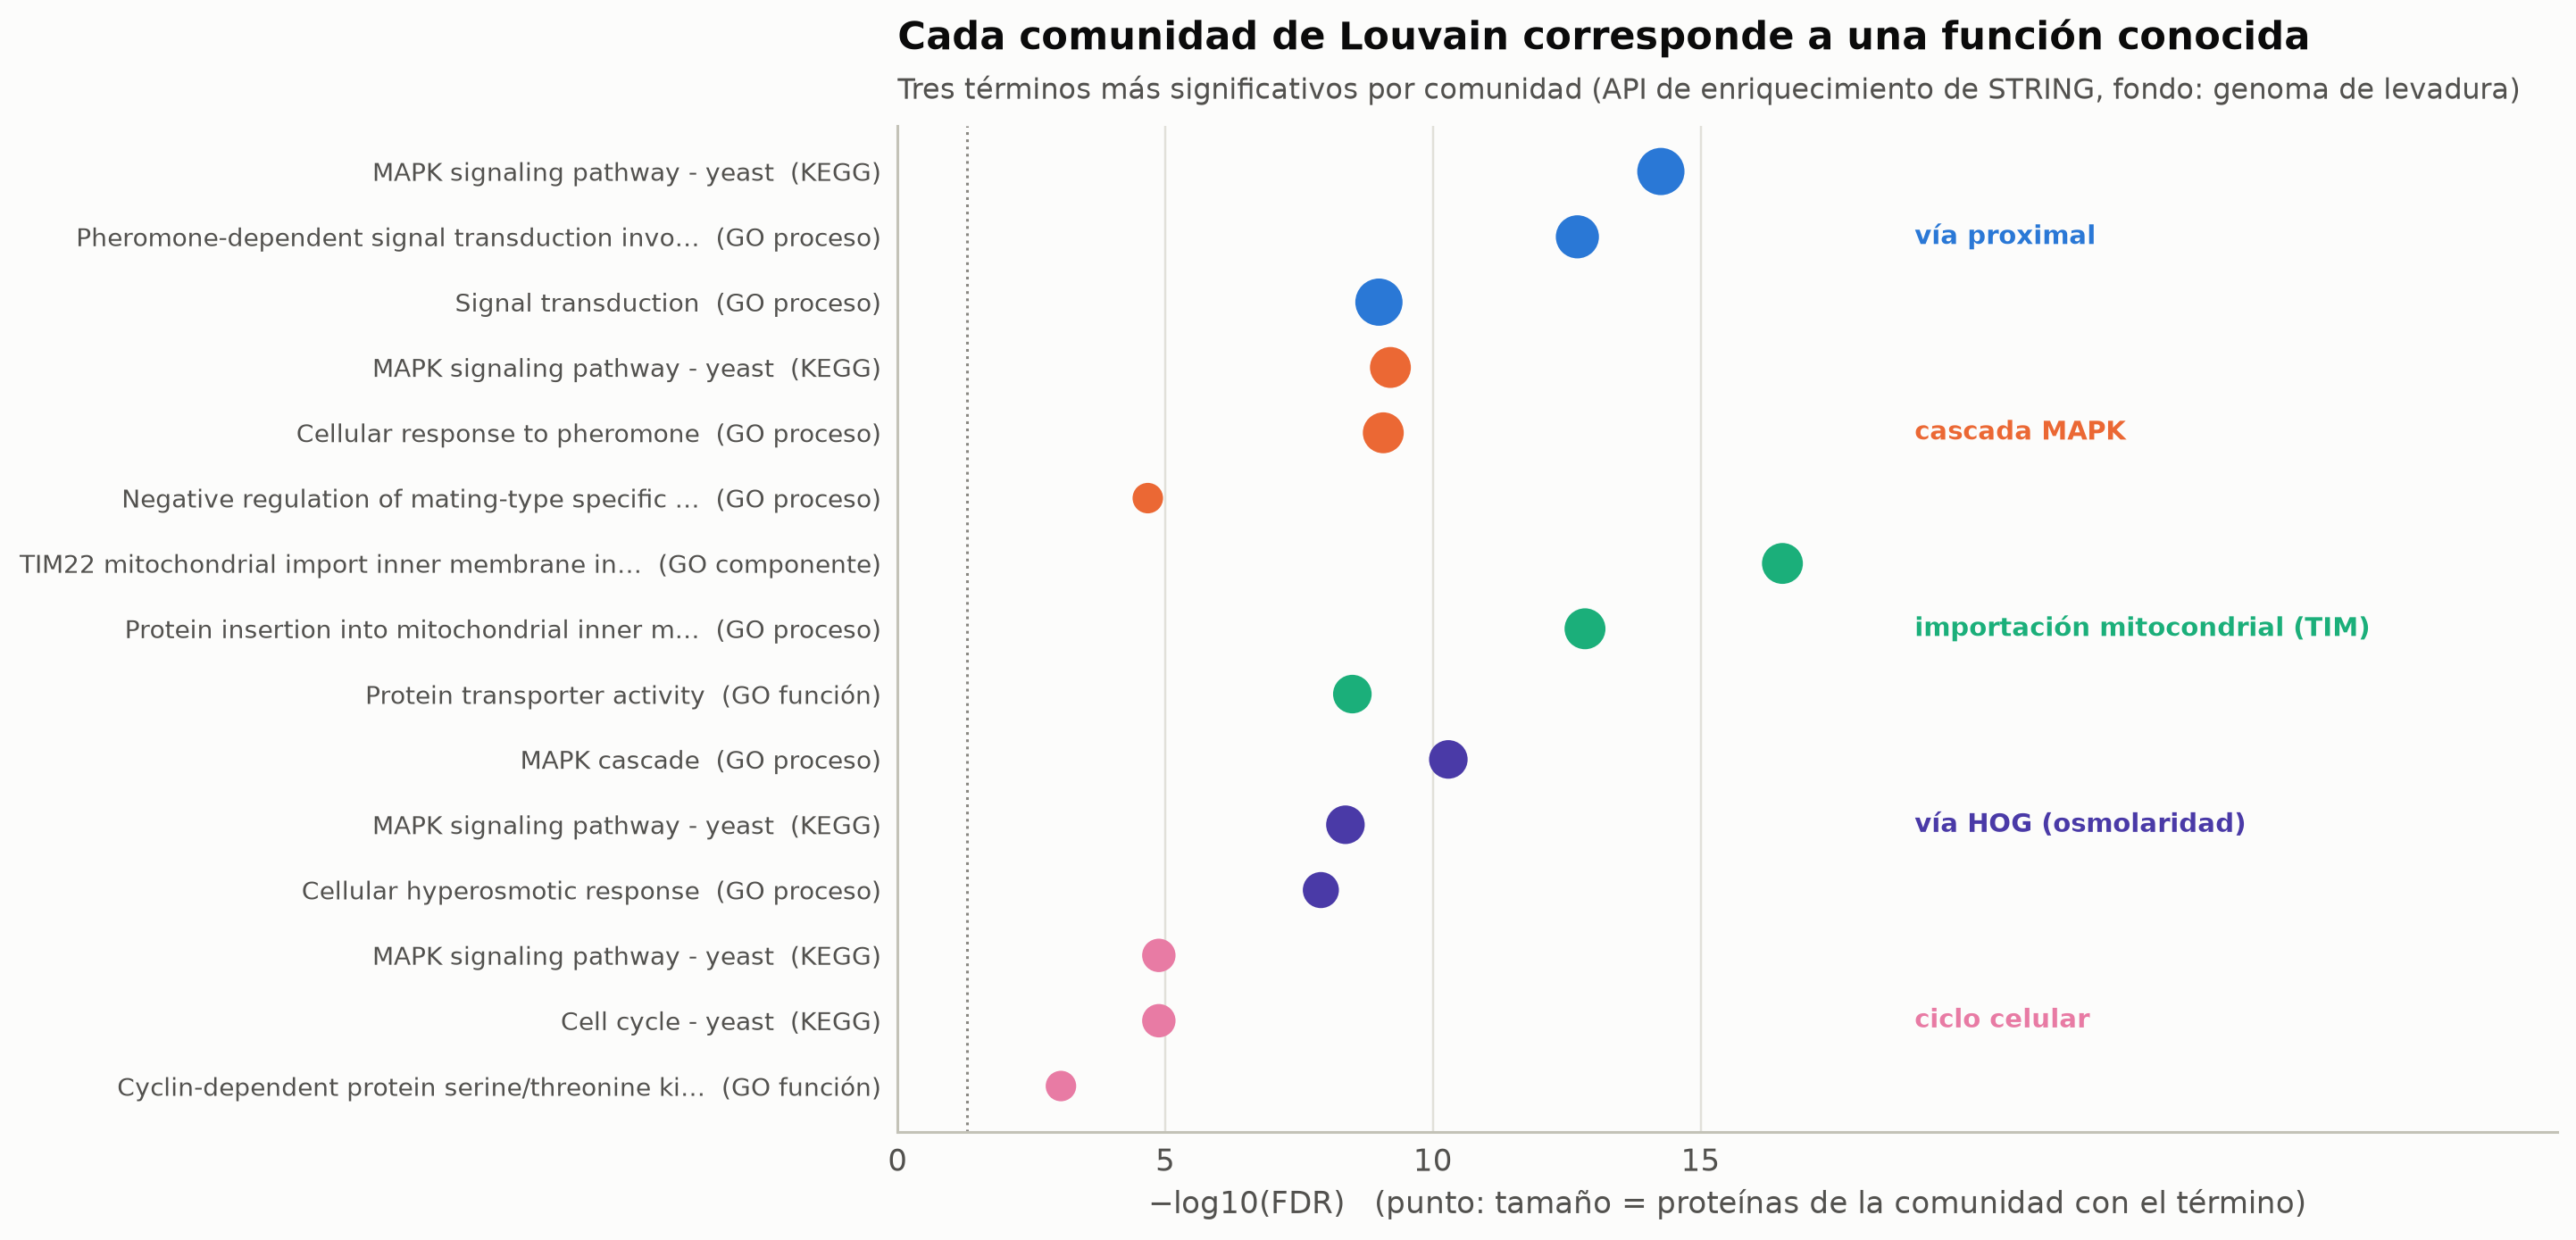

In [29]:
fig, ax = plt.subplots(figsize=(13, 6.2))
enr_df["y"] = np.arange(len(enr_df))[::-1]
for i in range(5):
    d_ = enr_df[enr_df.com == i]
    ax.scatter(-np.log10(d_.FDR), d_.y, s=50 + 25 * d_.x, color=COM_COLS[i], edgecolor="white", zorder=3)
ax.set_yticks(enr_df.y, [f"{t[:44]}{'…' if len(t) > 44 else ''}  ({c})" for t, c in zip(enr_df.término, enr_df.categoría)],
              fontsize=9)
for i in range(5):
    d_ = enr_df[enr_df.com == i]
    ax.text(19, d_.y.mean(), COM_NAMES[i].split(":")[0], color=COM_COLS[i],
            fontsize=9.5, va="center", ha="left", fontweight="bold")
ax.set_xlim(0, 31); ax.set_xticks([0, 5, 10, 15]); ax.axvline(-np.log10(0.05), color=ec.MUTED, ls=":", lw=1)
ax.set_xlabel("−log10(FDR)   (punto: tamaño = proteínas de la comunidad con el término)")
ax.grid(axis="x", color=ec.GRID); ax.grid(axis="y", visible=False)
ec.title(ax, "Cada comunidad de Louvain corresponde a una función conocida",
         "Tres términos más significativos por comunidad (API de enriquecimiento de STRING, fondo: genoma de levadura)")
plt.show()

> 🔎 **Qué observamos.** Las cinco comunidades se enriquecen en funciones coherentes y con significaciones enormes: la
> vía MAPK de levadura y la transducción de la feromona (comunidades de la vía proximal y de la cascada), el complejo
> Ste12p-Dig1p-Dig2p, el complejo TIM22 de inserción en la membrana mitocondrial interna (7 de 7), la respuesta
> hiperosmótica (HOG) y el ciclo celular. El cálculo a mano con $N\approx6000$ da el mismo orden de magnitud que STRING
> (que usa como fondo sólo los genes anotados en cada categoría). **Cuidado con la circularidad:** parte de las aristas
> de STRING proceden de bases curadas de vías, así que el enriquecimiento de una comunidad en «su» vía no es una
> validación del todo independiente.

La figura interactiva reúne todo: comunidades, centralidades, esencialidad y la función de cada módulo.

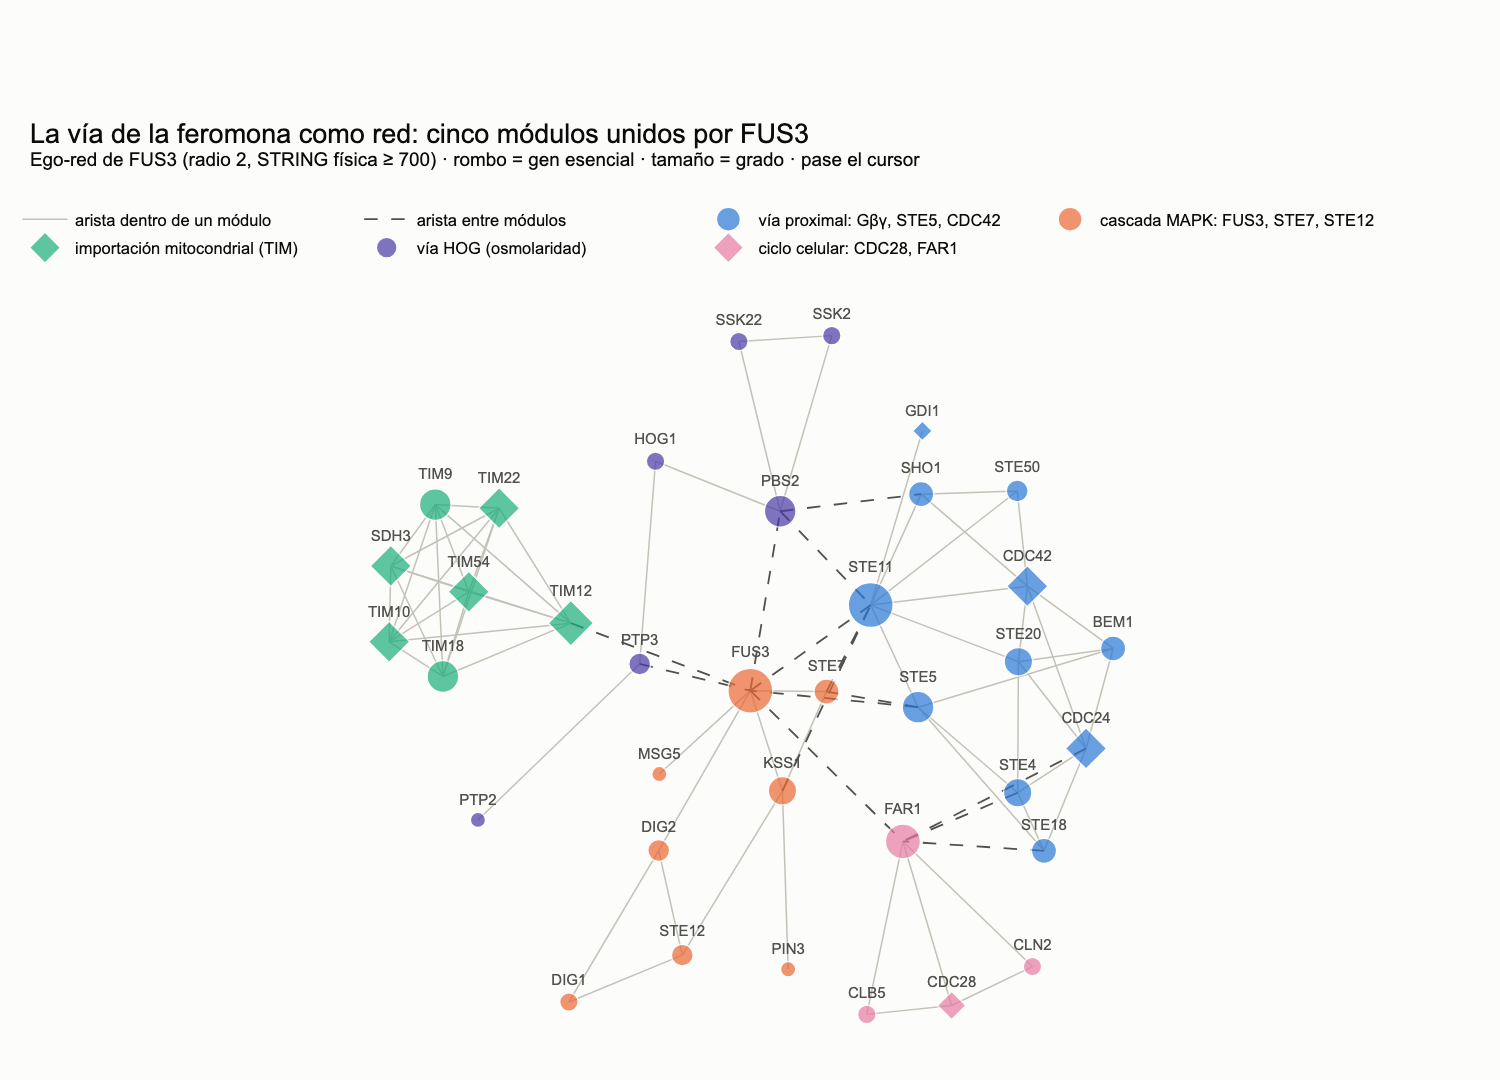

In [30]:
top_term = {i: enr["communities"][str(i)]["terms"][0]["description"] for i in range(5)}
fig = go.Figure()
ex_s, ey_s, ex_c, ey_c = [], [], [], []
for u, v in E.edges():
    tx, ty = (ex_s, ey_s) if cid[u] == cid[v] else (ex_c, ey_c)
    tx += [pos_f[u][0], pos_f[v][0], None]; ty += [pos_f[u][1], pos_f[v][1], None]
fig.add_trace(go.Scatter(x=ex_s, y=ey_s, mode="lines", line=dict(color=ec.BASELINE, width=1), hoverinfo="skip",
                         name="arista dentro de un módulo"))
fig.add_trace(go.Scatter(x=ex_c, y=ey_c, mode="lines", line=dict(color=ec.INK_2, width=1.2, dash="dash"),
                         hoverinfo="skip", name="arista entre módulos"))
ess_txt = {1: "esencial (letal)", 0: "no esencial (viable)"}
for i in range(5):
    us = sorted(comms[i])
    fig.add_trace(go.Scatter(
        x=[pos_f[u][0] for u in us], y=[pos_f[u][1] for u in us], mode="markers+text", text=us,
        textposition="top center", textfont=dict(size=10, color=ec.INK_2), name=COM_NAMES[i],
        marker=dict(size=[8 + 2.2 * dE[u] for u in us], color=COM_COLS[i], line=dict(color="white", width=1),
                    symbol=["diamond" if label.get(u) == 1 else "circle" for u in us]),
        customdata=np.column_stack([[dE[u] for u in us], [btw[u] for u in us], [nx.clustering(E, u) for u in us],
                                    [ess_txt.get(label.get(u), "sin dato") for u in us], [top_term[i]] * len(us)]),
        hovertemplate=("<b>%{text}</b> · " + COM_NAMES[i] + "<br>grado en la ego-red: %{customdata[0]}"
                       "<br>intermediación: %{customdata[1]:.3f}<br>agrupamiento C_i: %{customdata[2]:.2f}"
                       "<br>deleción: %{customdata[3]}<br>función del módulo: %{customdata[4]}<extra></extra>")))
fig.update_layout(
    title="La vía de la feromona como red: cinco módulos unidos por FUS3<br>"
          "<sup>Ego-red de FUS3 (radio 2, STRING física ≥ 700) · rombo = gen esencial · tamaño = grado · pase el cursor</sup>",
    xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor="x"), height=720,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, font=dict(size=11)),
    margin=dict(t=190, l=10, r=10, b=10))
fig.show()

> 🔎 **Qué observamos.** Pase el cursor por FUS3: la mayor intermediación de la red (0,63) y, sin embargo, su deleción
> es **viable**. La vía de la feromona sólo es necesaria para aparearse, no para crecer en el laboratorio: la
> esencialidad depende de la condición. Los rombos (esenciales) se concentran en CDC28, CDC42, CDC24 y GDI1
> (maquinaria general del ciclo y la polaridad) y en las TIM mitocondriales.

> ⚠️ **Comunidades a medida del observador.** La maximización de la modularidad tiene limitaciones conocidas: las
> particiones con $Q$ casi máximo pueden ser muy distintas entre sí; Louvain depende del orden aleatorio en que visita
> los nodos (fije siempre la semilla; con 50 semillas aquí aparecen varias particiones distintas, ejercicio 4); y existe
> un **límite de resolución** por debajo del cual las comunidades pequeñas se funden con sus vecinas. Además, una
> ego-red está sesgada por construcción hacia su semilla. Trate las comunidades como **hipótesis** que hay que
> contrastar con anotaciones funcionales, no como descubrimientos.

## 9. Herramientas: NetworkX y Cytoscape

Para el análisis programático, la biblioteca de referencia en Python es **NetworkX** (Hagberg, Schult y Swart, 2008):
estructuras de grafo flexibles y cientos de algoritmos (caminos, centralidades, comunidades, modelos aleatorios), todo
lo que hemos usado en esta clase. Para redes de millones de aristas conviene saltar a bibliotecas escritas en C/C++
como **igraph** o **graph-tool**, con las mismas ideas.

Para la **exploración visual e interactiva**, y para integrar la red con datos de expresión o anotaciones, el estándar
es **Cytoscape** (Shannon *et al.*, 2003), un entorno de escritorio de código abierto ampliable con extensiones, entre
ellas **stringApp**, que consulta STRING directamente. El puente entre ambos mundos es un archivo **GraphML**, que
guarda nodos, aristas y sus atributos. El fragmento siguiente es el programa del libro (`red_levadura.py`) y exporta la
ego-red de FUS3 con sus comunidades para abrirla en Cytoscape (*File → Import → Network from File*).

In [31]:
# red_levadura.py (libro, sección 16.1)
aristas = pd.read_csv(course_file("161_levadura_string700.tsv.gz"), sep="\t", comment="#")
G2 = nx.from_pandas_edgelist(aristas, "prot1", "prot2", "score")
print(G2.number_of_nodes(), G2.number_of_edges())        # 3384 43030
print(round(nx.average_clustering(G2), 3))               # 0.581
E2 = nx.ego_graph(G2, "FUS3", radius=2)                  # vecindad de FUS3
bc2 = nx.betweenness_centrality(E2)
print(max(bc2, key=bc2.get))                             # FUS3

# Exportar a GraphML con atributos para Cytoscape
for u in E2:
    E2.nodes[u].update(community=int(cid[u]), module=COM_NAMES[cid[u]], degree=int(E2.degree(u)),
                       betweenness=float(bc2[u]), essential=int(label.get(u, -1)))
nx.write_graphml(E2, "fus3_ego_red.graphml")
print("guardado fus3_ego_red.graphml:", os.path.getsize("fus3_ego_red.graphml"), "bytes")
if IN_COLAB:
    print("Descárguelo desde el panel de archivos de Colab (icono de carpeta) y ábralo en Cytoscape.")

3384 43030


0.581
FUS3
guardado fus3_ego_red.graphml: 15302 bytes


## 🧪 Ejercicios

**Ejercicio 1 (a mano, grafo de juguete modificado).** Añada al grafo de juguete la arista B–D. Calcule **a mano**:
el nuevo $m$ y $\langle k\rangle$, $C_{\mathrm{C}}$, $C_{\mathrm{D}}$, $b_{\mathrm{D}}$ y la modularidad de la partición
$\{$A, B, C$\}\,|\,\{$D, E, F, G$\}$. ¿Sigue siendo la mejor bipartición? Compruebe con NetworkX.

In [32]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
toy2 = toy.copy(); toy2.add_edge("B", "D")
m2 = toy2.number_of_edges()
print(f"m = {m2}, <k> = {2 * m2 / 7:.3f}")                          # 9 aristas, <k> = 18/7 ≈ 2,571
print("C_i:", {u: round(c, 3) for u, c in nx.clustering(toy2).items()})
# C: vecinos A, B, D → pares A-B y B-D unidos: 2/3.  D: vecinos B, C, E, F → B-C y E-F: 2/6 = 1/3
print("b_v:", nx.betweenness_centrality(toy2, normalized=False))
# D sigue siendo el único paso entre {A,B,C} y {E,F,G}: b_D = 9 no cambia; b_C cae de 8 a 2 (B ya llega directo a D)
part = [{"A", "B", "C"}, {"D", "E", "F", "G"}]
# a mano: l1 = 3, d1 = 2+3+3 = 8; l2 = 4, d2 = 4+2+3+1 = 10;  Q = 3/9 - (8/18)^2 + 4/9 - (10/18)^2
print(f"Q a mano = {3 / 9 - (8 / 18) ** 2 + 4 / 9 - (10 / 18) ** 2:.4f}  NetworkX = {nx.community.modularity(toy2, part):.4f}")
best2 = max(((nx.community.modularity(toy2, [set(S), set(toy2) - set(S)]), S)
             for r in range(1, 4) for S in itertools.combinations(sorted(toy2), r)))
print("mejor bipartición:", best2)
# Q baja de 0,367 a 0,272 porque ahora hay dos aristas entre los grupos; ABC|DEFG sigue siendo la mejor bipartición.

m = 9, <k> = 2.571
C_i: {'A': 1.0, 'B': 0.667, 'C': 0.667, 'D': 0.333, 'E': 1.0, 'F': 0.333, 'G': 0}
b_v: {'A': 0.0, 'B': 2.0, 'C': 2.0, 'D': 9.0, 'E': 0.0, 'F': 5.0, 'G': 0.0}
Q a mano = 0.2716  NetworkX = 0.2716
mejor bipartición: (0.2716049382716049, ('A', 'B', 'C'))


**Ejercicio 2 (integración de evidencias).** Una pareja de proteínas tiene en STRING $s=(0{,}30;\ 0{,}80;\ 0{,}20)$ en
tres canales. (a) Calcule $S$ con la fórmula ingenua y con la corrección del a priori $p_0=0{,}041$. (b) ¿Cuántos
canales independientes de confianza $0{,}5$ harían falta para superar el umbral de «confianza alta» (0,7)? ¿Y el de
«confianza máxima» (0,9)?

In [33]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
def combine(sv, p0=0.041, prior=True):
    sv = np.asarray(sv, float)
    if not prior:
        return 1 - np.prod(1 - sv)
    sp_ = np.clip((sv - p0) / (1 - p0), 0, None)
    S_ = 1 - np.prod(1 - sp_)
    return S_ + p0 * (1 - S_)
sv = [0.30, 0.80, 0.20]
print(f"ingenua: {combine(sv, prior=False):.3f}   con a priori: {combine(sv):.3f}")   # 0,888 frente a 0,878
for thr in (0.7, 0.9):
    c = 1
    while combine([0.5] * c) < thr:
        c += 1
    print(f"umbral {thr}: {c} canales de 0,5 (S = {combine([0.5] * c):.3f})")
# Con el a priori cada canal de 0,5 aporta algo menos que 0,5: hacen falta 2 canales para 0,7 y 4 para 0,9.

ingenua: 0.888   con a priori: 0.878
umbral 0.7: 2 canales de 0,5 (S = 0.739)
umbral 0.9: 4 canales de 0,5 (S = 0.929)


**Ejercicio 3 (¿es el ribosoma el que dobla la cola?).** Elimine de la red de levadura todas las proteínas ribosómicas
(nombres que empiezan por RPS o RPL, más las del tallo RPP0, RPP1A/1B y RPP2A/2B: use `is_ribosomal`). Recalcule $n$, $m$, $\langle k\rangle$, $C$, el grado máximo y $\hat\gamma$ con
$k_{\min}=26$. Dibuje la nueva distribución de grado agrupada junto a la original. ¿Qué cambia?

sin ribosómicas: n = 3247, m = 25113, <k> = 15.47, kmax = 144, C = 0.571
γ̂ (kmin = 26) = 2.47 ± 0.06 (N = 593)   frente a 1.99 con ribosómicas


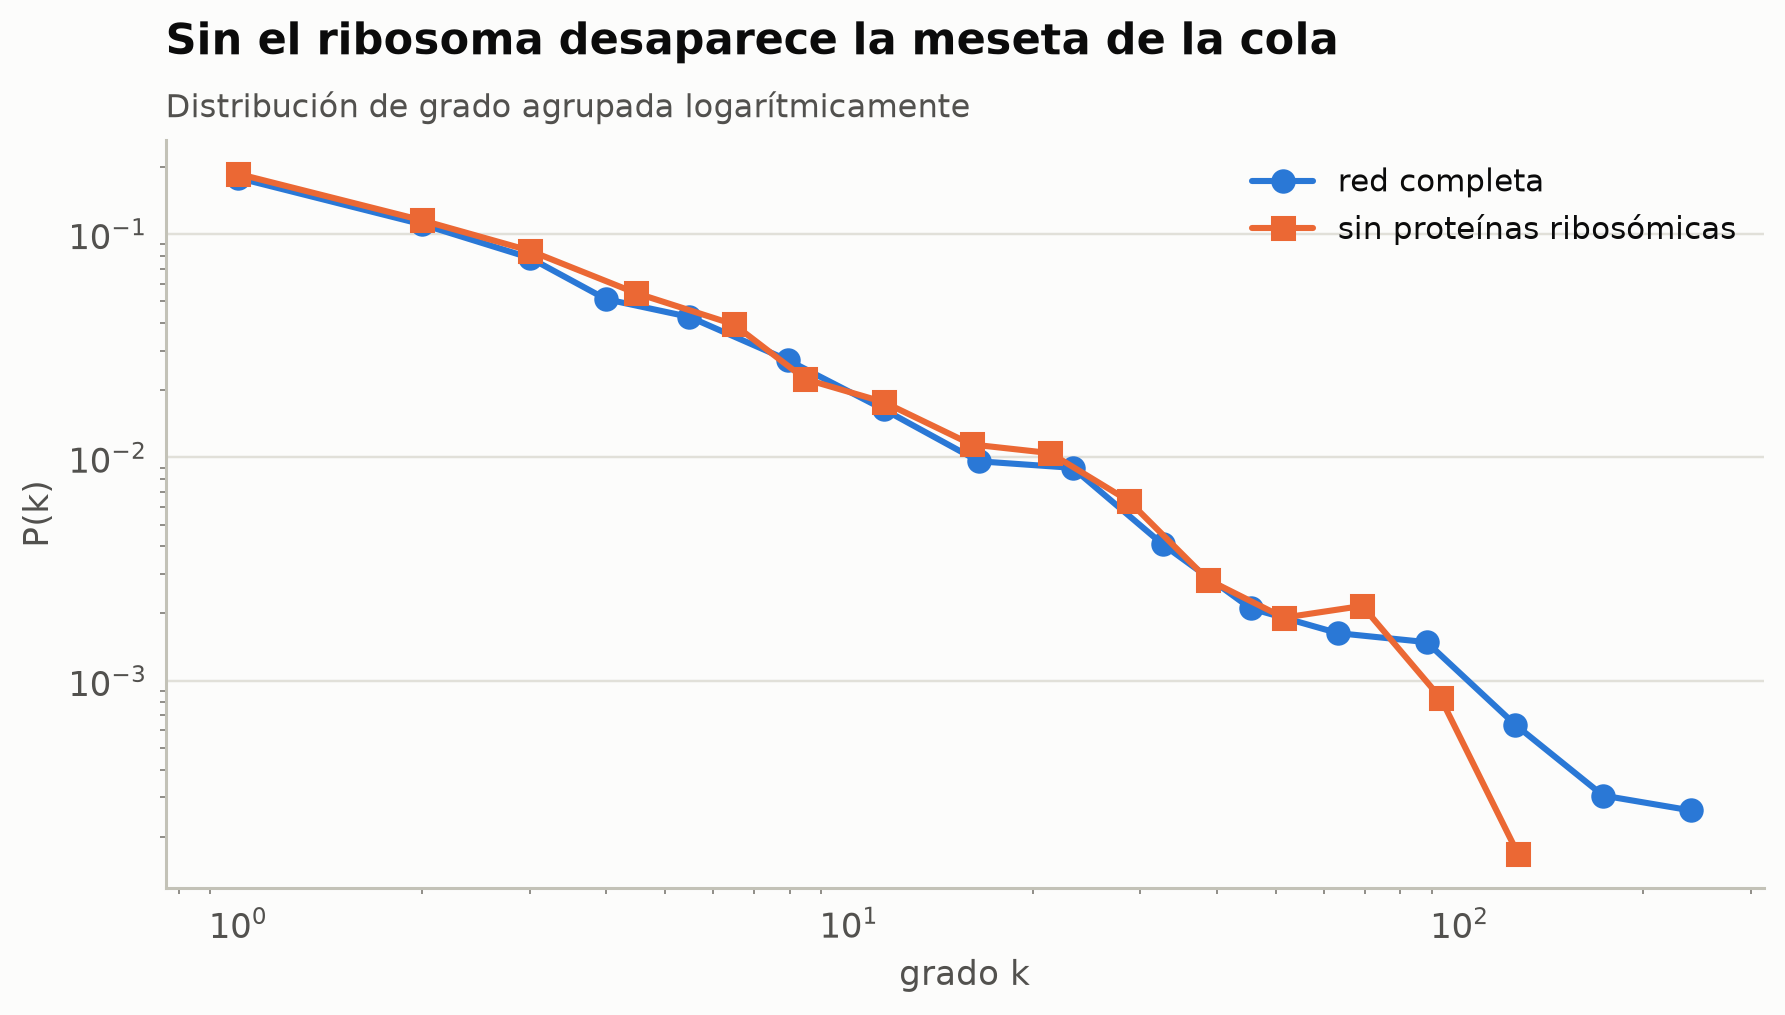

In [34]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
G_nr = G.subgraph([u for u in G if not is_ribosomal(u)]).copy()
d_nr = np.array([d for _, d in G_nr.degree()])
print(f"sin ribosómicas: n = {G_nr.number_of_nodes()}, m = {G_nr.number_of_edges()}, <k> = {d_nr.mean():.2f}, "
      f"kmax = {d_nr.max()}, C = {nx.average_clustering(G_nr):.3f}")
g_nr, se_nr, nt_nr = gamma_mle(d_nr, 26)
print(f"γ̂ (kmin = 26) = {g_nr:.2f} ± {se_nr:.2f} (N = {nt_nr})   frente a {gamma_mle(deg, 26)[0]:.2f} con ribosómicas")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(*lb["levadura"].T, "o-", color=ec.BLUE, label="red completa")
ax.plot(*logbin(d_nr).T, "s-", color=ec.ORANGE, label="sin proteínas ribosómicas")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("grado k"); ax.set_ylabel("P(k)"); ax.legend()
ec.title(ax, "Sin el ribosoma desaparece la meseta de la cola", "Distribución de grado agrupada logarítmicamente")
plt.show()
# Unas 140 proteínas se llevan miles de aristas: <k> baja, la meseta de k ≈ 200–280 desaparece y γ̂ sube.

**Ejercicio 4 (estabilidad de Louvain).** Ejecute Louvain sobre la ego-red de FUS3 (versión con enteros, `H`) con las
semillas 0…49. ¿Cuántas particiones distintas aparecen? ¿Cuál es el rango de $Q$? ¿Qué proteínas cambian de comunidad
entre la partición más frecuente y la del libro?

In [35]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
from collections import Counter
found = Counter(); qmap = {}
for s_ in range(50):
    c = nx.community.louvain_communities(H, seed=s_)
    key = frozenset(frozenset(names[i] for i in x) for x in c)
    found[key] += 1; qmap[key] = nx.community.modularity(H, c)
print(f"{len(found)} particiones distintas en 50 semillas")
for key, cnt in found.most_common():
    print(f"  {cnt:2d} veces · Q = {qmap[key]:.3f} · tamaños {sorted(map(len, key), reverse=True)}")
alt = found.most_common(2)[1][0]                      # la segunda partición más frecuente
print("segunda partición más frecuente:")
for c in sorted(alt, key=len, reverse=True):
    print("  ", sorted(c))
# Varias particiones con Q casi igual: la «mejor» partición no es única. Por eso se fija la semilla y se informa.

4 particiones distintas en 50 semillas
  33 veces · Q = 0.572 · tamaños [11, 8, 7, 6, 4]
  12 veces · Q = 0.564 · tamaños [8, 7, 7, 7, 4, 3]
   3 veces · Q = 0.556 · tamaños [9, 7, 7, 6, 4, 3]
   2 veces · Q = 0.559 · tamaños [10, 9, 7, 6, 4]
segunda partición más frecuente:
   ['DIG1', 'DIG2', 'FUS3', 'KSS1', 'MSG5', 'PIN3', 'STE12', 'STE7']
   ['GDI1', 'PBS2', 'SHO1', 'SSK2', 'SSK22', 'STE11', 'STE50']
   ['SDH3', 'TIM10', 'TIM12', 'TIM18', 'TIM22', 'TIM54', 'TIM9']
   ['BEM1', 'CDC24', 'CDC42', 'STE18', 'STE20', 'STE4', 'STE5']
   ['CDC28', 'CLB5', 'CLN2', 'FAR1']
   ['HOG1', 'PTP2', 'PTP3']


**Ejercicio 5 (robustez y talón de Aquiles).** Albert, Jeong y Barabási (2000) mostraron que las redes con *hubs*
toleran bien la pérdida de nodos al azar pero se desintegran si se atacan sus *hubs*. Elimine de la red de levadura una
fracción $f$ de nodos (de 0 a 20 %) de dos formas: al azar y por grado decreciente (ataque). Mida el tamaño relativo
de la componente gigante y compare con la red ER equivalente. ¿Es la levadura frágil ante el ataque?

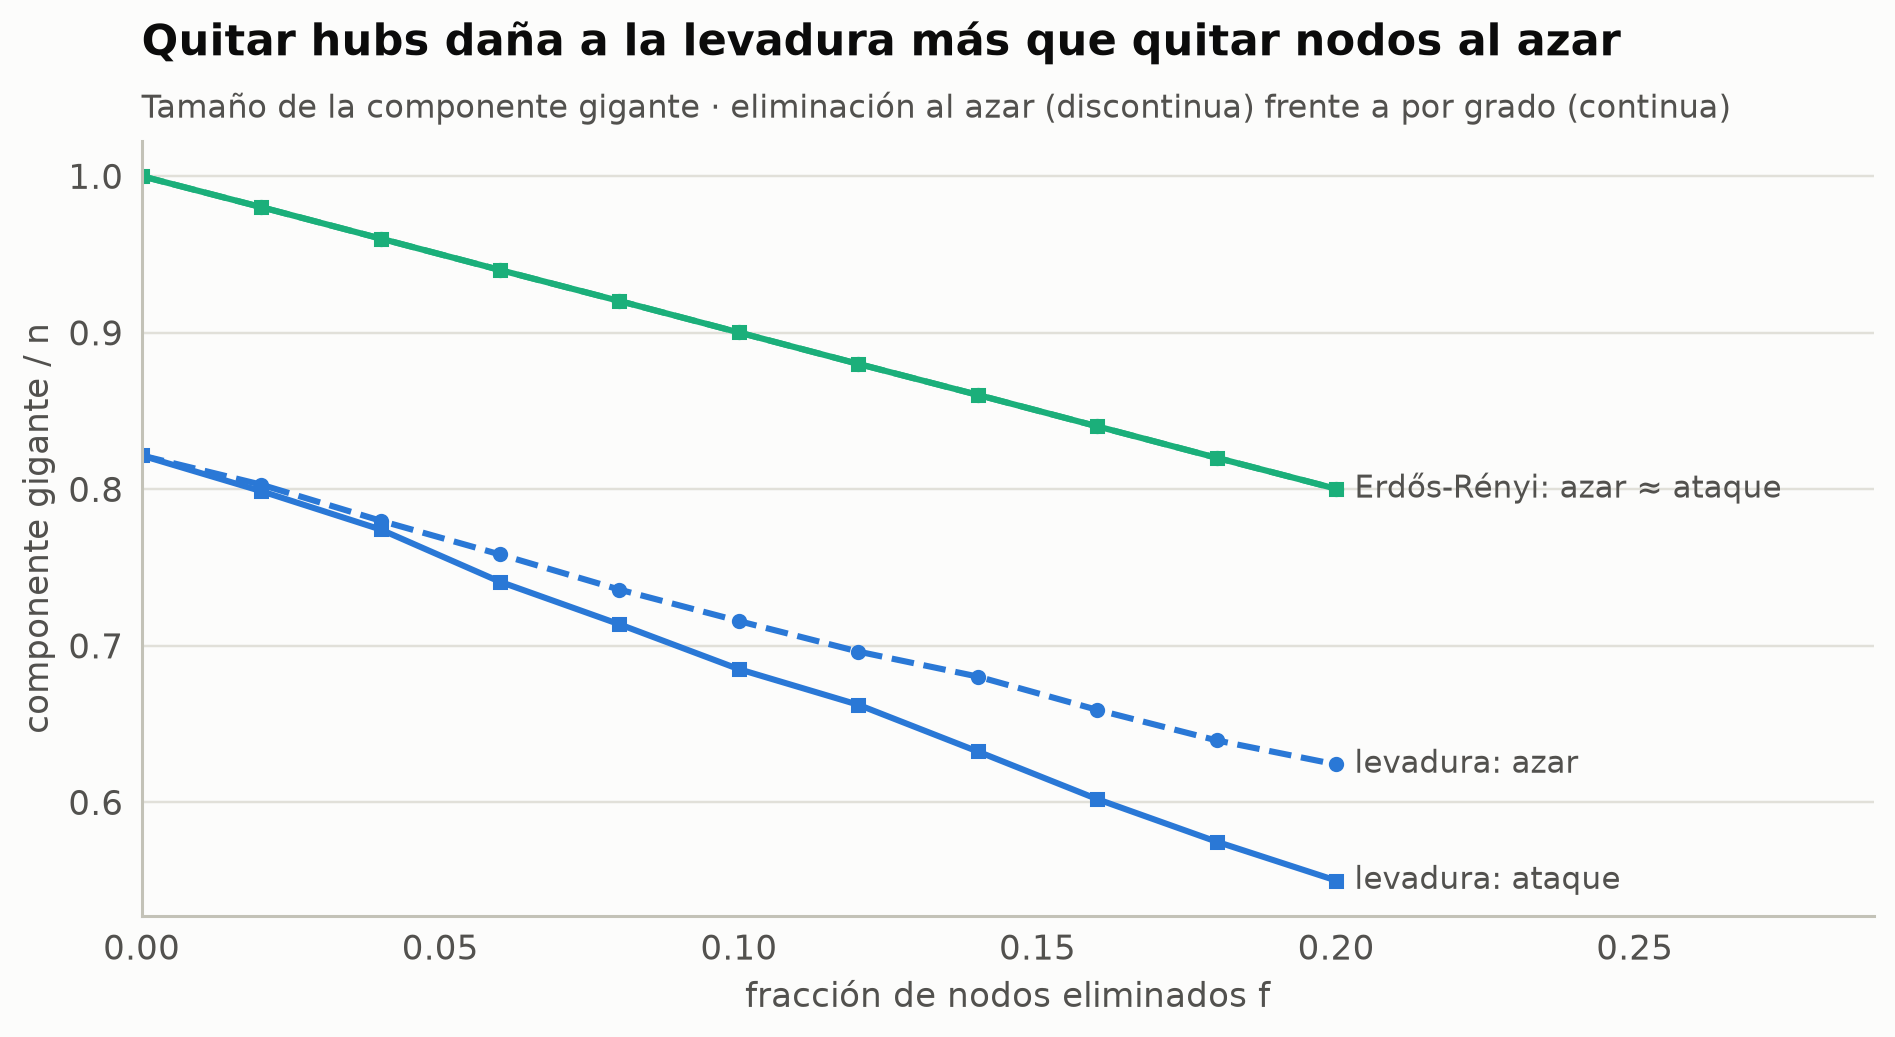

In [36]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
def giant_fraction(g, remove):
    h = g.copy(); h.remove_nodes_from(remove)
    return max((len(c) for c in nx.connected_components(h)), default=0) / g.number_of_nodes()
fs = np.linspace(0, 0.2, 11); rng_rob = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for g, name, col in ((G, "levadura", ec.BLUE), (ER, "Erdős-Rényi", ec.AQUA)):
    nodes = list(g); by_deg = [u for u, _ in sorted(g.degree(), key=lambda x: -x[1])]
    rand_ = rng_rob.permutation(len(nodes))
    att = [giant_fraction(g, by_deg[:int(f * len(nodes))]) for f in fs]
    rnd = [giant_fraction(g, [nodes[i] for i in rand_[:int(f * len(nodes))]]) for f in fs]
    ax.plot(fs, rnd, color=col, ls="--", marker="o", ms=4); ax.plot(fs, att, color=col, marker="s", ms=4)
    if name == "levadura":
        ec.label_end(ax, fs[-1], att[-1], f"{name}: ataque"); ec.label_end(ax, fs[-1], rnd[-1], f"{name}: azar")
    else:
        ec.label_end(ax, fs[-1], att[-1], f"{name}: azar ≈ ataque")
ax.set_xlim(0, 0.29); ax.set_xlabel("fracción de nodos eliminados f"); ax.set_ylabel("componente gigante / n")
ec.title(ax, "Quitar hubs daña a la levadura más que quitar nodos al azar", "Tamaño de la componente gigante · eliminación al azar (discontinua) frente a por grado (continua)")
plt.show()
# La levadura parte de una gigante del 82 % y, con f = 0,2, el ataque la deja en ~55 % frente a ~62 % al azar;
# en ER ambas curvas coinciden (sólo se pierden los nodos quitados: 1 − f). El efecto es moderado porque los
# mayores hubs están dentro de la «bola» ribosómica, redundante entre sí: quitarlos no desconecta a casi nadie.
# En la célula, además, "fragmentar" la red no equivale a matarla.

## 📌 Resumen

* Un interactoma es un **grafo** $G=(V,E)$ con matriz de adyacencia $A$. **Grado** $k_i=\sum_jA_{ij}$ (con
  $\sum_ik_i=2m$), **agrupamiento** $C_i=2t_i/[k_i(k_i-1)]$ con $t_i=(A^3)_{ii}/2$, **distancia media** $L$ e
  **intermediación** $b_v$ responden a preguntas distintas. En el grafo de juguete: $\langle k\rangle=2{,}29$,
  $C=4/7=0{,}571$, $L=2{,}05$, diámetro 4, $b_{\mathrm{C}}=8$, $b_{\mathrm{D}}=9$, $b_{\mathrm{F}}=5$.
* Las redes se **construyen** con experimentos sesgados: Y2H (pares, falsos positivos «pegajosos») y AP-MS (complejos;
  modelos estrella y matriz, 5 frente a 15 aristas). **STRING** combina canales con $S=1-\prod(1-s_c)$, corrigiendo el
  a priori $p_0=0{,}041$ (lo verificamos con 40 socios reales de FUS3). Una asociación no es un contacto.
* **Modelos nulos**: ER (Poisson, $C=p$, $L\approx\ln n/\ln\langle k\rangle$), WS (mundo pequeño: con $p=0{,}01$,
  $L/L_0=0{,}18$ y $C/C_0=0{,}97$) y BA ($k_i\propto\sqrt{t/t_i}$, $P(k)=2m^2/k^3$).
* La red física de levadura (STRING ≥700: $n=3384$, $m=43030$) es un **mundo pequeño muy agrupado**
  ($C=0{,}58$ frente a $0{,}0075$; $L\approx5{,}2$). Su cola de grado la dominan las proteínas ribosómicas; por
  máxima verosimilitud $\hat\gamma=1{,}99$ (BA: $2{,}83$). Una recta en log-log **no** demuestra una ley de potencias.
* **Centralidad-letalidad**: con los genes esenciales de Giaever *et al.* (2002), la fracción de esenciales sube de
  12 % a ~67 % con el grado (AUC ≈ 0,69), pero las proteínas ribosómicas, con parálogos, rompen la tendencia.
* **Modularidad** $Q=\sum_c[l_c/m-(d_c/2m)^2]$: 0,367 para $\{$A,B,C$\}|\{$D,E,F,G$\}$ y 0,219 si D cambia de lado. En la
  vecindad de FUS3, Louvain halla cinco módulos con $Q=0{,}57$ (redes aleatorizadas: ≈0,35), Girvan-Newman 0,562, y
  el enriquecimiento funcional los identifica como vía proximal, cascada MAPK, TIM22, HOG y ciclo celular.

## 📚 Lecturas y referencias

* Albert, R., Jeong, H. y Barabási, A.-L. (2000). Error and attack tolerance of complex networks. *Nature*, 406,
  378–382. https://doi.org/10.1038/35019019
* Barabási, A.-L. y Albert, R. (1999). Emergence of scaling in random networks. *Science*, 286(5439), 509–512.
  https://doi.org/10.1126/science.286.5439.509
* Barabási, A.-L., Gulbahce, N. y Loscalzo, J. (2011). Network medicine: a network-based approach to human disease.
  *Nature Reviews Genetics*, 12(1), 56–68. https://doi.org/10.1038/nrg2918
* Barabási, A.-L. y Oltvai, Z. N. (2004). Network biology: understanding the cell's functional organization. *Nature
  Reviews Genetics*, 5(2), 101–113. https://doi.org/10.1038/nrg1272
* Blondel, V. D., Guillaume, J.-L., Lambiotte, R. y Lefebvre, E. (2008). Fast unfolding of communities in large
  networks. *Journal of Statistical Mechanics*, 2008(10), P10008. https://doi.org/10.1088/1742-5468/2008/10/P10008
* Broido, A. D. y Clauset, A. (2019). Scale-free networks are rare. *Nature Communications*, 10, 1017.
  https://doi.org/10.1038/s41467-019-08746-5
* Clauset, A., Shalizi, C. R. y Newman, M. E. J. (2009). Power-law distributions in empirical data. *SIAM Review*,
  51(4), 661–703. https://doi.org/10.1137/070710111
* Gavin, A.-C. *et al.* (2002). Functional organization of the yeast proteome by systematic analysis of protein
  complexes. *Nature*, 415, 141–147. https://doi.org/10.1038/415141a
* Giaever, G. *et al.* (2002). Functional profiling of the *Saccharomyces cerevisiae* genome. *Nature*, 418, 387–391.
  https://doi.org/10.1038/nature00935
* Girvan, M. y Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12),
  7821–7826. https://doi.org/10.1073/pnas.122653799
* Hagberg, A. A., Schult, D. A. y Swart, P. J. (2008). Exploring network structure, dynamics, and function using
  NetworkX. *Proceedings of the 7th Python in Science Conference*, 11–15. https://doi.org/10.25080/TCWV9851
* Ito, T. *et al.* (2001). A comprehensive two-hybrid analysis to explore the yeast protein interactome. *PNAS*,
  98(8), 4569–4574. https://doi.org/10.1073/pnas.061034498
* Jeong, H., Mason, S. P., Barabási, A.-L. y Oltvai, Z. N. (2001). Lethality and centrality in protein networks.
  *Nature*, 411, 41–42. https://doi.org/10.1038/35075138
* Newman, M. E. J. (2006). Modularity and community structure in networks. *PNAS*, 103(23), 8577–8582.
  https://doi.org/10.1073/pnas.0601602103
* Oughtred, R. *et al.* (2021). The BioGRID database: a comprehensive biomedical resource of curated protein, genetic,
  and chemical interactions. *Protein Science*, 30(1), 187–200. https://doi.org/10.1002/pro.3978
* Shannon, P. *et al.* (2003). Cytoscape: a software environment for integrated models of biomolecular interaction
  networks. *Genome Research*, 13(11), 2498–2504. https://doi.org/10.1101/gr.1239303
* Szklarczyk, D. *et al.* (2023). The STRING database in 2023: protein–protein association networks and functional
  enrichment analyses for any sequenced genome of interest. *Nucleic Acids Research*, 51(D1), D638–D646.
  https://doi.org/10.1093/nar/gkac1000
* Uetz, P. *et al.* (2000). A comprehensive analysis of protein–protein interactions in *Saccharomyces cerevisiae*.
  *Nature*, 403, 623–627. https://doi.org/10.1038/35001009
* von Mering, C. *et al.* (2002). Comparative assessment of large-scale data sets of protein–protein interactions.
  *Nature*, 417, 399–403. https://doi.org/10.1038/nature750
* von Mering, C. *et al.* (2005). STRING: known and predicted protein–protein associations, integrated and transferred
  across organisms. *Nucleic Acids Research*, 33, D433–D437. https://doi.org/10.1093/nar/gki005
* Watts, D. J. y Strogatz, S. H. (1998). Collective dynamics of 'small-world' networks. *Nature*, 393, 440–442.
  https://doi.org/10.1038/30918
* Wolfe, K. H. y Shields, D. C. (1997). Molecular evidence for an ancient duplication of the entire yeast genome.
  *Nature*, 387, 708–713. https://doi.org/10.1038/42711

**Datos:** red física de levadura de STRING v12.0 (https://stringdb-downloads.org, taxón 4932, puntuación ≥700; copia
en `data/161_levadura_string700.tsv.gz`); viabilidad de los mutantes nulos de Giaever *et al.* (2002) extraída de SGD
(`phenotype_data.tab`, https://downloads.yeastgenome.org/curation/literature/; copia en
`data/161_sgd_viabilidad_giaever2002.tsv.gz`); consultas a la API de STRING v12.5 (socios de FUS3 y enriquecimiento),
en `data/api_cache/161_string_*.json`.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)